# Incumplimiento de préstamos en Lending Club: scikit-learn frente a PySpark

**Ana Galván Arias, Valeria Oñate López, María José Ruiz Arias**
Septiembre de 2026

## Resumen

Se compara el desempeño predictivo y el costo computacional de seis modelos de clasificación (regresión
logística, árbol de decisión, bosque aleatorio, *gradient boosting*, SVM lineal y Naive Bayes),
implementados de forma equivalente en scikit-learn y en PySpark, sobre 1 345 310 préstamos de Lending Club
con desenlace conocido. Los dos motores comparten partición y pliegues de validación cruzada. La
comparación usa DeLong pareado, la prueba de McNemar y un *bootstrap* pareado, con corrección de Holm y un
margen de relevancia práctica fijado de antemano (ΔAUC ≥ 0.005). Los seis modelos alcanzan un AUC entre
0.69 y 0.72 en ambos entornos (*gradient boosting*, el mejor, 0.7196 y 0.7189); solo la SVM lineal difiere de
forma relevante, porque la de scikit-learn converge a una solución degenerada.
En tiempo, scikit-learn resulta unas 17 veces más rápido que PySpark en una sola máquina de 12 hilos.
Se documentan además la escalabilidad, el efecto de cada elemento de la configuración de Spark y las
explicaciones locales con LIME de dos préstamos mal clasificados por ambos entornos. **Palabras clave:**
incumplimiento crediticio, comparación de motores de cómputo, DeLong pareado, aprendizaje distribuido,
interpretabilidad local.

## Datos y diseño

Se predice si un préstamo de Lending Club terminará en incumplimiento (`Charged Off`) o se pagará por
completo (`Fully Paid`) con información disponible en el momento de otorgarlo. El diseño busca que el
desempeño reportado estime, sin sesgo, el que se obtendría con préstamos nuevos: el conjunto de prueba se
separa antes de cualquier análisis exploratorio, los hiperparámetros y el umbral se eligen sin tocarlo, y ese
conjunto no interviene en ninguna decisión de modelado.

- **Datos:** préstamos aceptados por Lending Club entre 2007 y el cuarto trimestre de 2018, en la versión
  pública de Kaggle [*All Lending Club loan data*](https://www.kaggle.com/datasets/wordsforthewise/lending-club):
  2 260 701 registros y 151 variables.
- **Población de estudio:** la variable objetivo se define solo para préstamos con desenlace conocido,
  `Fully Paid` (0) y `Charged Off` (1): **1 345 310** préstamos. El archivo contiene además 878 317
  préstamos vigentes y 34 252 atrasados o en periodo de gracia, cuyo desenlace aún no se observa, y 2 822
  filas en otros estados; todos se excluyen. Etiquetarlos como pagados sesgaría la variable objetivo y
  reduciría la tasa de incumplimiento aparente del 20.0 % al 11.9 %. La restricción se aplica por igual a
  todas las filas y no es un muestreo: se lee y procesa el archivo completo.
- **Partición:** 80 % / 20 % estratificada, semilla 42: 1 076 248 para entrenamiento y 269 062 para
  prueba, con 3 pliegues de validación cruzada compartidos por ambos motores.
- **Variables:** 21 (17 numéricas, 4 categóricas), elegidas por estar disponibles al otorgar el préstamo,
  no tener más de 30 % de valores faltantes en el entrenamiento (o que su ausencia no dependa del año de
  registro) y no ser redundantes entre sí. Se excluyen 15 columnas generadas después del desembolso, aunque
  algunas tengan un AUC univariado de hasta 0.94: esa capacidad predictiva proviene del propio desenlace y
  no estaría disponible al decidir un préstamo nuevo.

## Resultados principales

| Modelo | AUC prueba (scikit-learn) | AUC prueba (PySpark) | ΔAUC | Tiempo entren.+CV (scikit-learn) | Tiempo entren.+CV (PySpark) |
|---|---|---|---|---|---|
| Regresión logística | 0.7095 | 0.7095 | 0.00000004 (no significativo) | 15 s | 1 h 03 min |
| Árbol de decisión | 0.7022 | 0.7004 | 0.0018 (significativo, no relevante) | 59 s | 1 h 04 min |
| Bosque aleatorio | 0.7164 | 0.7152 | 0.0012 (significativo, no relevante) | 14 min | 5 h 52 min |
| *Gradient boosting* (mejor de los seis) | 0.7196 | 0.7189 | 0.0007 (significativo, no relevante) | 54 min | 10 h 07 min |
| SVM lineal | 0.4956 (solución degenerada) | 0.5985 | −0.1029 (significativo y relevante) | 10 min | 3 h 36 min |
| Naive Bayes | 0.6884 | 0.6883 | 0.0001 (significativo, no relevante) | 5 s | 43 min |

Con los seis modelos y el preprocesamiento, el entrenamiento con validación cruzada requirió ≈ 1 h 21 min
en scikit-learn y ≈ 22 h 32 min en PySpark (≈ 17 veces más), en la misma máquina de 12 hilos.

> **La SVM lineal de scikit-learn no separa las clases en estos datos.** Con `LinearSVC(loss="hinge")` el AUC queda en ≈ 0.50, igual que el azar. El *solver* (`liblinear`)
> converge, en 93 iteraciones y sin advertencias, a coeficientes del orden de 10⁻⁸ y a un intercepto de −1,
> con los tres valores de `C` de la malla. Es la solución degenerada de la SVM con pérdida *hinge* descrita
> por Rifkin, Pontil y Verri (1999): cuando las clases se solapan mucho y la clase mayoritaria cuadruplica a
> la minoritaria, el punto *w* = 0, *b* = −1, que deja a todos los negativos justo sobre el margen, puede ser
> el óptimo del problema regularizado; `liblinear` refuerza el efecto porque también regulariza el
> intercepto. Las puntuaciones resultantes son prácticamente constantes (desviación estándar de 1.8×10⁻¹³),
> así que el AUC de 0.496 equivale al azar, no a un modelo peor que el azar. La SVM de PySpark, que no
> regulariza el intercepto y minimiza la misma pérdida con OWL-QN (un método cuasi-Newton que puede
> detenerse antes del óptimo de una función no diferenciable), sí separa algo las clases (AUC 0.60). Ambas
> diferencias son candidatas a explicar esa brecha, aunque no se aislaron por separado.

> **La exactitud (accuracy) no es un criterio adecuado en estos datos.** Con el umbral 0.5, que solo minimiza el error cuando las probabilidades están calibradas y los costos de
> cada error son iguales (condiciones que aquí no se cumplen), los modelos con buen AUC tienen ≈ 80 % de
> exactitud pero detectan muy pocos incumplimientos: un modelo que dijera "todos pagan" tendría también
> ≈ 80 %. Por eso se reportan ROC AUC, AUC-PR, sensibilidad (*recall*), precisión, F1 y MCC, con el umbral elegido a partir de
> predicciones fuera de pliegue del entrenamiento.

## Estructura del documento

| Capítulo | Contenido |
|---|---|
| **1. Análisis exploratorio** | Partición primero; calidad de datos, fuga y desbalance con el entrenamiento |
| **2. Los seis modelos con scikit-learn** | `GridSearchCV` sin `Pipeline`, 3 pliegues, umbral, métricas, hallazgo de la SVM, importancia, validación temporal, escala |
| **3. Los seis modelos con PySpark** | Configuración de la sesión, `CrossValidator` con los mismos pliegues (`foldCol`), LIME con el mejor modelo de Spark |
| **3b. Costos de PySpark** | Latencia, efecto de cada elemento de la configuración (caché, particiones, pliegues) y escala, con un bosque de referencia |
| **3c. Análisis de sensibilidad** | La misma escala con el paralelismo ajustado a los hilos del equipo utilizado |
| **4. LIME** | Explicación de dos préstamos mal clasificados por ambos entornos, estabilidad, visión global, comparación entre motores |
| **5. Comparación estadística** | DeLong pareado (validado contra la versión directa), McNemar, *bootstrap* pareado, Holm, margen de relevancia práctica |
| **6. Comparación de resultados** | Métricas, tiempos, curvas ROC/PR, escala, efecto de cada elemento de la configuración, LIME |
| **Discusión y conclusiones** | Costo computacional, equivalencia predictiva, significancia frente a relevancia, interpretabilidad, alcance, conclusiones y referencias |

## Decisiones metodológicas

**Partición antes del análisis exploratorio.** Es habitual explorar el conjunto completo y dividirlo
después. Aquí se procede al revés porque las decisiones que se toman al explorar (qué variables usar, cómo
tratar los valores extremos, qué categorías agrupar) incorporan información de los datos que las inspiran;
si incluyeran el conjunto de prueba, este dejaría de estimar el desempeño con préstamos nuevos. Por eso
todo análisis que involucra la variable objetivo, las distribuciones o las relaciones entre variables usa
solo el entrenamiento.

**Exclusión de columnas posteriores al desembolso.** Variables como `total_pymnt` o `recoveries` se
generan después de que el préstamo ya se está pagando o no, y de hecho codifican el resultado que se
quiere predecir. Un modelo entrenado con ellas alcanzaría un AUC casi perfecto pero sería inútil: al
otorgar el préstamo esas columnas todavía no existen. Se auditó el poder predictivo individual de cada una
para justificar su exclusión con evidencia.

**DeLong pareado, con la covarianza entre los dos AUC.** Los dos modelos que se comparan se evalúan sobre
las mismas 269 062 observaciones de prueba, así que sus curvas ROC están positivamente correlacionadas
(entre 0.79 y 1.00 en todos los pares que no incluyen la SVM). Ignorar esa covarianza infla el error
estándar de la diferencia y resta potencia a la prueba: la vuelve conservadora, no optimista. La versión
pareada de DeLong, DeLong y Clarke-Pearson (1988) la incorpora; se implementó además en su variante rápida
(Sun y Xu, 2014, O(n log n)) porque la versión directa es cuadrática y, con este volumen de datos,
tardaría demasiado, y se validó frente a la versión directa antes de usarla. Ambos entornos comparten también los
mismos tres pliegues de validación cruzada, para que la selección de hiperparámetros se haga sobre los
mismos datos; esto no es un requisito de DeLong, que solo exige evaluar sobre las mismas observaciones de
prueba.

**Métricas independientes de un umbral fijo.** Con una proporción de 80/20 y probabilidades no
calibradas, un umbral de 0.5 no es un punto de operación razonable. El ROC AUC evalúa la capacidad del
modelo de ordenar los casos en todos los umbrales posibles; el umbral que sí se necesita para tomar una
decisión concreta se elige después, con predicciones del propio entrenamiento que el modelo nunca usó para
entrenarse, maximizando F1 como criterio neutral a falta de costos reales de cada tipo de error.

## Limitaciones

- Con 16 GB de RAM, el bosque más grande agotó la memoria con la configuración de histogramas por defecto;
  se usó `maxMemoryInMB = 64`, que no cambia el algoritmo pero sí resta velocidad frente a una máquina con
  más memoria disponible.
- Los tiempos se midieron en una sola máquina (12 hilos lógicos, 16 GB de RAM), con Spark en modo local; la
  comparación no se extiende a un clúster.
- Los hiperparámetros óptimos del bosque, el *gradient boosting* y la regresión logística quedaron en el
  extremo de su malla de búsqueda en ambos entornos: el AUC de 0.72 es una cota inferior de lo alcanzable
  con estas familias de modelos, no necesariamente su máximo.
- `int_rate`, la variable más asociada al incumplimiento, la fija Lending Club con su propio modelo de
  riesgo; los resultados que dependen de ella deben leerse como una predicción condicionada a esa tasa ya
  asignada, no como una evaluación de riesgo construida desde cero.
- No se reporta calibración de las probabilidades (curvas de confiabilidad, *Brier score*) ni variabilidad
  entre semillas de entrenamiento; ambas quedan como extensión de este trabajo.
- La SVM de PySpark (AUC 0.60) es débil, aunque no degenerada como la de scikit-learn; ningún modelo de
  este trabajo alcanza un AUC alto, lo que indica que la información disponible al otorgar el préstamo
  predice el incumplimiento solo moderadamente.


> **Nota sobre este cuaderno.** Reúne, en el orden del libro, todos los capítulos con sus salidas tal como se obtuvieron. No está pensado para ejecutarse de corrido: el capítulo 3 (seis modelos en PySpark) tarda ≈ 29 horas y cada capítulo inicia su propio entorno. Las instrucciones de reproducción están en el `README.md` del repositorio.

# 1 · Análisis exploratorio de datos (EDA)

**Objetivo del capítulo.** Entender la estructura, la calidad y las relaciones de los datos de
*Lending Club* **antes** de preprocesar o modelar, y dejar por escrito las decisiones que de ahí
se derivan.

**Pregunta de investigación.** Dado un préstamo en el momento de otorgarlo, ¿cuál es la probabilidad
de que termine en incumplimiento (*Charged Off*)?

## Orden del análisis: partición previa a la exploración

Si se explora el conjunto completo antes de dividirlo, las decisiones que se toman al explorar (qué
variables usar, qué umbrales, qué transformaciones) quedan influidas por datos que, en la práctica,
todavía no se conocerían. Por eso este capítulo sigue este orden:

1. **Carga y estructura** del archivo completo (dimensiones, tipos, columnas): no usan la etiqueta.
2. **Se define la población y se hace la partición 80/20** (estratificada) y se guarda.
3. **Todo análisis que mire la variable objetivo, las distribuciones o las relaciones** (auditoría
   de fuga, faltantes, valores atípicos, correlaciones, pruebas) usa **solo el entrenamiento**. El 20 % de
   prueba se aparta y no se examina hasta la evaluación final.

> **Nota.** Se usa el archivo **completo** (2 260 701 filas × 151 columnas), sin muestreo. Las únicas excepciones
> son unas pocas visualizaciones costosas (*pairplot*, violines, matriz de dispersión), donde se
> dibuja una muestra aleatoria **solo para el gráfico**, y dos pruebas que se calculan sobre muestras
> por costo o por validez de la prueba: Shapiro-Wilk (5 000 filas) y el V de Cramér entre pares de
> variables categóricas (300 000 filas). El resto de estadísticas y pruebas usa todas las filas de
> entrenamiento.

Orden: (1.1) carga y visión general · (1.2) la variable objetivo · (1.3) partición ·
(1.4) auditoría de fuga · (1.5) valores faltantes · (1.6) univariado · (1.7) bivariado ·
(1.8) multicolinealidad · (1.9) visualizaciones avanzadas · (1.10) sesgo temporal ·
(1.11) resumen ejecutivo.

In [1]:
import gc
import platform
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.metrics import roc_auc_score

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_utils as lc  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="The figure layout has changed to tight")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS, DATA_DIR = Path("../resultados"), Path("../data")
RESULTS.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
proc = psutil.Process()
print(f"Python {platform.python_version()} · pandas {pd.__version__} · numpy {np.__version__} "
      f"· RAM total {psutil.virtual_memory().total / 1e9:.1f} GB")

Python 3.10.21 · pandas 2.1.0 · numpy 1.25.2 · RAM total 16.9 GB


## 1.1 Carga inicial y visión general

Se carga el CSV **completo** con `pandas` (sin `nrows`, `sample` ni filtros de filas). En el
capítulo de PySpark se mide el mismo proceso con Spark para comparar tiempos de carga.

In [2]:
t0 = time.time()
df = pd.read_csv(lc.DATA_PATH, low_memory=False)
T_CARGA_PANDAS = time.time() - t0
print(f"Carga con pandas: {T_CARGA_PANDAS:.1f} s | memoria del proceso: {proc.memory_info().rss / 1e9:.2f} GB")
print(f"Dimensión del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
n_filas_archivo, n_cols_archivo = df.shape

Carga con pandas: 121.5 s | memoria del proceso: 3.26 GB
Dimensión del dataset: 2,260,701 filas × 151 columnas


In [3]:
cols_vista = ["id", "loan_amnt", "term", "int_rate", "grade", "emp_length", "home_ownership",
              "annual_inc", "purpose", "dti", "fico_range_high", "loan_status"]
print("Primeras filas (head):")
display(df[cols_vista].head())
print("Últimas filas (tail):")
display(df[cols_vista].tail())

Primeras filas (head):


,id,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,purpose,dti,fico_range_high,loan_status
0,68407277,"3,600.000",36 months,13.990,C,10+ years,MORTGAGE,"55,000.000",debt_consolidation,5.910,679.000,Fully Paid
1,68355089,"24,700.000",36 months,11.990,C,10+ years,MORTGAGE,"65,000.000",small_business,16.060,719.000,Fully Paid
2,68341763,"20,000.000",60 months,10.780,B,10+ years,MORTGAGE,"63,000.000",home_improvement,10.780,699.000,Fully Paid
3,66310712,"35,000.000",60 months,14.850,C,10+ years,MORTGAGE,"110,000.000",debt_consolidation,17.060,789.000,Current
4,68476807,"10,400.000",60 months,22.450,F,3 years,MORTGAGE,"104,433.000",major_purchase,25.370,699.000,Fully Paid


Últimas filas (tail):


,id,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,purpose,dti,fico_range_high,loan_status
2260696,88985880,"40,000.000",60 months,10.490,B,9 years,MORTGAGE,"227,000.000",debt_consolidation,12.750,709.000,Current
2260697,88224441,"24,000.000",60 months,14.490,C,6 years,RENT,"110,000.000",debt_consolidation,18.300,664.000,Charged Off
2260698,88215728,"14,000.000",60 months,14.490,C,10+ years,MORTGAGE,"95,000.000",debt_consolidation,23.360,664.000,Current
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observación.** Las dos últimas filas del archivo **no son préstamos**: en `id` traen el texto
"Total amount funded in policy code 1/2: …", es decir, totales que Lending Club agregó al final.
Por eso el archivo trae 33 filas con `loan_status` vacío (las 2 de totales y otras 31 sin
información). Estas filas se descartan al definir la población; el problema solo se advierte al inspeccionar el final del archivo.

In [4]:
print("info() resumido:")
df.info(verbose=False, memory_usage="deep")
tipos = df.dtypes.value_counts().rename("columnas").to_frame()
tipos.index = tipos.index.astype(str)
display(tipos)

info() resumido:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 6.3 GB


,columnas
float64,113
object,38


In [5]:
desc = df.describe(include="number").T
desc.to_csv(RESULTS / "describe_completo.csv")
print(f"describe() de las {len(desc)} columnas numéricas guardado en resultados/describe_completo.csv")
display(desc.loc[["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_high",
                  "open_acc", "revol_bal", "revol_util", "total_acc"]])

describe() de las 113 columnas numéricas guardado en resultados/describe_completo.csv


,count,mean,std,min,25%,50%,75%,max
loan_amnt,"2,260,668.000","15,046.931","9,190.245",500.000,"8,000.000","12,900.000","20,000.000","40,000.000"
int_rate,"2,260,668.000",13.093,4.832,5.310,9.490,12.620,15.990,30.990
installment,"2,260,668.000",445.807,267.174,4.930,251.650,377.990,593.320,"1,719.830"
annual_inc,"2,260,664.000","77,992.429","112,696.200",0.000,"46,000.000","65,000.000","93,000.000","110,000,000.000"
dti,"2,258,957.000",18.824,14.183,-1.000,11.890,17.840,24.490,999.000
fico_range_high,"2,260,668.000",702.588,33.011,614.000,679.000,694.000,719.000,850.000
open_acc,"2,260,639.000",11.612,5.641,0.000,8.000,11.000,14.000,101.000
revol_bal,"2,260,668.000","16,658.458","22,948.305",0.000,"5,950.000","11,324.000","20,246.000","2,904,836.000"
revol_util,"2,258,866.000",50.338,24.713,0.000,31.500,50.300,69.400,892.300
total_acc,"2,260,639.000",24.163,11.988,1.000,15.000,22.000,31.000,176.000


Los rangos ya insinúan problemas de calidad que se estudiarán en el entrenamiento:
`annual_inc` llega a más de 100 millones, `dti` a 999 y `revol_util` a cerca de 900 %.

## 1.2 Variable objetivo y población de estudio

La variable `loan_status` toma diez valores (tabla siguiente). La definición más directa de la variable
objetivo sería `default = 1` si `loan_status` es `Charged Off` y `0` en cualquier otro caso.

,préstamos,%
loan_status,,
Fully Paid,1076751,47.629
Current,878317,38.852
Charged Off,268559,11.879
Late (31-120 days),21467,0.950
In Grace Period,8436,0.373
Late (16-30 days),4349,0.192
Does not meet the credit policy. Status:Fully Paid,1988,0.088
Does not meet the credit policy. Status:Charged Off,761,0.034
Default,40,0.002


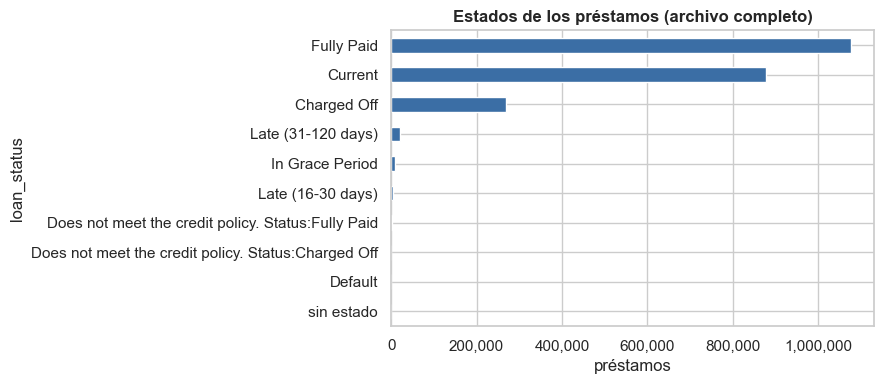

In [6]:
estados = df["loan_status"].value_counts(dropna=False).rename("préstamos").to_frame()
estados["%"] = 100 * estados["préstamos"] / len(df)
estados = estados.rename(index={np.nan: "sin estado"})
display(estados)

fig, ax = plt.subplots(figsize=(9, 4))
estados["préstamos"].iloc[::-1].plot.barh(ax=ax, color="#3b6ea5")
ax.set(title="Estados de los préstamos (archivo completo)", xlabel="préstamos")
ax.xaxis.set_major_formatter(lambda v, pos: f"{v:,.0f}")
plt.tight_layout()
plt.show()

Esa definición marcaría como `0 = Fully Paid` a **todos** los préstamos que no son
*Charged Off*, incluidos 878 317 préstamos *Current* (siguen pagándose; su desenlace aún no se
conoce), además de 34 252 atrasados o en periodo de gracia y 2 822 filas en otros estados. Etiquetar
como pagados a los vigentes sesgaría la etiqueta (mezclaría "pagó" con "todavía no se sabe") y
reduciría la tasa de incumplimiento aparente del 20.0 % al 11.9 %.

La variable objetivo se define entonces solo para préstamos con desenlace conocido: `Fully Paid` (0) y
`Charged Off` (1). La restricción se aplica por igual a todas las filas y no es un muestreo: se lee y
procesa el archivo completo.

In [7]:
literal = (df["loan_status"] == "Charged Off").astype(int)
resuelto = df["loan_status"].isin(lc.RESOLVED)
comp = pd.DataFrame({
    "filas": [len(df), int(resuelto.sum())],
    "default = 1": [int(literal.sum()), int((df.loc[resuelto, "loan_status"] == "Charged Off").sum())],
}, index=["Fórmula literal (todo el archivo)", "Solo desenlace conocido (Fully Paid / Charged Off)"])
comp["tasa de incumplimiento"] = comp["default = 1"] / comp["filas"]
display(comp.style.format({"filas": "{:,.0f}", "default = 1": "{:,.0f}", "tasa de incumplimiento": "{:.2%}"}))

# Conteos por año de otorgamiento (estructura del archivo; se usan en la sección 1.10)
anio_todos = pd.to_numeric(df["issue_d"].str[-4:], errors="coerce").dropna().astype(int).value_counts().sort_index()
anio_resueltos = pd.to_numeric(df.loc[resuelto, "issue_d"].str[-4:], errors="coerce").dropna().astype(int).value_counts().sort_index()

,filas,default = 1,tasa de incumplimiento
Fórmula literal (todo el archivo),"2,260,701","268,559",11.88%
Solo desenlace conocido (Fully Paid / Charged Off),"1,345,310","268,559",19.96%


La tasa real de incumplimiento entre préstamos con desenlace conocido es ≈ 20 %; la definición
directa la subestima (≈ 12 %) porque cuenta los préstamos aún vigentes como si fueran buenos.

## 1.3 Partición entrenamiento / prueba (antes de explorar)

Se construye la tabla de modelado (solo desenlace conocido) y se hace **ahora** la partición 80/20
**estratificada** (misma proporción de incumplimientos en ambos lados) con semilla fija. La asignación
se guarda **una sola vez** en `data/split_ids.parquet` con las columnas `id` y `split` (`train` / `test`),
más `fold` (pliegue 0, 1 o 2 de las filas de entrenamiento, también estratificado) y `rank` (orden aleatorio
fijo, para los experimentos de escala). Todos los capítulos (scikit-learn y PySpark) leen
**exactamente este archivo**: así se comparan modelos sobre los mismos préstamos (requisito de la prueba de
DeLong) y ambos entornos validan con **los mismos 3 pliegues**.

**A partir de aquí, el conjunto de prueba no se toca**: se descarta de la memoria de este cuaderno.

In [8]:
m_all = lc.build_model_frame(df[lc.RAW_COLUMNS])
split = lc.make_split(m_all)
split.to_parquet(DATA_DIR / "split_ids.parquet", index=False)
es_test = (split["split"] == "test").to_numpy()
print(f"Población modelada: {len(m_all):,} préstamos · entrenamiento {int((~es_test).sum()):,} "
      f"({100 * (~es_test).mean():.0f} %) · prueba {int(es_test.sum()):,} ({100 * es_test.mean():.0f} %)")
print(f"Estratificación: incumplimiento en train {m_all.loc[~es_test, 'default'].mean():.4f} · "
      f"en test {m_all.loc[es_test, 'default'].mean():.4f} (deben ser casi idénticos)")
print("Pliegues de validación cruzada (solo entrenamiento):",
      split.loc[~es_test, "fold"].value_counts().sort_index().to_dict(),
      "· columnas guardadas:", ["id", "split", "fold", "rank"])

# Se conservan SOLO las filas de entrenamiento (tabla de modelado y las 151 columnas originales).
m = m_all.loc[~es_test].reset_index(drop=True)
pos_resueltos = np.flatnonzero(resuelto.to_numpy())              # posiciones en df de los préstamos con desenlace
df_tr = df.iloc[pos_resueltos[~es_test]]                          # sus filas de entrenamiento, con todas las columnas
n_train, n_test = int((~es_test).sum()), int(es_test.sum())
del df, m_all, split, literal
gc.collect()
print(f"Memoria del proceso tras separar el test: {proc.memory_info().rss / 1e9:.2f} GB · "
      f"de aquí en adelante solo existe el entrenamiento ({len(m):,} filas)")

Población modelada: 1,345,310 préstamos · entrenamiento 1,076,248 (80 %) · prueba 269,062 (20 %)
Estratificación: incumplimiento en train 0.1996 · en test 0.1996 (deben ser casi idénticos)
Pliegues de validación cruzada (solo entrenamiento): {0: 358750, 1: 358749, 2: 358749} · columnas guardadas: ['id', 'split', 'fold', 'rank']


Memoria del proceso tras separar el test: 2.29 GB · de aquí en adelante solo existe el entrenamiento (1,076,248 filas)


## 1.4 Auditoría de fuga de datos (*data leakage*)

Lending Club publica columnas que se generan **después** de otorgar el préstamo (pagos recibidos,
recuperaciones, último pago…). Un modelo que las use incurriría en fuga de datos: aprendería del
desenlace, y ese modelo jamás podría usarse para decidir a quién prestar. Se mide qué tan
informativas son (AUC de cada columna por separado contra `default`; 0.5 = nada, 1.0 = perfecta)
para justificar que **no** se usen.

> **Nota.** `int_rate` sí está disponible al originar el préstamo, así que no es fuga temporal. Pero la tasa la
> fija Lending Club con su propio modelo de riesgo, por lo que resume parcialmente esa evaluación
> interna. Los resultados que dependen de `int_rate` deben leerse como una predicción condicionada a
> la tasa ya asignada, no como una evaluación de riesgo desde cero.

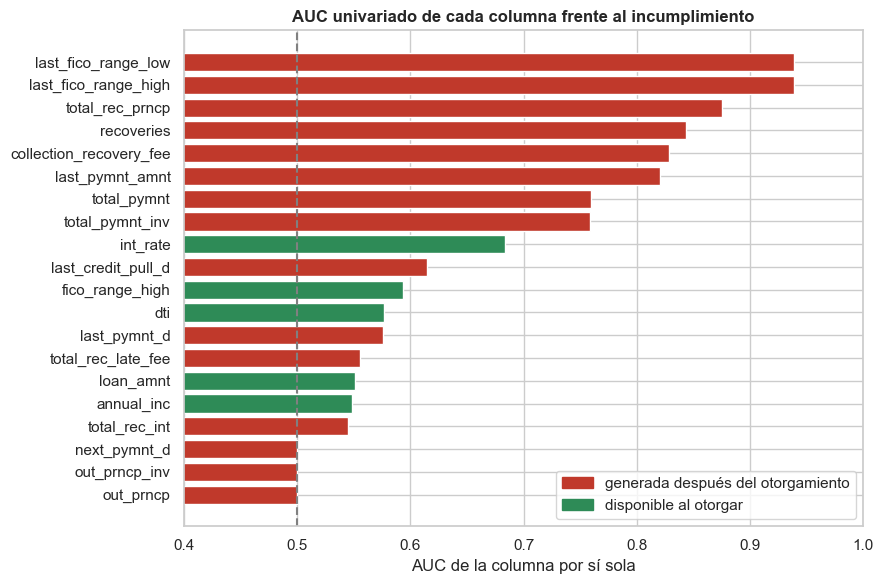

Mayor AUC individual entre columnas posteriores al préstamo: last_fico_range_low = 0.939
Mayor AUC individual entre las variables disponibles al originar: int_rate = 0.684
Columnas posteriores con AUC > 0.7: 8 de 15


In [9]:
y_tr = m["default"].to_numpy()
aud = {}
for c in lc.POST_ORIGINATION:
    x = lc._year_month(df_tr[c]) if c.endswith("_d") else pd.to_numeric(df_tr[c], errors="coerce")
    a = roc_auc_score(y_tr, x.fillna(-1).to_numpy())
    aud[c] = max(a, 1 - a)
DISPONIBLES = ["int_rate", "fico_range_high", "dti", "annual_inc", "loan_amnt"]      # disponibles al originar
for c in DISPONIBLES:
    a = roc_auc_score(y_tr, pd.to_numeric(df_tr[c], errors="coerce").fillna(-1).to_numpy())
    aud[c] = max(a, 1 - a)
aud = pd.Series(aud).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(aud.index, aud.values, color=["#2e8b57" if k in DISPONIBLES else "#c0392b" for k in aud.index])
ax.axvline(0.5, color="gray", ls="--")
ax.set(xlim=(0.4, 1.0), xlabel="AUC de la columna por sí sola",
       title="AUC univariado de cada columna frente al incumplimiento")
from matplotlib.patches import Patch  # noqa: E402
ax.legend(handles=[Patch(color="#c0392b", label="generada después del otorgamiento"),
                   Patch(color="#2e8b57", label="disponible al otorgar")], loc="lower right")
plt.tight_layout()
plt.show()
post = aud[[i for i in aud.index if i not in DISPONIBLES]]
AUD_MAX = float(post.max())
disp = aud[DISPONIBLES]
print(f"Mayor AUC individual entre columnas posteriores al préstamo: {post.idxmax()} = {AUD_MAX:.3f}")
print(f"Mayor AUC individual entre las variables disponibles al originar: {disp.idxmax()} = {disp.max():.3f}")
print(f"Columnas posteriores con AUC > 0.7: {int((post > 0.7).sum())} de {len(post)}")

Varias columnas generadas después del préstamo separan por sí solas a los
incumplidores mucho mejor que cualquier variable disponible al originar (comparar las barras rojas
con las verdes). Un modelo que las use tendría un AUC casi perfecto y un valor práctico **nulo**:
no se pueden conocer al decidir a quién prestar. Por eso el modelo usa solo variables conocidas en
el momento de otorgar el préstamo (lista en `src/lc_utils.py`).

## 1.5 Valores faltantes

### 1.5.1 Panorama de las 151 columnas (filas de entrenamiento)

Columnas sin ningún nulo: 47 · con >70 % nulos: 42 · con >30 % nulos: 58


,nulos,%
next_pymnt_d,1076248,100.000
member_id,1076248,100.000
orig_projected_additional_accrued_interest,1073233,99.720
hardship_start_date,1071605,99.569
hardship_length,1071605,99.569
hardship_type,1071605,99.569
hardship_reason,1071605,99.569
hardship_status,1071605,99.569
deferral_term,1071605,99.569
hardship_amount,1071605,99.569


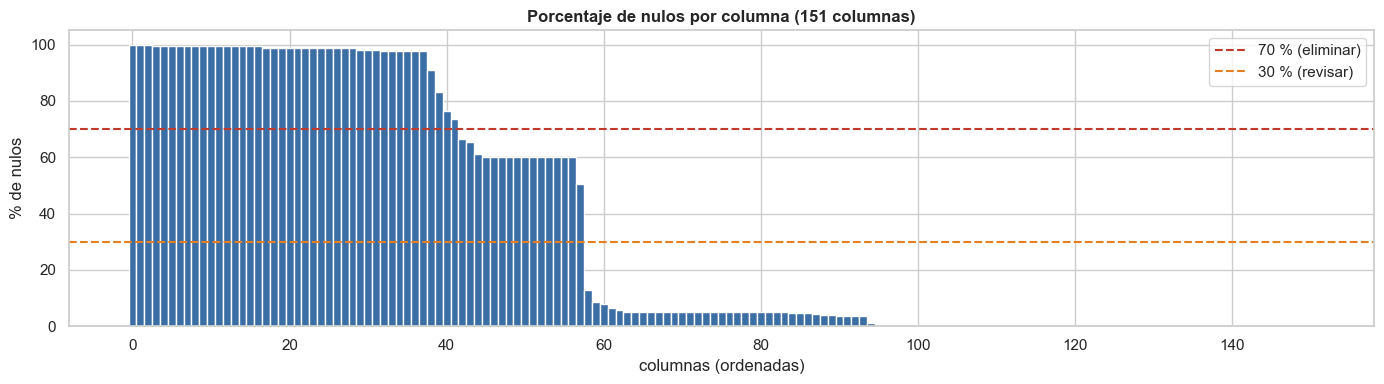

In [10]:
nulos = pd.DataFrame({"nulos": df_tr.isna().sum(), "%": 100 * df_tr.isna().mean()}).sort_values("%", ascending=False)
nulos.to_csv(RESULTS / "nulos_por_columna.csv")
N_MAS70, N_MAS30 = int((nulos["%"] > 70).sum()), int((nulos["%"] > 30).sum())
print(f"Columnas sin ningún nulo: {(nulos['nulos'] == 0).sum()} · con >70 % nulos: {N_MAS70} · con >30 % nulos: {N_MAS30}")
display(nulos.head(20))

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(nulos)), nulos["%"].values, color="#3b6ea5", width=1.0)
ax.axhline(70, color="#c0392b", ls="--", label="70 % (eliminar)")
ax.axhline(30, color="#e67e22", ls="--", label="30 % (revisar)")
ax.set(xlabel="columnas (ordenadas)", ylabel="% de nulos", title="Porcentaje de nulos por columna (151 columnas)")
ax.legend()
plt.tight_layout()
plt.show()

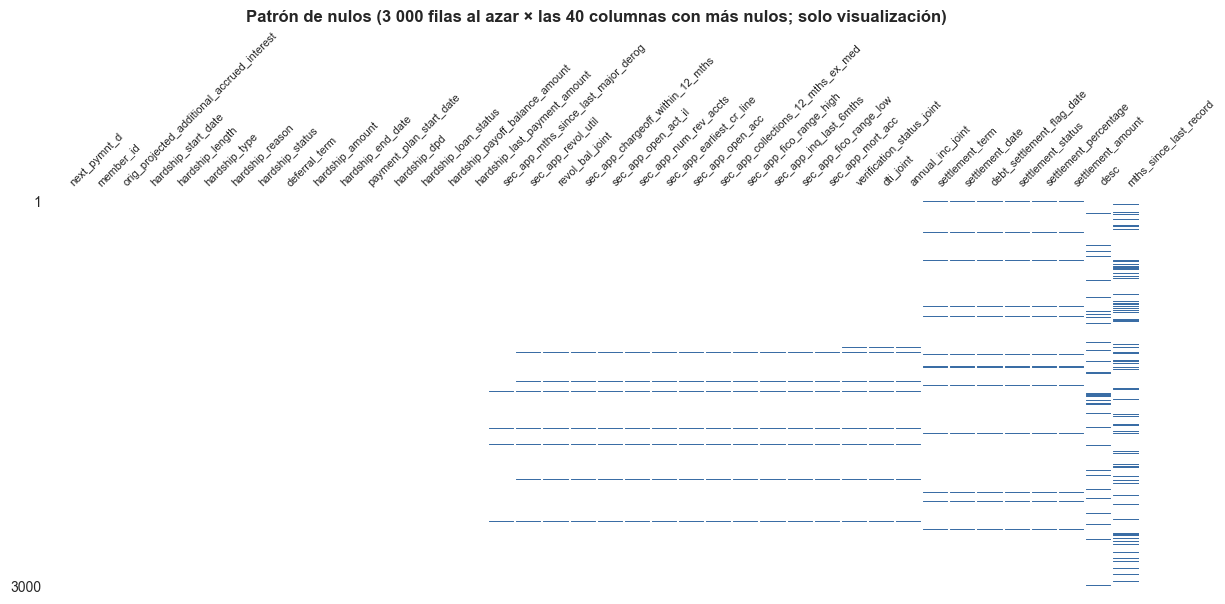

,columnas con >70 % de nulos
joint / co-solicitante,16
hardship,11
otras,9
settlement,6


In [11]:
top40 = nulos.head(40).index.tolist()
muestra = df_tr[top40].sample(3000, random_state=lc.SEED)     # solo para dibujar el patrón
msno.matrix(muestra, figsize=(14, 5), sparkline=False, fontsize=8, color=(0.23, 0.43, 0.65))
plt.title("Patrón de nulos (3 000 filas al azar × las 40 columnas con más nulos; solo visualización)")
plt.show()
prefijos = pd.Series([("hardship" if "hardship" in c else "settlement" if "settlement" in c else
                       "joint / co-solicitante" if ("joint" in c or c.startswith("sec_app")) else "otras")
                      for c in nulos[nulos["%"] > 70].index]).value_counts().rename("columnas con >70 % de nulos")
display(prefijos.to_frame())

Los nulos **no están repartidos al azar**: se concentran en bloques de columnas que se
vacían juntas (la tabla anterior agrupa las de más de 70 %: *hardship*, *settlement*, préstamos
conjuntos / co-solicitantes…). Es un patrón *sistemático* (depende del tipo de préstamo o de qué
empezó a registrar Lending Club y cuándo), no aleatorio.

### 1.5.2 Plan de tratamiento (regla por columna)

| Porcentaje de nulos | Tratamiento |
|---|---|
| > 70 % | Eliminar la columna (casi todas son posteriores al préstamo o de subpoblaciones) |
| 30 % – 70 % | Se excluyen del modelo, salvo justificación explícita (tabla siguiente) |
| < 30 % (variables del modelo) | Numéricas: valor centinela −1 (los árboles lo aíslan como "sin dato"); categóricas: categoría `Desconocido` |

El análisis de las variables que **sí** entran al modelo se presenta en la sección 1.5.3. La tabla
siguiente documenta cada columna de la franja 30–70 %, agrupada por el motivo real de su
nulidad en vez de una única regla genérica.

In [12]:
banda = nulos[(nulos["%"] > 30) & (nulos["%"] <= 70)].copy()
anio_col = pd.to_numeric(df_tr["issue_d"].str[-4:], errors="coerce")
early, late = anio_col <= 2012, anio_col >= 2016
banda["% nulos (préstamos ≤ 2012)"] = [100 * df_tr.loc[early, c].isna().mean() for c in banda.index]
banda["% nulos (préstamos ≥ 2016)"] = [100 * df_tr.loc[late, c].isna().mean() for c in banda.index]
banda["justificación"] = "nulidad estructural: Lending Club empezó a registrar esta variable en años recientes"
banda.loc["mths_since_last_delinq", "justificación"] = (
    "disponible al otorgar el préstamo; el nulo indica ausencia de morosidad registrada, no falta al azar")
banda.loc["mths_since_recent_revol_delinq", "justificación"] = (
    "disponible al otorgar el préstamo; el nulo indica ausencia de morosidad revolvente registrada, no falta al azar")
banda["decisión"] = "excluida (posible mejora: indicador de nulo)"
display(banda[["%", "% nulos (préstamos ≤ 2012)", "% nulos (préstamos ≥ 2016)", "decisión", "justificación"]]
        .rename(columns={"%": "% nulos (train)"}).style.format(
            {"% nulos (train)": "{:.1f}", "% nulos (préstamos ≤ 2012)": "{:.1f}", "% nulos (préstamos ≥ 2016)": "{:.1f}"}))

,% nulos (train),% nulos (préstamos ≤ 2012),% nulos (préstamos ≥ 2016),decisión,justificación
mths_since_recent_revol_delinq,66.5,85.1,65.5,excluida (posible mejora: indicador de nulo),"disponible al otorgar el préstamo; el nulo indica ausencia de morosidad revolvente registrada, no falta al azar"
il_util,65.4,100.0,13.5,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
mths_since_rcnt_il,61.1,100.0,2.6,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
all_util,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
total_cu_tl,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
inq_last_12m,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
open_acc_6m,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
max_bal_bc,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
open_rv_12m,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
total_bal_il,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes


In [13]:
# Se conservan solo columnas auxiliares (alineadas con `m`) para justificar descartes por redundancia.
extra = df_tr[["fico_range_low", "funded_amnt", "grade", "sub_grade"]].reset_index(drop=True)
assert len(extra) == len(m)
del df_tr
gc.collect()
print(f"Memoria del proceso ahora: {proc.memory_info().rss / 1e9:.2f} GB · tabla de modelado (train): {m.shape[0]:,} × {m.shape[1]}")

Memoria del proceso ahora: 1.69 GB · tabla de modelado (train): 1,076,248 × 24


### 1.5.3 Faltantes en las variables del modelo

,nulos,%
emp_length,62826,5.838
mort_acc,37953,3.526
revol_util,695,0.065
dti,296,0.028
inq_last_6mths,1,0.000


Con menos de 10 filas con nulo, la tasa de default y el χ² no son fiables y se dejan en blanco (inq_last_6mths).


,n con nulo,tasa default si falta,tasa default si no falta,diferencia,chi² p-valor
variable,,,,,
emp_length,62826,0.269,0.195,0.074,0.000
mort_acc,37953,0.145,0.202,-0.056,0.000
revol_util,695,0.209,0.200,0.009,0.552
dti,296,0.186,0.200,-0.014,0.552
inq_last_6mths,1,NaN,0.200,NaN,NaN


,emp_length,mort_acc,revol_util,dti,inq_last_6mths
año,,,,,
2007,0.0 %,100.0 %,0.0 %,0.0 %,0.0 %
2009,0.0 %,100.0 %,0.3 %,0.0 %,0.0 %
2011,3.5 %,100.0 %,0.1 %,0.0 %,0.0 %
2012,3.6 %,14.1 %,0.1 %,0.0 %,0.0 %
2013,4.4 %,0.0 %,0.1 %,0.0 %,0.0 %
2015,5.9 %,0.0 %,0.0 %,0.0 %,0.0 %
2018,8.8 %,0.0 %,0.1 %,0.3 %,0.0 %


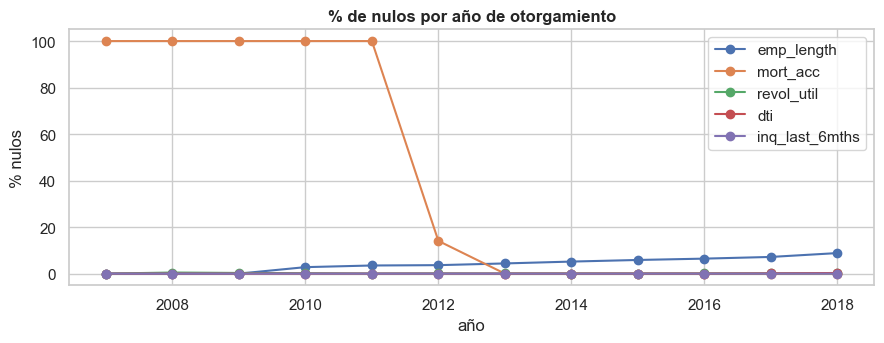

In [14]:
nm = m[lc.FEATURES].isna().sum().rename("nulos").to_frame()
nm["%"] = 100 * nm["nulos"] / len(m)
nm = nm[nm["nulos"] > 0].sort_values("%", ascending=False)
display(nm)

# ¿Se relacionan los nulos con el objetivo? (si sí, no son "completamente al azar", MCAR)
filas = []
for c in nm.index:
    falta = m[c].isna()
    n_falta = int(falta.sum())
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(falta, m["default"]), correction=False)
    filas.append({"variable": c, "n con nulo": n_falta,
                  "tasa default si falta": m.loc[falta, "default"].mean() if n_falta >= 10 else np.nan,
                  "tasa default si no falta": m.loc[~falta, "default"].mean(),
                  "diferencia": (m.loc[falta, "default"].mean() - m.loc[~falta, "default"].mean()) if n_falta >= 10 else np.nan,
                  "chi² p-valor": p if n_falta >= 10 else np.nan})
mcar = pd.DataFrame(filas).set_index("variable")
print("Con menos de 10 filas con nulo, la tasa de default y el χ² no son fiables y se dejan en blanco "
      f"({', '.join(mcar.index[mcar['n con nulo'] < 10])}).")
display(mcar)

nulos_anio = pd.DataFrame({c: m.groupby("issue_year")[c].apply(lambda s: 100 * s.isna().mean()) for c in nm.index})
display(nulos_anio.loc[[a for a in (2007, 2009, 2011, 2012, 2013, 2015, 2018) if a in nulos_anio.index]]
        .rename_axis("año").style.format("{:.1f} %"))
fig, ax = plt.subplots(figsize=(9, 3.6))
for c in nm.index:
    nulos_anio[c].plot(ax=ax, label=c, marker="o")
ax.set(title="% de nulos por año de otorgamiento", ylabel="% nulos", xlabel="año")
ax.legend()
plt.tight_layout()
plt.show()

Las tablas anteriores responden a dos preguntas:

* **¿Son nulos "al azar" (MCAR)?** Donde el χ² es significativo **y** la diferencia de tasas es
  material (`emp_length`, `mort_acc`), faltar **está relacionado con el desenlace**: no son MCAR.
  Imputar con la media borraría esa señal. Es un motivo para usar el centinela −1 en lugar de un
  estadístico y dejar que el árbol decida si "sin dato" es informativo.
* **¿Son estructurales?** En las variables donde el porcentaje de nulos depende fuertemente del año
  (tabla y gráfico por año), el faltante nace de **cuándo** se registró la variable, no de un error
  aleatorio.

Para las variables con muy pocos nulos (`revol_util`, `dti`, `inq_last_6mths`) el χ² no muestra
relación con el objetivo: el tratamiento es indiferente.

## 1.6 Análisis univariado

### 1.6.1 Variables numéricas

In [15]:
def resumen_numerico(s: pd.Series) -> dict:
    q1, q2, q3 = s.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = s.notna().sum()
    fuera = int(((s < lo) | (s > hi)).sum())
    return {"n": n, "faltantes %": 100 * s.isna().mean(), "media": s.mean(), "mediana": q2,
            "desv. est.": s.std(), "mín": s.min(), "P25": q1, "P75": q3, "máx": s.max(), "IQR": iqr,
            "límite inf.": lo, "límite sup.": hi, "outliers": fuera, "outliers %": 100 * fuera / n,
            "asimetría": s.skew(), "curtosis": s.kurt()}


tabla_num = pd.DataFrame({c: resumen_numerico(m[c]) for c in lc.NUMERIC}).T
tabla_num.to_csv(RESULTS / "eda_numericas.csv")
display(tabla_num[["n", "faltantes %", "media", "mediana", "desv. est.", "mín", "P25", "P75", "máx", "IQR"]])
display(tabla_num[["límite inf.", "límite sup.", "outliers", "outliers %", "asimetría", "curtosis"]])

,n,faltantes %,media,mediana,desv. est.,mín,P25,P75,máx,IQR
loan_amnt,"1,076,248.000",0.000,"14,420.946","12,000.000","8,719.169",500.000,"8,000.000","20,000.000","40,000.000","12,000.000"
int_rate,"1,076,248.000",0.000,13.242,12.740,4.771,5.310,9.750,15.990,30.990,6.240
installment,"1,076,248.000",0.000,438.117,375.430,261.582,4.930,248.460,580.730,"1,719.830",332.270
annual_inc,"1,076,248.000",0.000,"76,241.938","65,000.000","69,566.288",0.000,"45,802.770","90,000.000","9,550,000.000","44,197.230"
dti,"1,075,952.000",0.028,18.286,17.620,11.333,-1.000,11.790,24.060,999.000,12.270
fico_range_high,"1,076,248.000",0.000,700.193,694.000,31.872,629.000,674.000,714.000,850.000,40.000
emp_length,"1,013,422.000",5.838,5.965,6.000,3.691,0.000,2.000,10.000,10.000,8.000
open_acc,"1,076,248.000",0.000,11.593,11.000,5.479,0.000,8.000,14.000,90.000,6.000
revol_bal,"1,076,248.000",0.000,"16,246.323","11,135.000","22,252.252",0.000,"5,944.000","19,760.000","2,904,836.000","13,816.000"
revol_util,"1,075,553.000",0.065,51.821,52.200,24.527,0.000,33.500,70.800,892.300,37.300


,límite inf.,límite sup.,outliers,outliers %,asimetría,curtosis
loan_amnt,"-10,000.000","38,000.000","5,710.000",0.531,0.782,-0.085
int_rate,0.390,25.350,"20,025.000",1.861,0.714,0.508
installment,-249.945,"1,079.135","33,622.000",3.124,1.006,0.747
annual_inc,"-20,493.075","156,295.845","52,607.000",4.888,45.071,"4,591.357"
dti,-6.615,42.465,"4,318.000",0.401,28.428,"2,198.375"
fico_range_high,614.000,774.000,"37,258.000",3.462,1.286,1.660
emp_length,-10.000,22.000,0.000,0.000,-0.217,-1.499
open_acc,-1.000,23.000,"36,939.000",3.432,1.305,3.419
revol_bal,"-14,780.000","40,484.000","63,769.000",5.925,13.239,670.719
revol_util,-22.450,126.750,60.000,0.006,-0.028,0.504


**Valores imposibles o sospechosos** (más allá de los valores atípicos en sentido estadístico):

In [16]:
sospechosos = pd.Series({
    "dti = -1 (dato inválido)": int((m["dti"] < 0).sum()),
    "dti > 100 (más de 100 % de la deuda sobre ingreso)": int((m["dti"] > 100).sum()),
    "revol_util > 100 (uso de crédito > 100 %)": int((m["revol_util"] > 100).sum()),
    "annual_inc = 0": int((m["annual_inc"] == 0).sum()),
    "annual_inc > 1 000 000": int((m["annual_inc"] > 1_000_000).sum()),
}, name="filas")
sospechosos_pct = (100 * sospechosos / len(m)).rename("% de las filas")
display(pd.concat([sospechosos, sospechosos_pct], axis=1))

,filas,% de las filas
dti = -1 (dato inválido),1,0.000
dti > 100 (más de 100 % de la deuda sobre ingreso),428,0.040
revol_util > 100 (uso de crédito > 100 %),3781,0.351
annual_inc = 0,283,0.026
annual_inc > 1 000 000,242,0.022


Solo `dti = -1` se trata como faltante: coincide con el centinela −1 que usa el imputador
(sección 2.3), así que ese caso queda cubierto sin código adicional. Los demás valores de la tabla
(`dti` o `revol_util` por encima de 100, ingresos en cero o superiores al millón, historial de
crédito negativo) **no se recodifican**: son pocos, son valores extremos pero no imposibles para
estas variables, y los modelos de árbol no los tratan de forma especial.

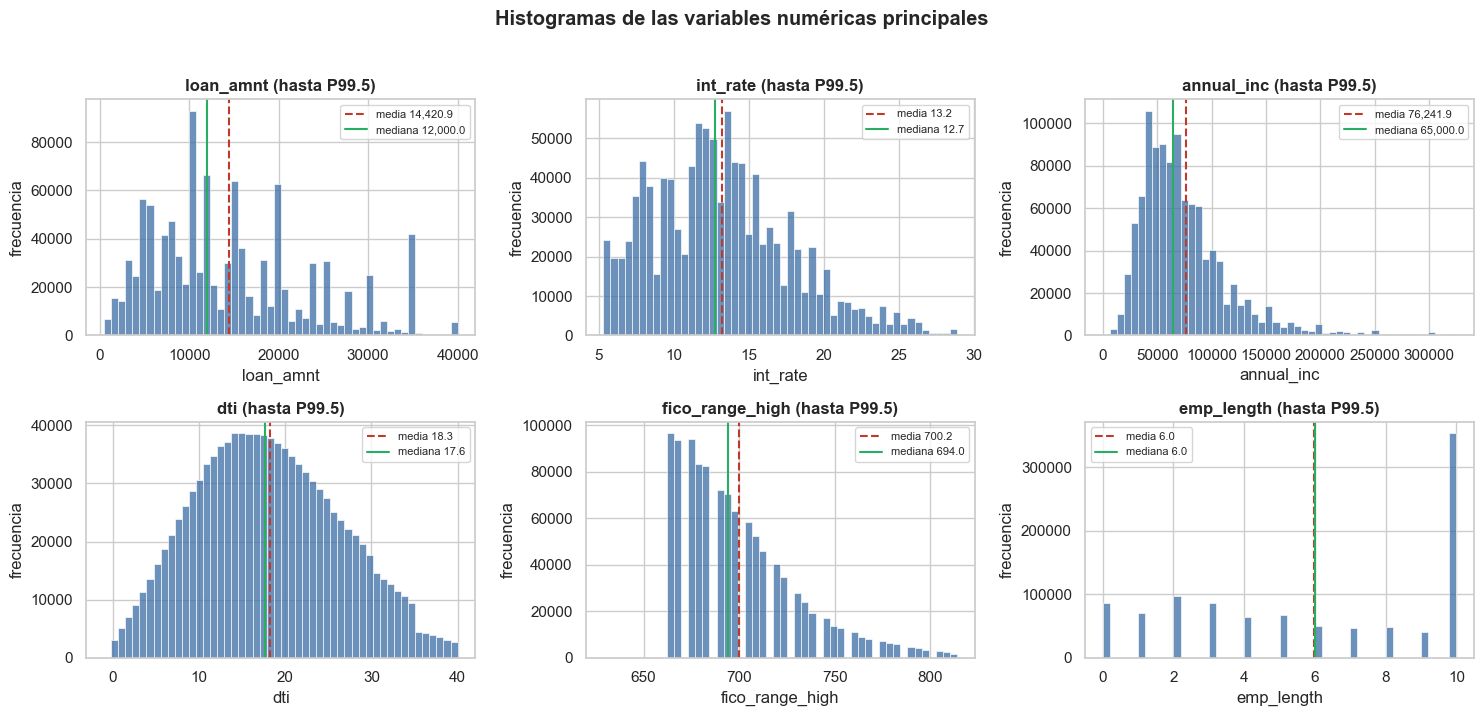

In [17]:
graficas = ["loan_amnt", "int_rate", "annual_inc", "dti", "fico_range_high", "emp_length"]
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for a, c in zip(ax.ravel(), graficas):
    s = m[c].dropna()
    tope = s.quantile(0.995)         # solo para dibujar: recorta la cola extrema del gráfico
    sns.histplot(s[s <= tope], bins=50, ax=a, color="#3b6ea5")
    a.axvline(s.mean(), color="#c0392b", ls="--", label=f"media {s.mean():,.1f}")
    a.axvline(s.median(), color="#27ae60", ls="-", label=f"mediana {s.median():,.1f}")
    a.set(title=f"{c} (hasta P99.5)", ylabel="frecuencia")
    a.legend(fontsize=8)
plt.suptitle("Histogramas de las variables numéricas principales", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

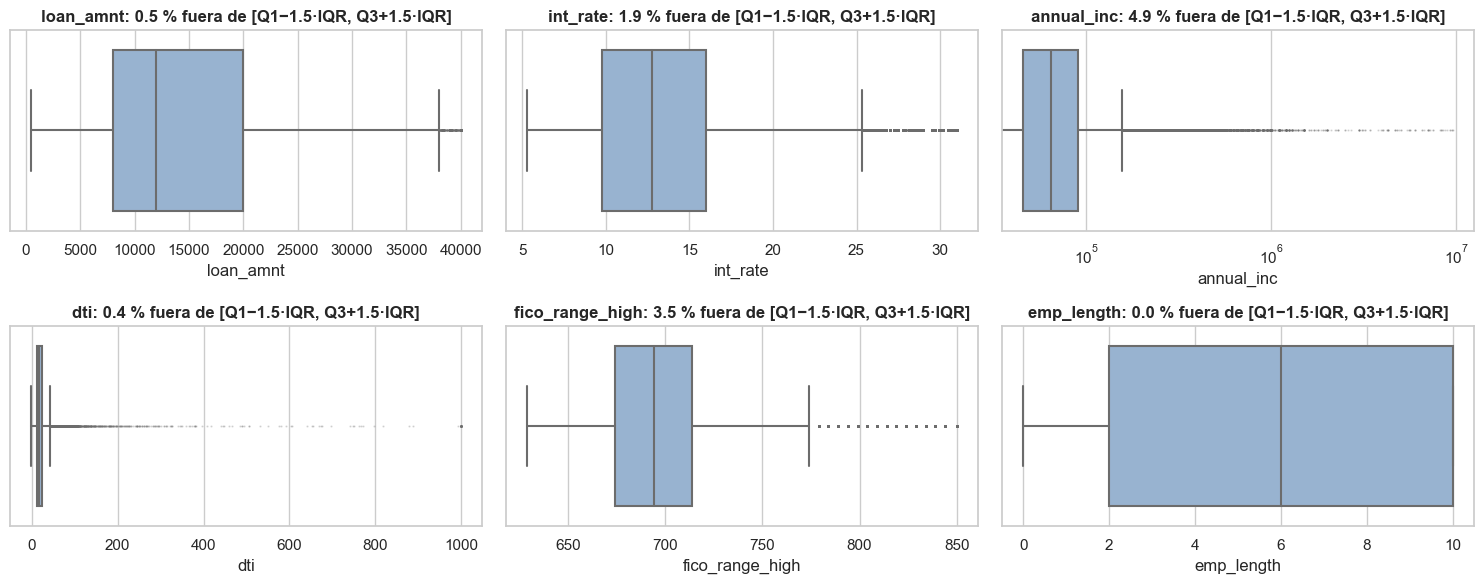

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
for a, c in zip(ax.ravel(), graficas):
    sns.boxplot(x=m[c], ax=a, color="#8fb3d9", fliersize=0.6, flierprops={"alpha": 0.25, "markersize": 0.6})
    a.set(title=f"{c}: {tabla_num.loc[c, 'outliers %']:.1f} % fuera de [Q1−1.5·IQR, Q3+1.5·IQR]")
    if c == "annual_inc":
        a.set_xscale("log")
plt.tight_layout()
plt.show()

El método del IQR no distingue por sí solo un valor extremo **posible** de uno **inválido**; esa
distinción se hace variable por variable, a partir de lo que cada una puede tomar en la realidad:

* `annual_inc`, `revol_bal`, `dti` y `revol_util` tienen colas muy largas (asimetría muy alta,
  ingresos de millones, `dti` hasta 999): el método del IQR marca varios puntos porcentuales como
  atípicos. Salvo `dti = -1` (tabla de valores sospechosos, más arriba en esta sección, tratado
  como faltante por coincidir con el centinela), el resto son valores extremos pero posibles
  (ingresos altos, deudas muy comprometidas) y se conservan sin modificar.
* En **conteos casi siempre cero** (`pub_rec`, `delinq_2yrs`) el IQR es 0 y cualquier valor
  distinto de cero cuenta como atípico (≈ 17–19 %): el método **no aplica** a esas variables, así
  que no se recodifica nada por este criterio.
* `int_rate`, `fico_range_high` y `loan_amnt` son más simétricas y no presentan este problema.
* **Normalidad.** Con más de un millón de filas cualquier prueba (Shapiro-Wilk, D'Agostino)
  rechaza normalidad por desviaciones mínimas, así que no informa. Son más útiles la **asimetría y la
  curtosis** (tabla) y el histograma. Más abajo se reporta Shapiro-Wilk sobre 5 000 datos (el tamaño hasta
  el que la implementación de SciPy garantiza la precisión del valor p) solo como referencia.

In [19]:
norm = []
for c in lc.NUMERIC:
    es_binaria = m[c].nunique() <= 2
    s = m[c].dropna().sample(5000, random_state=lc.SEED)
    w, p = stats.shapiro(s)
    log_skew = np.log1p(m[c].dropna().clip(lower=0)).skew()
    reduce_suficiente = abs(m[c].skew()) > 1 and abs(log_skew) < 0.5 * abs(m[c].skew())
    norm.append({"variable": c, "asimetría": m[c].skew(), "asimetría tras log1p": log_skew,
                 "Shapiro W (n=5000)": w, "p-valor": p,
                 "¿transformar?": "no aplica (binaria)" if es_binaria else ("sí (log)" if reduce_suficiente else "no")})
display(pd.DataFrame(norm).set_index("variable"))

,asimetría,asimetría tras log1p,Shapiro W (n=5000),p-valor,¿transformar?
variable,,,,,
loan_amnt,0.782,-0.652,0.939,0.000,no
int_rate,0.714,-0.125,0.963,0.000,no
installment,1.006,-0.596,0.933,0.000,no
annual_inc,45.071,-1.866,0.641,0.000,sí (log)
dti,28.428,-1.120,0.777,0.000,sí (log)
fico_range_high,1.286,1.158,0.882,0.000,no
emp_length,-0.217,-0.971,0.851,0.000,no
open_acc,1.305,-0.131,0.918,0.000,sí (log)
revol_bal,13.239,-2.651,0.521,0.000,sí (log)


No se aplica ninguna transformación logarítmica a estas variables. Los modelos de árbol (árbol de
decisión, bosque aleatorio, *gradient boosting*) son invariantes a transformaciones monótonas: dependen
solo del *orden* de los valores, así que log o Box-Cox no cambian sus particiones. La regresión
logística y la SVM lineal se entrenan con variables estandarizadas (`StandardScaler`), que igualan la
escala entre variables pero no corrigen la asimetría. Naive Bayes gaussiano es invariante a cambios
lineales de escala (estandarizar no cambia sus predicciones), pero sí supone normalidad dentro de cada
clase, así que es el modelo más afectado por las colas largas de `annual_inc`, `revol_bal` y `dti`: una
transformación logarítmica sí le habría servido a este modelo en particular. Es una limitación
declarada y una causa posible de su menor AUC en los capítulos 2 y 3 (≈ 0.688).

### 1.6.2 Variables categóricas

In [20]:
COL_RARA = "< 1 % (agrupar en 'Otros')"


def tabla_cat(s: pd.Series) -> pd.DataFrame:
    t = s.value_counts(dropna=False).rename("frecuencia").to_frame()
    t["frecuencia relativa %"] = 100 * t["frecuencia"] / len(s)
    t[COL_RARA] = t["frecuencia relativa %"] < 1
    return t


freq_cat = {c: tabla_cat(m[c]) for c in lc.CATEGORICAL + ["term_months"]}
for c, t in freq_cat.items():
    print(f"\n=== {c}: {len(t)} categorías · {int(t[COL_RARA].sum())} con menos del 1 % ===")
    display(t.head(15))


=== purpose: 14 categorías · 6 con menos del 1 % ===


,frecuencia,frecuencia relativa %,< 1 % (agrupar en 'Otros')
purpose,,,
debt_consolidation,624146,57.993,False
credit_card,236042,21.932,False
home_improvement,70201,6.523,False
other,62350,5.793,False
major_purchase,23471,2.181,False
medical,12448,1.157,False
small_business,12397,1.152,False
car,11684,1.086,False
moving,7617,0.708,True



=== home_ownership: 6 categorías · 3 con menos del 1 % ===


,frecuencia,frecuencia relativa %,< 1 % (agrupar en 'Otros')
home_ownership,,,
MORTGAGE,532404,49.469,False
RENT,427791,39.748,False
OWN,115673,10.748,False
ANY,223,0.021,True
OTHER,117,0.011,True
NONE,40,0.004,True



=== addr_state: 51 categorías · 23 con menos del 1 % ===


,frecuencia,frecuencia relativa %,< 1 % (agrupar en 'Otros')
addr_state,,,
CA,157101,14.597,False
NY,88128,8.188,False
TX,88082,8.184,False
FL,76627,7.120,False
IL,41471,3.853,False
NJ,38725,3.598,False
PA,36345,3.377,False
OH,35171,3.268,False
GA,34613,3.216,False



=== verification_status: 3 categorías · 0 con menos del 1 % ===


,frecuencia,frecuencia relativa %,< 1 % (agrupar en 'Otros')
verification_status,,,
Source Verified,417049,38.750,False
Verified,334591,31.089,False
Not Verified,324608,30.161,False



=== term_months: 2 categorías · 0 con menos del 1 % ===


,frecuencia,frecuencia relativa %,< 1 % (agrupar en 'Otros')
term_months,,,
36,816586,75.873,False
60,259662,24.127,False


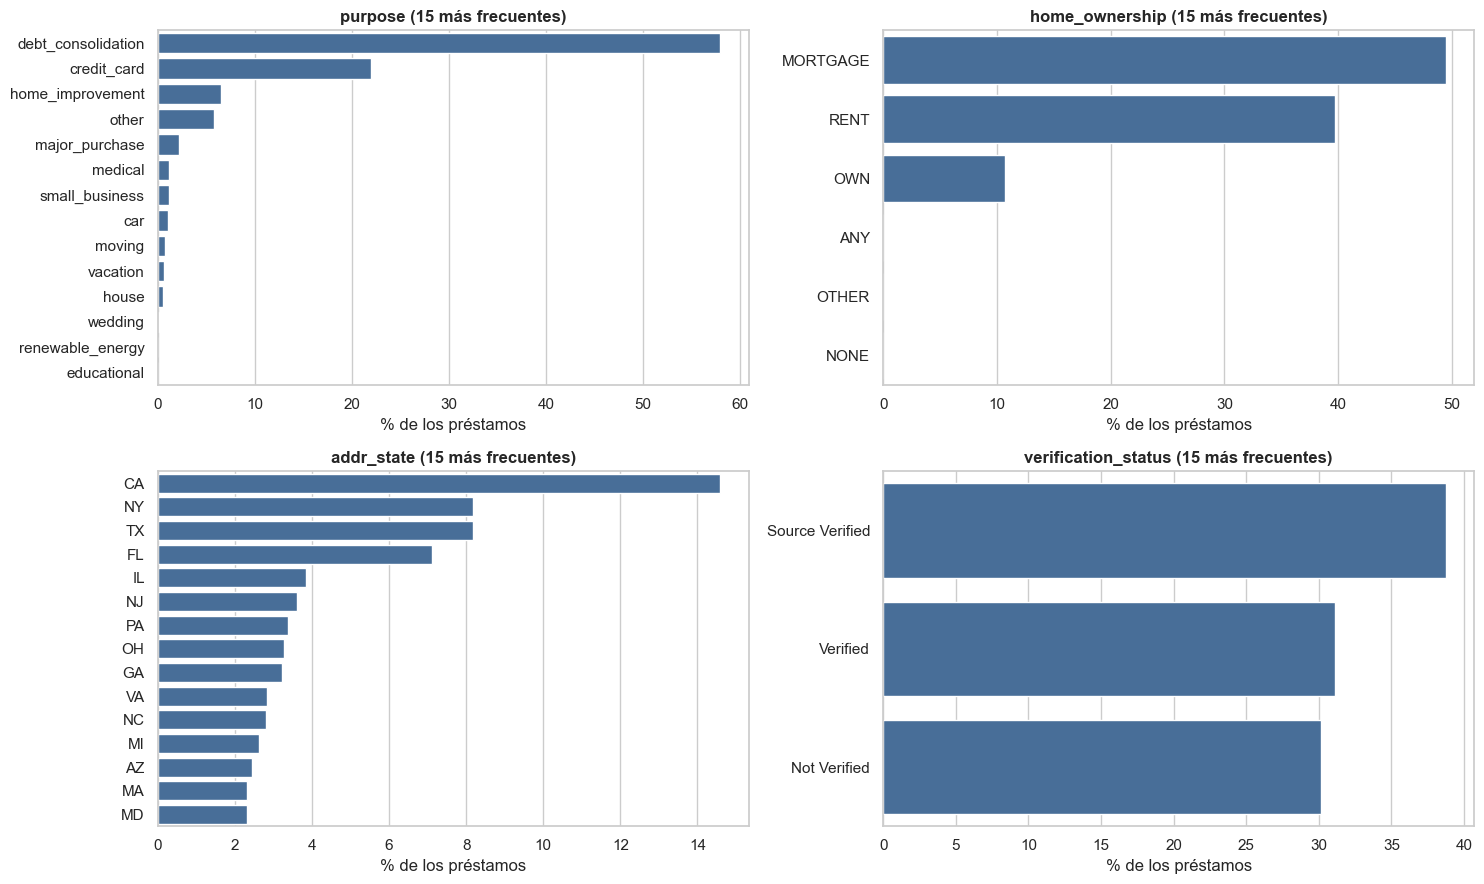

Categorías con < 1 % / total: {'purpose': '6/14', 'home_ownership': '3/6', 'addr_state': '23/51', 'verification_status': '0/3', 'term_months': '0/2'}


In [21]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9))
for a, c in zip(ax.ravel(), lc.CATEGORICAL):
    t = freq_cat[c]["frecuencia relativa %"].head(15)
    sns.barplot(x=t.values, y=t.index, ax=a, color="#3b6ea5")
    a.set(title=f"{c} (15 más frecuentes)", xlabel="% de los préstamos", ylabel="")
plt.tight_layout()
plt.show()
resumen_rara = {c: (int(t[COL_RARA].sum()), len(t)) for c, t in freq_cat.items()}
print("Categorías con < 1 % / total:", {k: f"{a}/{b}" for k, (a, b) in resumen_rara.items()})

De las tablas y el resumen anteriores se desprende lo siguiente:

* `purpose` está dominada por una categoría (`debt_consolidation`) y varias categorías tienen
  menos del 1 % de los préstamos.
* `home_ownership`: hay categorías residuales (`ANY`, `NONE`, `OTHER`) que pueden unificarse.
* `addr_state`: 51 categorías, de las cuales muchas tienen menos del 1 %.
* **Decisión:** las categorías con < 1 % del entrenamiento se agruparán en una sola ("infrecuente")
  en el `OneHotEncoder`. Esto reduce dimensionalidad y evita columnas casi vacías.
* No hay categorías redundantes con distinto nombre; `Desconocido` agrupa los pocos nulos.

### 1.6.3 Variable objetivo `default` y desbalance

,préstamos,%
clase,,
0 = Fully Paid,861401,80.037
1 = Charged Off,214847,19.963


Razón de desbalance: 4.0 pagados por cada incumplido


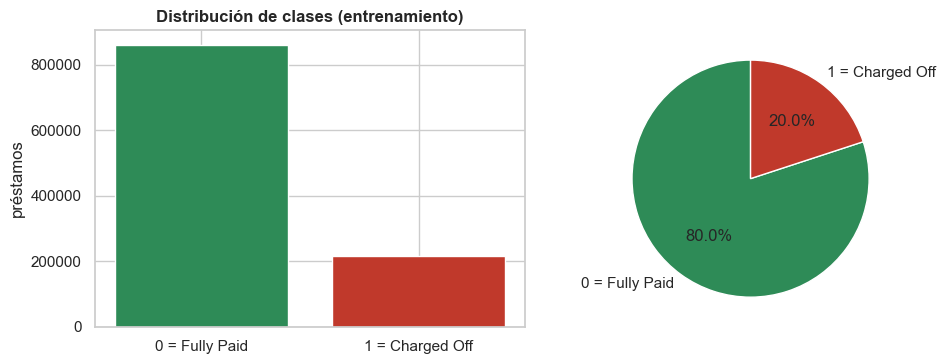

In [22]:
vc = m["default"].value_counts().sort_index()
dist = pd.DataFrame({"clase": ["0 = Fully Paid", "1 = Charged Off"], "préstamos": vc.values,
                     "%": 100 * vc.values / len(m)})
display(dist.set_index("clase"))
RAZON_DESBALANCE = vc[0] / vc[1]
print(f"Razón de desbalance: {RAZON_DESBALANCE:.1f} pagados por cada incumplido")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].bar(dist["clase"], dist["préstamos"], color=["#2e8b57", "#c0392b"])
ax[0].set(title="Distribución de clases (entrenamiento)", ylabel="préstamos")
ax[1].pie(dist["préstamos"], labels=dist["clase"], autopct="%1.1f%%", colors=["#2e8b57", "#c0392b"], startangle=90)
plt.tight_layout()
plt.show()

**Impacto del desbalance (≈ 80 / 20).**

1. **La exactitud es engañosa:** un modelo que predijera "todos pagan" tendría ≈ 80 % de exactitud y sería
   inútil. Se reportan AUC, AUC-PR, sensibilidad (*recall*) y F1.
2. **Estratificar:** la partición entrenamiento/prueba y la validación cruzada mantienen la
   proporción 80/20 en cada pliegue.
3. **Umbral:** con clases desbalanceadas las probabilidades de la clase minoritaria rara vez pasan
   0.5; el umbral de decisión se elegirá con datos de entrenamiento (fuera de pliegue), no con el conjunto de prueba.
4. **Balanceo:** no se aplica remuestreo (SMOTE, etc.) ni pesos por clase (`class_weight`): la clase
   minoritaria tiene más de 200 000 ejemplos en el entrenamiento, suficientes para estimarla, y el desbalance (≈ 4:1) es
   moderado; se maneja con métricas que no dependen de la prevalencia y con el umbral. Los pesos por
   clase o SMOTE son alternativas válidas que **no se probaron aquí**: cambiarían las probabilidades
   del modelo (habría que recalibrarlas) y el umbral óptimo.
5. **Qué error importa más:** en crédito, prestar a quien no pagará (falso negativo) puede perder
   buena parte del capital (menos las recuperaciones); rechazar a quien sí pagaría (falso positivo)
   pierde solo los intereses. Por eso se
   presta atención a la sensibilidad y al F1, y no a la exactitud.

## 1.7 Análisis bidimensional

### 1.7.1 Variables numéricas vs `default`

Con más de un millón de filas, casi toda diferencia resulta "estadísticamente significativa"
(los valores p quedan por debajo de 0.001, muchas veces por debajo de la precisión de impresión):
el tamaño de muestra vuelve significativas diferencias minúsculas. Por eso, además del valor p, se reporta el
**tamaño del efecto**: *d* de Cohen (diferencia de medias en desviaciones estándar) y la
correlación punto-biserial. Criterio de referencia (Cohen, 1988): |d| < 0.2 efecto pequeño · 0.2–0.5 moderado · > 0.5 grande.

In [23]:
# term_months solo toma dos valores (36 o 60 meses): se trata como categórica más abajo, no aquí, donde
# un d de Cohen o una prueba t no tendrían sentido (una variable de dos valores no es continua).
NUM_CONTINUAS = [c for c in lc.NUMERIC if c != "term_months"]
filas = []
for c in NUM_CONTINUAS:
    x1 = m.loc[m["default"] == 1, c].dropna()
    x0 = m.loc[m["default"] == 0, c].dropna()
    n1, n0 = len(x1), len(x0)
    welch = stats.ttest_ind(x1, x0, equal_var=False)
    mw = stats.mannwhitneyu(x1, x0, alternative="two-sided", method="asymptotic")
    sp = np.sqrt(((n1 - 1) * x1.var() + (n0 - 1) * x0.var()) / (n1 + n0 - 2))
    ok = m[c].notna()
    filas.append({"variable": c, "media default=1": x1.mean(), "media default=0": x0.mean(),
                  "dif. de medias": x1.mean() - x0.mean(), "d de Cohen": (x1.mean() - x0.mean()) / sp,
                  "corr. punto-biserial": stats.pointbiserialr(m.loc[ok, "default"], m.loc[ok, c]).statistic,
                  "p Welch": welch.pvalue, "p Mann-Whitney": mw.pvalue})
bi_num = pd.DataFrame(filas).set_index("variable").sort_values("corr. punto-biserial", key=abs, ascending=False)
bi_num.to_csv(RESULTS / "eda_bivariado_numericas.csv")
display(bi_num)

,media default=1,media default=0,dif. de medias,d de Cohen,corr. punto-biserial,p Welch,p Mann-Whitney
variable,,,,,,,
int_rate,15.719,12.624,3.095,0.672,0.259,0.000,0.000
fico_range_high,691.858,702.272,-10.414,-0.330,-0.131,0.000,0.000
dti,20.164,17.818,2.346,0.208,0.083,0.000,0.000
mort_acc,1.370,1.746,-0.376,-0.189,-0.075,0.000,0.000
inq_last_6mths,0.778,0.625,0.153,0.163,0.065,0.000,0.000
loan_amnt,"15,558.321","14,137.267","1,421.054",0.163,0.065,0.000,0.000
revol_util,54.746,51.091,3.655,0.149,0.060,0.000,0.000
installment,465.026,431.406,33.620,0.129,0.051,0.000,0.000
annual_inc,"70,364.974","77,707.745","-7,342.771",-0.106,-0.042,0.000,0.000


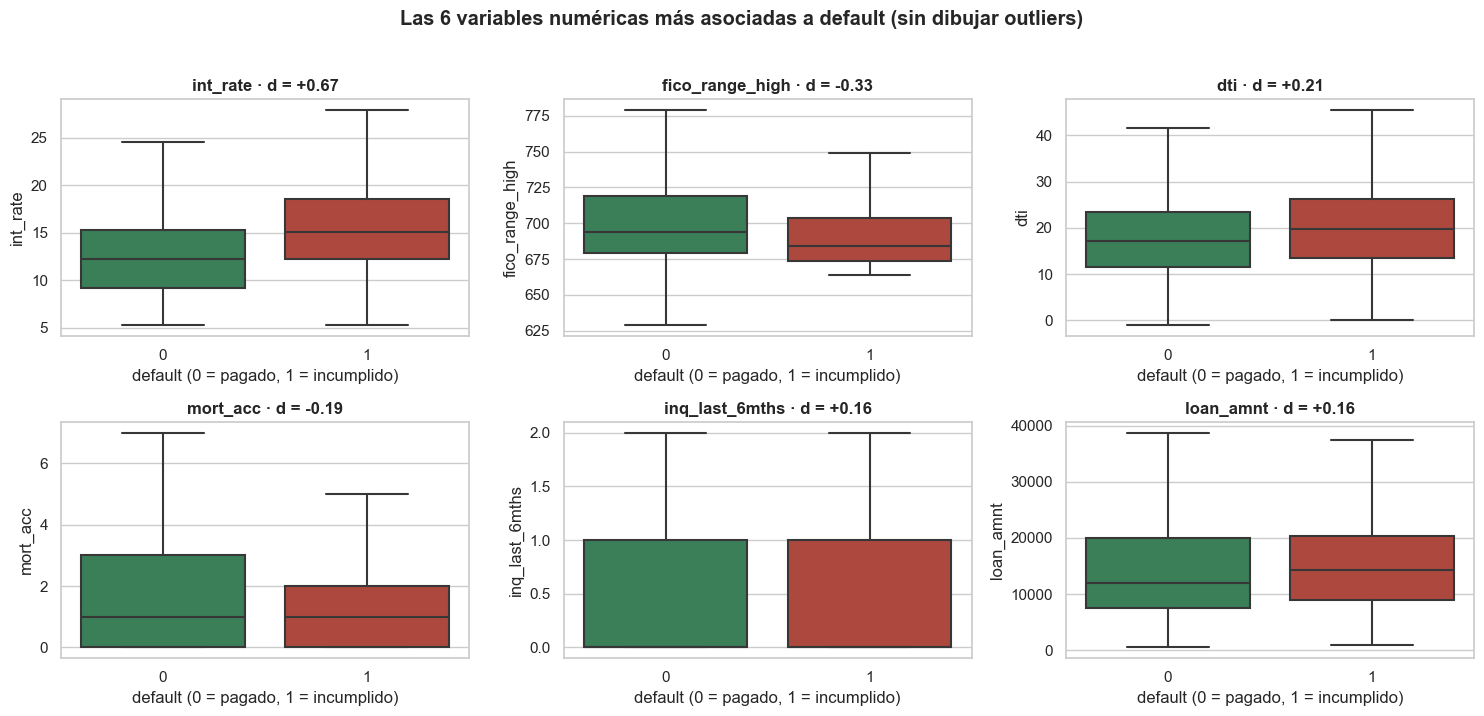

In [24]:
top6 = bi_num.index[:6].tolist()
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for a, c in zip(ax.ravel(), top6):
    sns.boxplot(data=m, x="default", y=c, ax=a, showfliers=False, palette=["#2e8b57", "#c0392b"])
    a.set(title=f"{c} · d = {bi_num.loc[c, 'd de Cohen']:+.2f}", xlabel="default (0 = pagado, 1 = incumplido)")
plt.suptitle("Las 6 variables numéricas más asociadas a default (sin dibujar outliers)", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

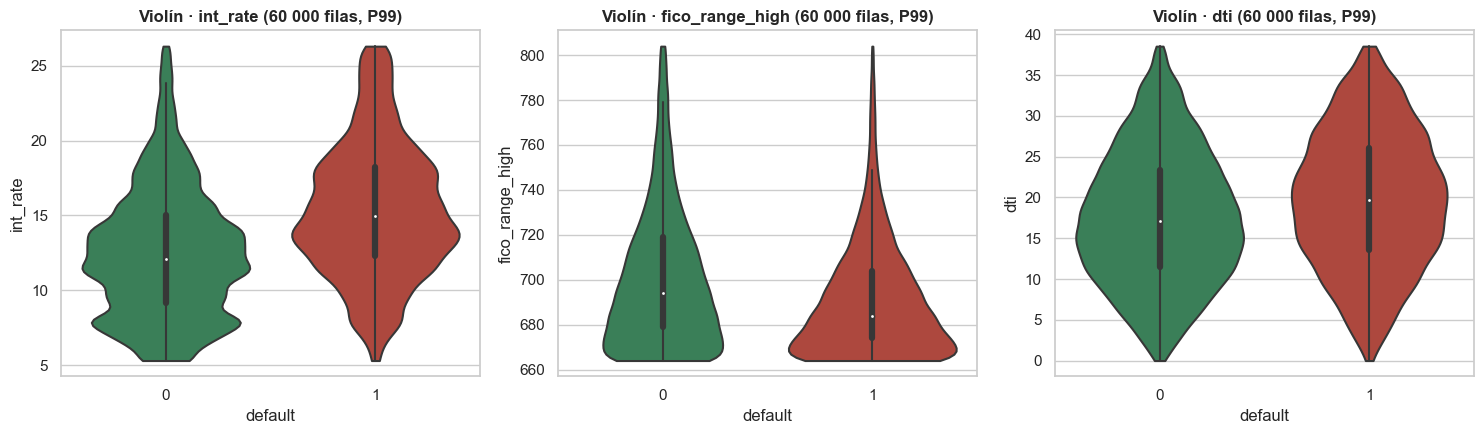

In [25]:
vio = m.sample(60000, random_state=lc.SEED)      # solo para dibujar
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for a, c in zip(ax, ["int_rate", "fico_range_high", "dti"]):
    d = vio[vio[c] <= vio[c].quantile(0.99)]
    sns.violinplot(data=d, x="default", y=c, ax=a, palette=["#2e8b57", "#c0392b"], cut=0)
    a.set(title=f"Violín · {c} (60 000 filas, P99)")
plt.tight_layout()
plt.show()

In [26]:
tabla_term = pd.crosstab(m["term_months"], m["default"])
tasa_term = (100 * m.groupby("term_months")["default"].mean()).rename("tasa de incumplimiento (%)")
v_term = lc.cramers_v(m["term_months"], m["default"])
display(pd.concat([tabla_term, tasa_term], axis=1))
print(f"V de Cramér (term_months vs default) = {v_term:.2f}")

,0,1,tasa de incumplimiento (%)
term_months,,,
36,686017,130569,15.990
60,175384,84278,32.457


V de Cramér (term_months vs default) = 0.18


La tabla ordena las variables **continuas** por su asociación con el incumplimiento. `int_rate` (la
tasa que Lending Club asigna según su propio análisis de riesgo) es, con diferencia, la de mayor
efecto (|d| ≈ 0.7, efecto grande); `fico_range_high` tiene un efecto moderado; `dti` queda justo en el
límite (d ≈ 0.21) y el resto por debajo de 0.2 (efecto pequeño). `term_months`, al ser binaria (36 o
60 meses), se trata aparte: los préstamos a 60 meses incumplen el doble que los de 36 (32.5 % frente a
16.0 %; V de Cramér = 0.18), una asociación moderada. Aun así, "efecto pequeño" no significa "inútil":
varias variables débiles combinadas pueden aportar. Ninguna variable sola separa bien las clases (los
diagramas de caja y de violín se solapan mucho), por eso se espera un AUC moderado.

### 1.7.2 Variables categóricas vs `default`

Tabla de contingencia con la **tasa de incumplimiento** por categoría, prueba χ² de independencia
y **V de Cramér** (tamaño del efecto: < 0.1 débil · 0.1–0.3 moderado · > 0.3 fuerte).

In [27]:
resumen_cat = []
for c in lc.CATEGORICAL + ["term_months"]:
    tab = pd.crosstab(m[c], m["default"])
    chi2, p, dof, _ = stats.chi2_contingency(tab, correction=False)
    resumen_cat.append({"variable": c, "categorías": tab.shape[0], "χ²": chi2, "gl": dof, "p-valor": p,
                        "V de Cramér": lc.cramers_v(m[c], m["default"])})
resumen_cat = pd.DataFrame(resumen_cat).set_index("variable").sort_values("V de Cramér", ascending=False)
resumen_cat.to_csv(RESULTS / "eda_bivariado_categoricas.csv")
display(resumen_cat)
print("Tasa de default por plazo:", {f"{int(k)} meses": f"{v:.1%}" for k, v in m.groupby("term_months")["default"].mean().items()})

,categorías,χ²,gl,p-valor,V de Cramér
variable,,,,,
term_months,2,"33,436.974",1,0.000,0.176
verification_status,3,"9,203.081",2,0.000,0.092
home_ownership,6,"5,402.552",5,0.000,0.071
purpose,14,"3,322.645",13,0.000,0.055
addr_state,51,"2,731.943",50,0.000,0.050


Tasa de default por plazo: {'36 meses': '16.0%', '60 meses': '32.5%'}


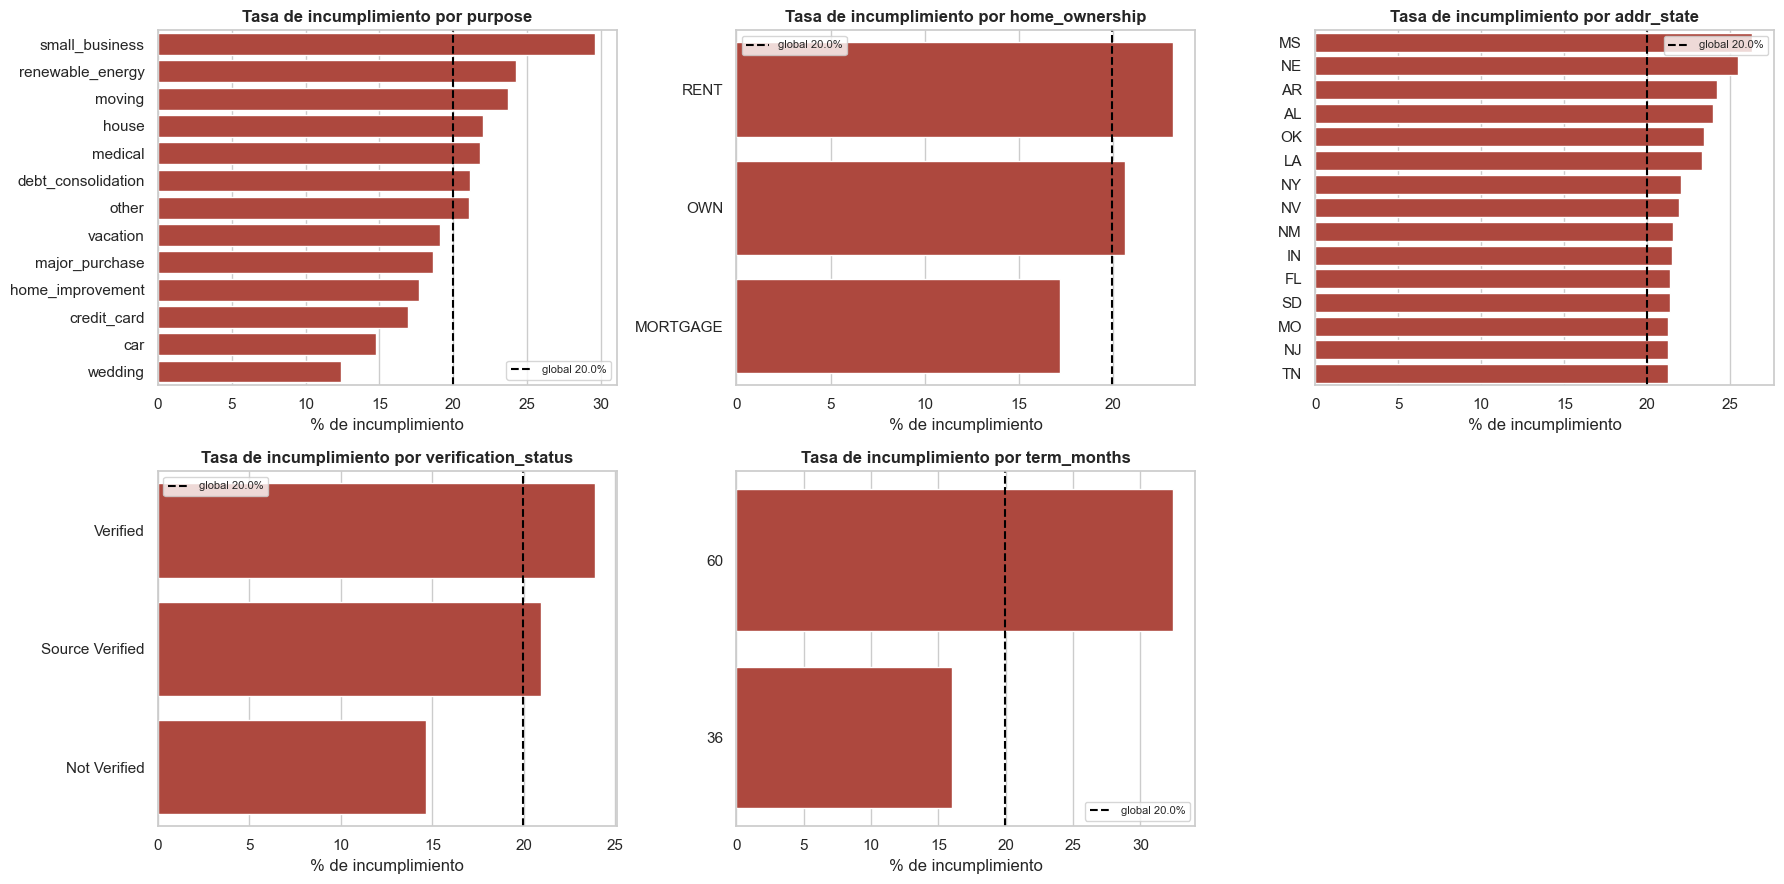

In [28]:
fig, ax = plt.subplots(2, 3, figsize=(18, 9))
tasa_global = m["default"].mean()
for a, c in zip(ax.ravel(), lc.CATEGORICAL + ["term_months"]):
    t = m.groupby(c)["default"].agg(["mean", "size"]).sort_values("mean", ascending=False)
    t = t[t["size"] >= 500].head(15)          # evita categorías diminutas en el gráfico
    sns.barplot(x=t["mean"] * 100, y=t.index.astype(str), ax=a, color="#c0392b")
    a.axvline(tasa_global * 100, color="black", ls="--", label=f"global {tasa_global:.1%}")
    a.set(title=f"Tasa de incumplimiento por {c}", xlabel="% de incumplimiento", ylabel="")
    a.legend(fontsize=8)
for a in ax.ravel()[len(lc.CATEGORICAL) + 1:]:
    a.remove()                                # la cuadrícula tiene un panel más que variables
plt.tight_layout()
plt.show()

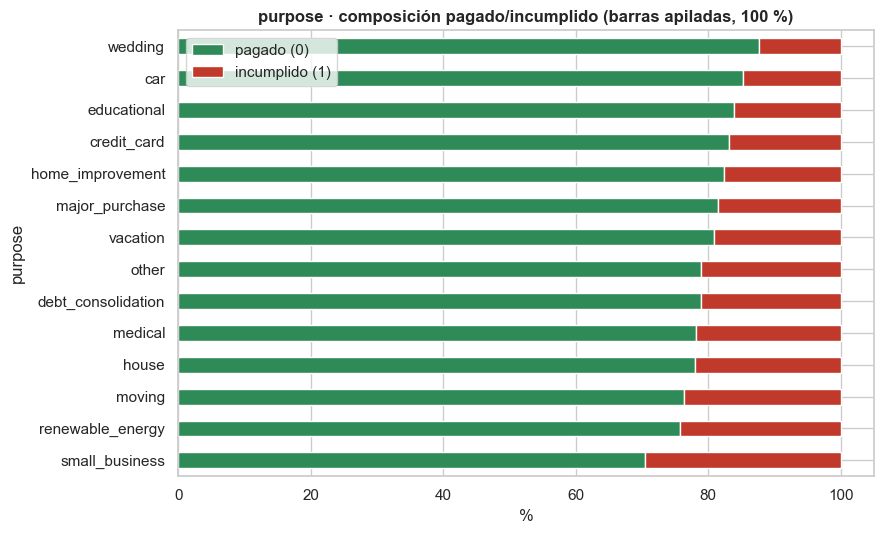

,tasa de default,préstamos
purpose,,
small_business,29.6%,"12,397"
renewable_energy,24.3%,734
moving,23.7%,"7,617"
house,22.0%,"5,803"
credit_card,16.9%,"236,042"
educational,16.1%,267
car,14.8%,"11,684"
wedding,12.4%,"1,859"


In [29]:
cat_top = m.groupby("purpose")["default"].agg(tasa="mean", n="size").sort_values("tasa", ascending=False)
apil = pd.crosstab(m["purpose"], m["default"], normalize="index").loc[cat_top.index] * 100
apil.columns = ["pagado (0)", "incumplido (1)"]
ax = apil.plot.barh(stacked=True, figsize=(9, 5.5), color=["#2e8b57", "#c0392b"])
ax.set(title="purpose · composición pagado/incumplido (barras apiladas, 100 %)", xlabel="%")
plt.tight_layout()
plt.show()
display(pd.concat([cat_top.head(4), cat_top.tail(4)]).rename(columns={"tasa": "tasa de default", "n": "préstamos"})
        .style.format({"tasa de default": "{:.1%}", "préstamos": "{:,.0f}"}))

La tabla de V de Cramér ordena las categóricas por la fuerza de su asociación con el
incumplimiento; el plazo (`term_months`) es la más asociada. Con más de un millón de filas, la
prueba χ² da p < 0.001 en todos los casos, así que **el valor p no distingue entre ellas** y por
eso se usa el V de Cramér como criterio. El gráfico y la
tabla de `purpose` (4 categorías con más y 4 con menos incumplimiento) muestran que las diferencias
entre propósitos existen pero son moderadas. `addr_state` casi no separa clases entre estados
grandes.

## 1.8 Multicolinealidad

### 1.8.1 Entre variables numéricas (Pearson)

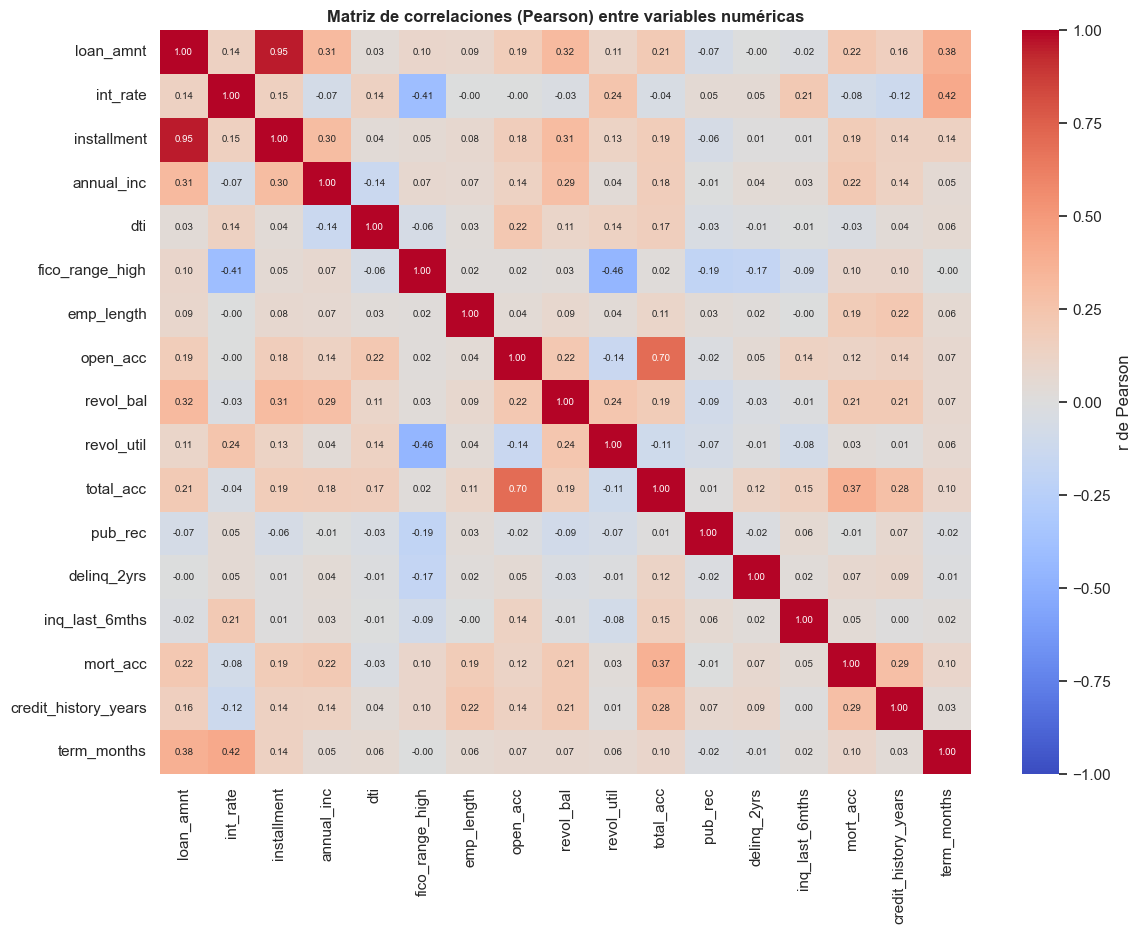

Pares con |r| > 0.7: 2


,,r
variable A,variable B,
loan_amnt,installment,0.953
open_acc,total_acc,0.702


In [30]:
corr = m[lc.NUMERIC].corr(method="pearson")
fig, ax = plt.subplots(figsize=(12, 9.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 7}, cbar_kws={"label": "r de Pearson"})
ax.set_title("Matriz de correlaciones (Pearson) entre variables numéricas")
plt.tight_layout()
plt.show()

iu = np.triu_indices_from(corr, k=1)
pares = pd.DataFrame({"variable A": corr.index[iu[0]], "variable B": corr.columns[iu[1]], "r": corr.values[iu]})
altos = pares[pares["r"].abs() > 0.7].sort_values("r", key=abs, ascending=False)
print(f"Pares con |r| > 0.7: {len(altos)}")
display(altos.set_index(["variable A", "variable B"]))

**Variables candidatas descartadas por redundancia.** Se comprueba también con columnas que
*no* entran al modelo, para justificar por qué se dejaron fuera:

In [31]:
red = pd.DataFrame({
    "fico_range_high vs fico_range_low": [m["fico_range_high"].corr(extra["fico_range_low"])],
    "loan_amnt vs funded_amnt": [m["loan_amnt"].corr(extra["funded_amnt"])],
    "loan_amnt vs installment": [m["loan_amnt"].corr(m["installment"])],
    "int_rate vs grade (código ordinal)": [m["int_rate"].corr(extra["grade"].astype("category").cat.codes.astype(float))],
    "open_acc vs total_acc": [m["open_acc"].corr(m["total_acc"])],
}, index=["r de Pearson"]).T
display(red)

,r de Pearson
fico_range_high vs fico_range_low,1.000
loan_amnt vs funded_amnt,1.000
loan_amnt vs installment,0.953
int_rate vs grade (código ordinal),0.953
open_acc vs total_acc,0.702


* `fico_range_low` es prácticamente idéntica a `fico_range_high` (r ≈ 1): se conserva solo
  `fico_range_high`, porque la otra es redundante.
* `funded_amnt` ≈ `loan_amnt` (r ≈ 1): redundante, no se usa.
* `int_rate` se deriva de la subcategoría de riesgo (`grade`/`sub_grade`) que Lending Club asigna al
  originar el préstamo (r = 0.95 con el código ordinal de `grade`): ambas codifican la misma evaluación
  interna, así que se conserva solo la tasa (`int_rate`) y no `grade`/`sub_grade`.
* `loan_amnt` e `installment` (r > 0.9) e `open_acc`/`total_acc` (r ≈ 0.7) sí se mantienen: aportan
  información distinta (la cuota incorpora además el plazo y la tasa) y, para los modelos de árbol, la
  colinealidad no sesga el resultado, solo reparte la importancia entre las variables (se tiene en
  cuenta al interpretar). Para la regresión logística y la SVM lineal sí puede inflar la varianza de
  los coeficientes; se conservan porque ambos modelos usan regularización L2, que atenúa ese efecto.

### 1.8.2 Entre variables categóricas (V de Cramér)

In [32]:
cv = pd.DataFrame(index=lc.CATEGORICAL, columns=lc.CATEGORICAL, dtype=float)
muestra_cv = m.sample(300000, random_state=lc.SEED)     # V de Cramér entre pares, con 300 000 filas por costo
for a in lc.CATEGORICAL:
    for b in lc.CATEGORICAL:
        cv.loc[a, b] = 1.0 if a == b else lc.cramers_v(muestra_cv[a], muestra_cv[b])
display(cv.round(3))
print("Nota: el V de Cramér entre pares de variables se calcula con 300 000 filas de entrenamiento al azar por "
      "costo computacional; el resto de análisis usa todas las filas de entrenamiento.")

,purpose,home_ownership,addr_state,verification_status
purpose,1.000,0.087,0.021,0.062
home_ownership,0.087,1.000,0.112,0.029
addr_state,0.021,0.112,1.000,0.022
verification_status,0.062,0.029,0.022,1.000


Nota: el V de Cramér entre pares de variables se calcula con 300 000 filas de entrenamiento al azar por costo computacional; el resto de análisis usa todas las filas de entrenamiento.


Las variables categóricas están poco asociadas entre sí (ver la matriz): no hay una redundancia
fuerte que justifique excluir alguna.

## 1.9 Visualizaciones avanzadas

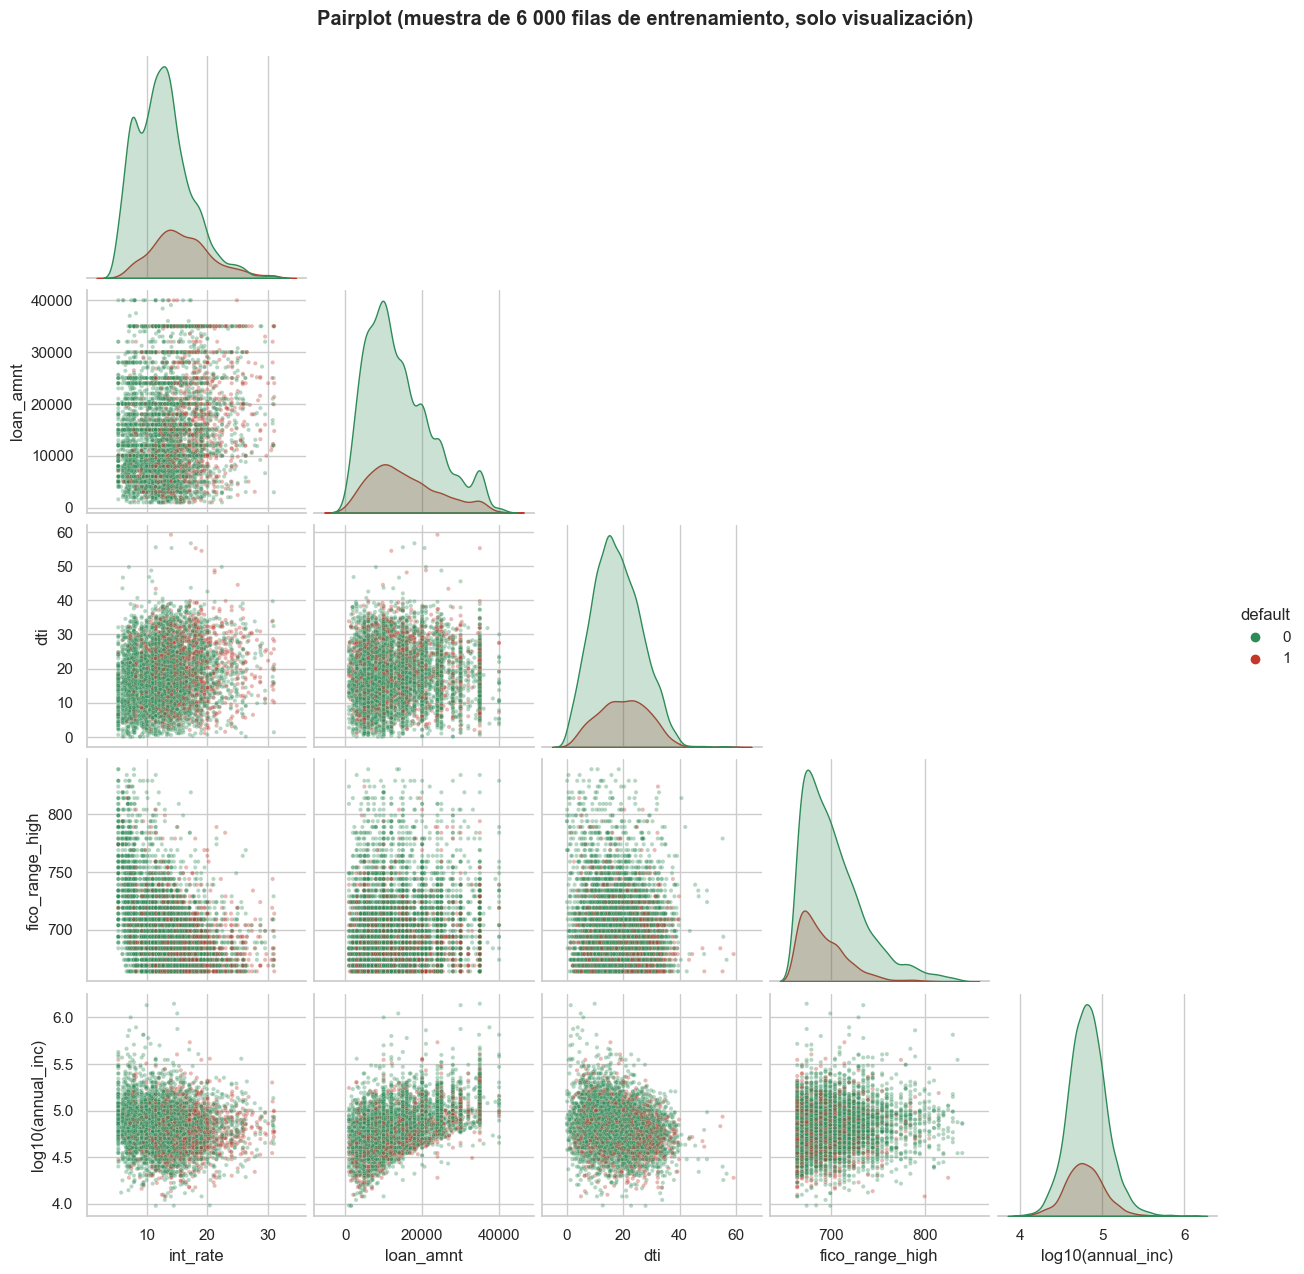

In [33]:
cols_pp = ["int_rate", "loan_amnt", "dti", "fico_range_high", "annual_inc"]
pp = m.sample(6000, random_state=lc.SEED)[cols_pp + ["default"]].copy()
pp["annual_inc"] = np.log10(pp["annual_inc"].clip(lower=1))
pp = pp.rename(columns={"annual_inc": "log10(annual_inc)"})
pp = pp[pp["dti"].between(0, 60)]
g = sns.pairplot(pp, hue="default", corner=True, palette=["#2e8b57", "#c0392b"],
                 plot_kws={"alpha": 0.35, "s": 9}, diag_kind="kde")
g.figure.suptitle("Pairplot (muestra de 6 000 filas de entrenamiento, solo visualización)", y=1.02, fontweight="bold")
plt.show()

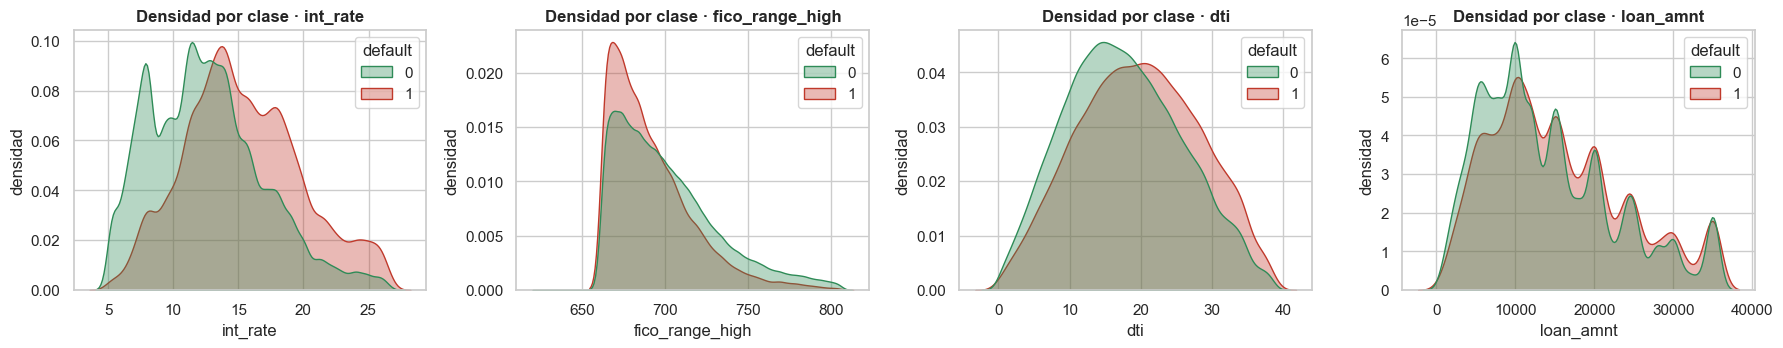

In [34]:
kd = m.sample(150000, random_state=lc.SEED)
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
for a, c in zip(ax, ["int_rate", "fico_range_high", "dti", "loan_amnt"]):
    d = kd[kd[c] <= kd[c].quantile(0.99)]
    sns.kdeplot(data=d, x=c, hue="default", common_norm=False, fill=True, alpha=0.35,
                palette=["#2e8b57", "#c0392b"], ax=a)
    a.set(title=f"Densidad por clase · {c}", ylabel="densidad")
plt.tight_layout()
plt.show()

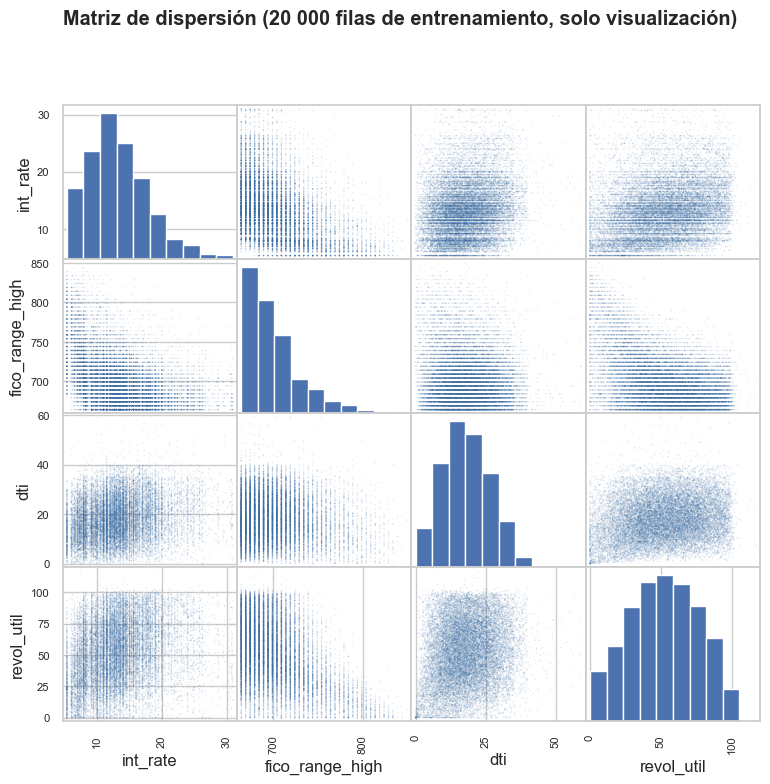

In [35]:
sm = m.sample(20000, random_state=lc.SEED)[["int_rate", "fico_range_high", "dti", "revol_util"]]
sm = sm[(sm["dti"].between(0, 60)) & (sm["revol_util"].between(0, 120))]
pd.plotting.scatter_matrix(sm, figsize=(9, 8), alpha=0.15, diagonal="hist", s=4, color="#3b6ea5")
plt.suptitle("Matriz de dispersión (20 000 filas de entrenamiento, solo visualización)", y=1.0, fontweight="bold")
plt.show()

El *pairplot* y las densidades por clase confirman que las dos clases **se solapan
mucho** en todas las variables: no hay una frontera limpia. Las relaciones entre variables no son
perfectamente lineales (dispersión amplia en la matriz de dispersión), algo que un modelo de
árboles puede capturar sin transformaciones.

## 1.10 Sesgo temporal y censura

Los préstamos se otorgaron entre 2007 y 2018. Los más recientes, sobre todo los de 60 meses,
**aún no han terminado**: si solo se consideran los ya resueltos, los de años recientes están
**sobrerrepresentados en desenlaces rápidos**. Es un problema clásico de **censura**. La primera
tabla usa el archivo completo (solo cuenta filas, sin mirar la variable objetivo de la prueba); la
tasa de incumplimiento se calcula con el entrenamiento.

,otorgados (archivo completo),con desenlace conocido (archivo completo),% resuelto,tasa de default (entrenamiento)
issue_d,,,,
2007,603,251,41.6,17.4%
2008,"2,393","1,562",65.3,15.7%
2009,"5,281","4,716",89.3,12.3%
2010,"12,537","11,536",92.0,13.0%
2011,"21,721","21,721",100.0,15.3%
2012,"53,367","53,367",100.0,16.2%
2013,"134,814","134,804",100.0,15.7%
2014,"235,629","223,102",94.7,18.5%
2015,"421,095","375,545",89.2,20.2%


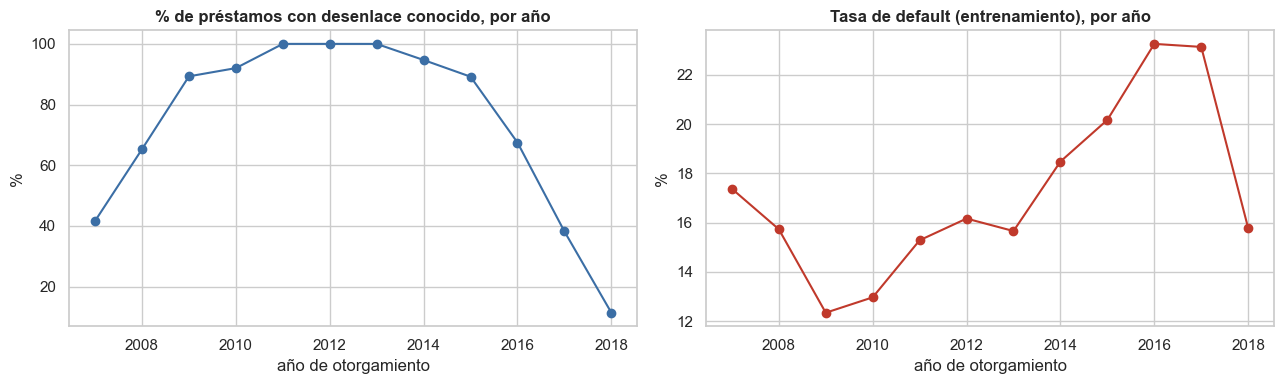

In [36]:
resumen_anio = pd.DataFrame({"otorgados (archivo completo)": anio_todos,
                             "con desenlace conocido (archivo completo)": anio_resueltos})
resumen_anio["% resuelto"] = 100 * resumen_anio["con desenlace conocido (archivo completo)"] / resumen_anio["otorgados (archivo completo)"]
resumen_anio["tasa de default (entrenamiento)"] = m.groupby("issue_year")["default"].mean()
display(resumen_anio.style.format({"otorgados (archivo completo)": "{:,.0f}",
                                   "con desenlace conocido (archivo completo)": "{:,.0f}",
                                   "% resuelto": "{:.1f}", "tasa de default (entrenamiento)": "{:.1%}"}))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
resumen_anio["% resuelto"].plot(marker="o", ax=ax[0], color="#3b6ea5")
ax[0].set(title="% de préstamos con desenlace conocido, por año", ylabel="%", xlabel="año de otorgamiento")
(100 * resumen_anio["tasa de default (entrenamiento)"]).plot(marker="o", ax=ax[1], color="#c0392b")
ax[1].set(title="Tasa de default (entrenamiento), por año", ylabel="%", xlabel="año de otorgamiento")
plt.tight_layout()
plt.show()

Dos consecuencias de este patrón:

* De cierto año en adelante cae el porcentaje de préstamos con desenlace conocido (muchos siguen
  vigentes), y la tasa de incumplimiento de los resueltos deja de ser comparable entre años. El
  modelo aprenderá una mezcla de épocas con **distinta economía y distinto grado de censura**.
* Además de la partición aleatoria estratificada, se incluye una **validación temporal**
  complementaria (entrenar con años anteriores y probar con uno posterior). La validación aleatoria
  tiende a sobrestimar el desempeño cuando los datos tienen estructura temporal, porque el modelo se
  entrena con observaciones posteriores a las que evalúa (Bergmeir y Benítez, 2012).

## 1.11 Resumen ejecutivo del EDA

In [37]:
mas_num = bi_num.index[0], bi_num.index[1]
mas_cat = resumen_cat.index[0], resumen_cat.index[1]
resumen = pd.DataFrame([
    ["Tamaño del archivo", f"{n_filas_archivo:,} filas × {n_cols_archivo} columnas (carga pandas: {T_CARGA_PANDAS:.0f} s)"],
    ["Población y partición", f"{n_train + n_test:,} préstamos con desenlace conocido (Fully Paid / Charged Off): "
                              f"{n_train:,} de entrenamiento y {n_test:,} de prueba (apartada); se excluyen "
                              f"{n_filas_archivo - n_train - n_test:,} vigentes/atrasados/otros"],
    ["Calidad: nulos", f"{N_MAS70} columnas con >70 % de nulos (se descartan); variables del modelo con nulos: "
                       f"{', '.join(nm.index)}"],
    ["Calidad: valores extremos o inválidos", f"{int(sospechosos.iloc[0]):,} fila(s) con dti = −1 (inválido, tratado como faltante); "
                                    f"{int(sospechosos.iloc[1]):,} con dti > 100; {int(sospechosos.iloc[2]):,} con revol_util > 100 % (extremos, se conservan)"],
    ["Desbalance", f"{m['default'].mean():.1%} de incumplimiento (≈ {RAZON_DESBALANCE:.1f}:1)"],
    ["Variables numéricas más asociadas", f"{mas_num[0]} (d = {bi_num.loc[mas_num[0], 'd de Cohen']:+.2f}), "
                                          f"{mas_num[1]} (d = {bi_num.loc[mas_num[1], 'd de Cohen']:+.2f})"],
    ["Variables categóricas más asociadas", f"{mas_cat[0]} (V = {resumen_cat.loc[mas_cat[0], 'V de Cramér']:.2f}), "
                                            f"{mas_cat[1]} (V = {resumen_cat.loc[mas_cat[1], 'V de Cramér']:.2f})"],
    ["Colinealidad", (f"{len(altos)} pares numéricos con |r| > 0.7 (p. ej. {altos.iloc[0, 0]} y {altos.iloc[0, 1]}, "
                      f"r = {altos.iloc[0, 2]:.2f}); " if len(altos) else "ningún par numérico con |r| > 0.7; ")
     + "fico_range_low y funded_amnt redundantes (no usadas)"],
    ["Fuga de datos", f"columnas posteriores al préstamo con AUC individual de hasta {AUD_MAX:.2f}: excluidas del modelo"],
    ["Sesgo temporal", "los préstamos recientes están censurados; se añade validación temporal complementaria"],
], columns=["Hallazgo", "Detalle"]).set_index("Hallazgo")
pd.set_option("display.max_colwidth", 200)
display(resumen)
resumen.to_csv(RESULTS / "eda_resumen.csv")
pd.Series({"t_carga_pandas_s": T_CARGA_PANDAS, "filas": int(n_filas_archivo), "columnas": int(n_cols_archivo),
           "filas_modelo": int(n_train + n_test), "filas_train": int(n_train), "filas_test": int(n_test),
           "tasa_default_train": float(m["default"].mean())}).to_json(RESULTS / "eda_metricas.json")

,Detalle
Hallazgo,
Tamaño del archivo,"2,260,701 filas × 151 columnas (carga pandas: 122 s)"
Población y partición,"1,345,310 préstamos con desenlace conocido (Fully Paid / Charged Off): 1,076,248 de entrenamiento y 269,062 de prueba (apartada); se excluyen 915,391 vigentes/atrasados/otros"
Calidad: nulos,"42 columnas con >70 % de nulos (se descartan); variables del modelo con nulos: emp_length, mort_acc, revol_util, dti, inq_last_6mths"
Calidad: valores extremos o inválidos,"1 fila(s) con dti = −1 (inválido, tratado como faltante); 428 con dti > 100; 3,781 con revol_util > 100 % (extremos, se conservan)"
Desbalance,20.0% de incumplimiento (≈ 4.0:1)
Variables numéricas más asociadas,"int_rate (d = +0.67), fico_range_high (d = -0.33)"
Variables categóricas más asociadas,"term_months (V = 0.18), verification_status (V = 0.09)"
Colinealidad,"2 pares numéricos con |r| > 0.7 (p. ej. loan_amnt y installment, r = 0.95); fico_range_low y funded_amnt redundantes (no usadas)"
Fuga de datos,columnas posteriores al préstamo con AUC individual de hasta 0.94: excluidas del modelo


### Decisiones que guían el preprocesamiento

1. **Población y etiqueta:** solo `Fully Paid` / `Charged Off` (desenlace conocido).
2. **Partición:** 80/20 estratificada, hecha **antes** del EDA; el conjunto de prueba no se tocó.
3. **Variables:** las disponibles al originar el préstamo (17 numéricas + 4 categóricas). Se
   descartan las posteriores al préstamo (fuga), `fico_range_low`, `funded_amnt`, `grade` y
   `sub_grade` (redundantes).
4. **Nulos:** centinela −1 en numéricas (sin parámetros aprendidos ⇒ sin fuga); `Desconocido` en categóricas.
5. **Categóricas:** *One-Hot* agrupando en "infrecuente" las de < 1 % del entrenamiento.
6. **Valores atípicos:** se conservan (en su mayoría son valores extremos posibles y los árboles son
   robustos); los pocos valores imposibles (`dti` < 0) quedan cubiertos por el centinela.
7. **Escalado:** no lo necesitan los modelos de árbol; regresión logística y SVM lineal sí se
   escalan (`StandardScaler`, ajustado solo con el entrenamiento).
8. **Desbalance:** estratificar, métricas robustas (AUC, AUC-PR, sensibilidad, F1) y umbral elegido sin
   el conjunto de prueba. Sin remuestreo.
9. **Validación:** partición aleatoria estratificada 80/20 más validación temporal complementaria.

# 2 · Preprocesamiento y modelado con scikit-learn (seis modelos)

**Objetivo del capítulo.** Se prepara la tabla de modelado, se lee la **partición común** 80/20 (la misma
que usará PySpark), se entrenan **seis modelos** con `GridSearchCV` **sin `Pipeline`**
(`scoring="roc_auc"`, `n_jobs=-1`, **3 pliegues**), se evalúan en el conjunto de
prueba y se guardan las **puntuaciones continuas** del conjunto de prueba para la prueba de DeLong del capítulo 5.

| Decisión | Motivo |
|---|---|
| Partición común (80/20, estratificada, semilla 42) **leída de un archivo** | Ambos entornos deben usar exactamente los mismos préstamos: la prueba de DeLong compara AUC calculados sobre las mismas observaciones |
| 3 pliegues **fijos y estratificados**, guardados en el mismo archivo (`fold`) | scikit-learn y el `CrossValidator` de Spark validan sobre **los mismos** pliegues (`foldCol`) |
| `GridSearchCV(scoring="roc_auc")` | El `scoring` por defecto es la exactitud, engañosa con un 80 % de clase mayoritaria |
| Imputación sin parámetros aprendidos (centinela −1); codificación y escalado sí los aprenden | El preprocesamiento se ajusta **antes** de la validación cruzada; ver la comprobación de la sección 2.6 |
| Umbral elegido con predicciones **fuera de pliegue** del entrenamiento | Elegirlo con el conjunto de prueba lo contaminaría |
| El conjunto de prueba no interviene en ninguna decisión de modelado | Elegir variables, hiperparámetros o umbral mirando el conjunto de prueba produce estimaciones optimistas |

In [1]:
import gc
import json
import os
import platform
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, average_precision_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_models as lm  # noqa: E402
from src import lc_utils as lc  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, message=".*n_jobs.*")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS, DATA_DIR = Path("../resultados"), Path("../data")
RESULTS.mkdir(exist_ok=True)
(DATA_DIR / "models").mkdir(parents=True, exist_ok=True)
N_CPU = os.cpu_count()
TIMES = {}          # tiempos (segundos) -> se guardan para la comparación con PySpark
print(f"Python {platform.python_version()} · scikit-learn {sklearn.__version__} · pandas {pd.__version__} "
      f"· {N_CPU} hilos lógicos · RAM {psutil.virtual_memory().total / 1e9:.1f} GB")

Python 3.10.21 · scikit-learn 1.3.0 · pandas 2.1.0 · 12 hilos lógicos · RAM 16.9 GB


## 2.1 Carga y tabla de modelado

Se lee el CSV **completo** (todas las filas; solo se eligen las 24 columnas necesarias para no
gastar memoria) y se construye la tabla con solo los préstamos de desenlace conocido.

In [2]:
t0 = time.time()
raw = lc.load_raw(usecols=lc.RAW_COLUMNS)
TIMES["carga_csv"] = time.time() - t0
print(f"Carga del CSV: {raw.shape[0]:,} filas × {raw.shape[1]} columnas en {TIMES['carga_csv']:.1f} s")

t0 = time.time()
m = lc.build_model_frame(raw)
TIMES["features"] = time.time() - t0
del raw
gc.collect()
print(f"Tabla de modelado: {m.shape[0]:,} filas · features en {TIMES['features']:.1f} s")
print(f"Tasa de incumplimiento: {m['default'].mean():.4%}")

Carga del CSV: 2,260,701 filas × 24 columnas en 26.9 s


Tabla de modelado: 1,345,310 filas · features en 10.8 s
Tasa de incumplimiento: 19.9626%


## 2.2 Partición común y pliegues fijos

La partición **ya se hizo en el capítulo de EDA, antes de explorar nada**, y se guardó en
`data/split_ids.parquet` con las columnas `id` y `split` (`train` / `test`), más `fold` (pliegue
0, 1 o 2 de las filas de entrenamiento, estratificado por `default`). Aquí se **lee** y, como
comprobación de reproducibilidad, se vuelve a calcular y se verifica que sea idéntica. El capítulo de
PySpark lee **ese mismo archivo**.

In [3]:
split = pd.read_parquet(DATA_DIR / "split_ids.parquet")
recalculada = lc.make_split(m)
assert split["id"].equals(recalculada["id"]) and (split["split"] == recalculada["split"]).all() \
    and (split["fold"] == recalculada["fold"]).all(), "La partición guardada no coincide con la recalculada"
print("Partición guardada = partición recalculada: OK (misma semilla, mismos datos)")
es_test = (split["split"] == "test").to_numpy()
idx_train, idx_test = np.flatnonzero(~es_test), np.flatnonzero(es_test)
train, test = m.iloc[idx_train].reset_index(drop=True), m.iloc[idx_test].reset_index(drop=True)
y_train, y_test = train["default"].to_numpy(), test["default"].to_numpy()
fold = split.loc[~es_test, "fold"].to_numpy()
FOLDS = [(np.flatnonzero(fold != k), np.flatnonzero(fold == k)) for k in range(3)]     # (entrenar, validar)

resumen_split = pd.DataFrame({
    "filas": [len(train), len(test)],
    "% del total": [100 * len(train) / len(m), 100 * len(test) / len(m)],
    "tasa de default": [train["default"].mean(), test["default"].mean()]}, index=["entrenamiento", "prueba"])
display(resumen_split)
display(pd.DataFrame({"filas de validación": [len(v) for _, v in FOLDS],
                      "tasa de default": [y_train[v].mean() for _, v in FOLDS]},
                     index=[f"pliegue {k}" for k in range(3)]))

Partición guardada = partición recalculada: OK (misma semilla, mismos datos)


,filas,% del total,tasa de default
entrenamiento,1076248,80.0000,0.1996
prueba,269062,20.0000,0.1996


,filas de validación,tasa de default
pliegue 0,358750,0.1996
pliegue 1,358749,0.1996
pliegue 2,358749,0.1996


## 2.3 Preprocesamiento

* **Numéricas (17):** los nulos se rellenan con el centinela **−1** (sin parámetros aprendidos).
* **Categóricas (4):** *One-Hot*; las categorías con menos del 1 % **del entrenamiento** se
  agrupan como "infrecuente" (las categorías nuevas del conjunto de prueba también).
* **Escalado (`StandardScaler`):** solo para la **regresión logística** y la **SVM lineal**, que
  son sensibles a la escala. Los árboles, el *gradient boosting* y Naive Bayes trabajan con las
  variables sin escalar. El escalador se **ajusta solo con el entrenamiento**.

In [4]:
t0 = time.time()
prep = lc.make_preprocessor()
X_train = prep.fit_transform(train[lc.FEATURES]).astype(np.float32)
X_test = prep.transform(test[lc.FEATURES]).astype(np.float32)
scaler = StandardScaler().fit(X_train)
Xs_train, Xs_test = scaler.transform(X_train).astype(np.float32), scaler.transform(X_test).astype(np.float32)
TIMES["preprocesamiento"] = time.time() - t0
feature_names = prep.get_feature_names_out()
print(f"X_train: {X_train.shape} · X_test: {X_test.shape} · dtype {X_train.dtype} "
      f"· {X_train.nbytes / 1e9:.2f} GB · preprocesamiento en {TIMES['preprocesamiento']:.1f} s")

enc = prep.named_transformers_["cat"]
infrecuentes = {c: sorted(i.tolist()) if i is not None else []
                for c, i in zip(lc.CATEGORICAL, enc.infrequent_categories_)}
(RESULTS / "categorias_infrecuentes.json").write_text(json.dumps(infrecuentes, ensure_ascii=False, indent=1), encoding="utf-8")
(RESULTS / "paridad_features.json").write_text(
    json.dumps({"medias": {c: float(m[c].mean()) for c in lc.NUMERIC}}, indent=1), encoding="utf-8")

X_train: (1076248, 62) · X_test: (269062, 62) · dtype float32 · 0.27 GB · preprocesamiento en 5.4 s


629

## 2.4 Los seis modelos y sus espacios de búsqueda

Son **los mismos** que en PySpark (Tabla 2.1). Equivalencias que conviene tener presentes (se
retoman en la discusión final):

* **Regularización L2** en ambos entornos. En la regresión logística y la SVM lineal, PySpark usa
  `regParam ∈ {1e-6, 1e-5, 1e-4}` y scikit-learn `C = 1 / (regParam × n)` con `n` = filas de
  entrenamiento. La relación es **aproximada**: `C` pondera la *suma* de las pérdidas y `regParam`
  su *promedio*.
* **`LinearSVC(loss="hinge")`**: el valor por defecto de scikit-learn es *squared hinge*; el de PySpark
  minimiza *hinge*, así que se fija `loss="hinge"`.
* **Árboles:** scikit-learn evalúa cortes **exactos**; PySpark discretiza cada variable continua en
  `maxBins = 32` intervalos.
* **Naive Bayes gaussiano** en ambos, sin búsqueda de hiperparámetros.

**Decisión sobre el gradient boosting.** `GradientBoostingClassifier` es secuencial (no usa varios
hilos dentro de un ajuste) y con 1.08 millones de filas es el modelo más lento de este capítulo. Si su
costo resultara prohibitivo, la alternativa natural es `HistGradientBoostingClassifier`. Se fijó de
antemano un presupuesto de cómputo de 3 horas para la malla completa (12 ajustes) más el reajuste, y se
decide con una **medición** corta (10 árboles, profundidad 5, 100 000 filas), extrapolada al tamaño real
de un ajuste (100 árboles con las filas de dos pliegues).

In [5]:
N_TRAIN = len(y_train)
_gb = lm.sk_specs(N_TRAIN)["GB"][0]
_gb.set_params(n_estimators=10, max_depth=5)
_k = 100_000
t0 = time.time()
_gb.fit(X_train[:_k], y_train[:_k])
_t10 = time.time() - t0
_fila_pliegue = 2 * N_TRAIN // 3
_por_ajuste = _t10 / 10 * 100 * _fila_pliegue / _k          # 100 árboles con las filas de un pliegue de entrenamiento
_estimado = (12 / N_CPU * 0.6 + 1) * _por_ajuste * 1.5     # 12 ajustes en paralelo (aprox.) + reajuste con todo el train
GB_HIST = bool(_estimado > 3 * 3600)
print(f"10 árboles (prof. 5) con {_k:,} filas: {_t10:.1f} s → un ajuste de 100 árboles con {_fila_pliegue:,} filas ≈ "
      f"{_por_ajuste / 60:.1f} min · costo estimado de malla + reajuste ≈ {_estimado / 60:.0f} min")
print("Decisión:", "HistGradientBoostingClassifier (costo prohibitivo)" if GB_HIST else "GradientBoostingClassifier (costo aceptable)")
del _gb

10 árboles (prof. 5) con 100,000 filas: 10.3 s → un ajuste de 100 árboles con 717,498 filas ≈ 12.3 min · costo estimado de malla + reajuste ≈ 29 min
Decisión: GradientBoostingClassifier (costo aceptable)


In [6]:
specs = lm.sk_specs(N_TRAIN, gb_hist=GB_HIST)
tabla = pd.DataFrame([{"modelo": lm.NOMBRES[k], "estimador": type(e).__name__,
                       "espacio de búsqueda": json.dumps({a: [round(v, 5) if isinstance(v, float) else v for v in vals]
                                                          for a, vals in g.items()}) or "—",
                       "combinaciones": int(np.prod([len(v) for v in g.values()])) if g else 1,
                       "datos": "escalados" if lm.USA_ESCALADO.get(k) else "sin escalar"}
                      for k, (e, g, _) in specs.items()])
display(tabla)
print(f"n de entrenamiento = {N_TRAIN:,} → C = " + ", ".join(f"{lm.c_from_reg(r, N_TRAIN):.5f}" for r in lm.REG_PARAMS)
      + " para regParam = " + ", ".join(f"{r:g}" for r in lm.REG_PARAMS))
print(f"Total de ajustes con 3 pliegues: {sum((int(np.prod([len(v) for v in g.values()])) if g else 1) * 3 for _, g, _ in specs.values())} "
      "+ un reajuste final por modelo")

,modelo,estimador,espacio de búsqueda,combinaciones,datos
0,Regresión logística,LogisticRegression,"{""C"": [0.92915, 0.09292, 0.00929]}",3,escalados
1,Árbol de decisión,DecisionTreeClassifier,"{""max_depth"": [5, 10, 15]}",3,sin escalar
2,Bosque aleatorio,RandomForestClassifier,"{""n_estimators"": [10, 50, 100], ""max_depth"": [...",9,sin escalar
3,Gradient boosting,GradientBoostingClassifier,"{""n_estimators"": [50, 100], ""max_depth"": [3, 5]}",4,sin escalar
4,SVM lineal,LinearSVC,"{""C"": [0.92915, 0.09292, 0.00929]}",3,escalados
5,Naive Bayes,GaussianNB,{},1,sin escalar


n de entrenamiento = 1,076,248 → C = 0.92915, 0.09292, 0.00929 para regParam = 1e-06, 1e-05, 0.0001
Total de ajustes con 3 pliegues: 69 + un reajuste final por modelo


## 2.5 Entrenamiento con validación cruzada (los seis modelos)

Para cada modelo: `GridSearchCV` **sin `Pipeline`**, con los 3 pliegues fijos, `scoring="roc_auc"`,
`n_jobs=-1` (los ajustes de la malla se reparten entre los hilos) y `refit=True` (el mejor modelo se
reajusta con todo el entrenamiento). **El tiempo de entrenamiento incluye la validación cruzada y el
reajuste.** Después:

1. se mide el tiempo de **predicción** sobre el conjunto de prueba y se guarda la **puntuación continua**
   (`predict_proba[:, 1]`; en `LinearSVC`, `decision_function`);
2. se calculan puntuaciones **fuera de pliegue** del entrenamiento (`cross_val_predict` con los mismos
   pliegues) para elegir el umbral sin usar el conjunto de prueba.


In [7]:
def clone_best(est):
    from sklearn.base import clone
    return clone(est)


def entrenar(clave: str) -> dict:
    est, grid, tipo = specs[clave]
    esc = lm.USA_ESCALADO.get(clave, False)
    Xtr, Xte = (Xs_train, Xs_test) if esc else (X_train, X_test)
    r = {"clave": clave, "modelo": lm.NOMBRES[clave], "escalado": esc, "tipo_puntuacion": tipo}
    t0 = time.time()
    if grid:
        gs = GridSearchCV(est, grid, cv=FOLDS, scoring="roc_auc", n_jobs=-1, refit=True, return_train_score=True)
        gs.fit(Xtr, y_train)
        best, r["mejores_hiperparametros"] = gs.best_estimator_, {k: float(v) if isinstance(v, (float, np.floating)) else int(v)
                                                                   for k, v in gs.best_params_.items()}
        r["auc_cv"], r["auc_cv_sd"] = float(gs.best_score_), float(gs.cv_results_["std_test_score"][gs.best_index_])
        cvres = pd.DataFrame(gs.cv_results_)
        cvres = cvres[[c for c in cvres.columns if c.startswith("param_") or c in
                       ("mean_test_score", "std_test_score", "mean_train_score", "mean_fit_time", "rank_test_score")]]
        cvres.to_csv(RESULTS / f"sk_cv_{clave}.csv", index=False)
        r["auc_train_cv_mean"] = float(gs.cv_results_["mean_train_score"][gs.best_index_])
    else:                                                     # Naive Bayes: sin búsqueda de hiperparámetros
        aucs = cross_val_score(est, Xtr, y_train, cv=FOLDS, scoring="roc_auc")
        best = est.fit(Xtr, y_train)
        r["mejores_hiperparametros"], r["auc_cv"], r["auc_cv_sd"] = {}, float(aucs.mean()), float(aucs.std(ddof=1))
    r["t_entrenamiento_con_cv_s"] = time.time() - t0

    t0 = time.time()
    s_test = lm.score_sklearn(best, Xte, tipo)
    r["t_prediccion_s"] = time.time() - t0

    t0 = time.time()
    oof = cross_val_predict(clone_best(best), Xtr, y_train, cv=FOLDS, n_jobs=3,
                            method="predict_proba" if tipo == "proba" else "decision_function")
    oof = oof[:, 1] if tipo == "proba" else oof
    r["t_oof_umbral_s"] = time.time() - t0
    r["umbral_f1"] = lc.best_f1_threshold(y_train, oof)
    r["umbral_defecto"] = 0.5 if tipo == "proba" else 0.0
    r["auc_oof"] = float(roc_auc_score(y_train, oof))
    r["auc_test"] = float(roc_auc_score(y_test, s_test))
    r["auc_train_reajustado"] = float(roc_auc_score(y_train, lm.score_sklearn(best, Xtr, tipo)))
    return r, best, s_test, oof

In [8]:
RES, BEST, SCORES_TEST, SCORES_OOF = {}, {}, {}, {}
for clave in lm.CLAVES:
    t_ini = time.time()
    RES[clave], BEST[clave], SCORES_TEST[clave], SCORES_OOF[clave] = entrenar(clave)
    r = RES[clave]
    print(f"{r['modelo']:<22} mejores {r['mejores_hiperparametros']} · AUC CV {r['auc_cv']:.4f} ± {r['auc_cv_sd']:.4f} "
          f"· entrenamiento+CV {r['t_entrenamiento_con_cv_s']:.0f} s · predicción {r['t_prediccion_s']:.1f} s "
          f"· umbral OOF {r['umbral_f1']:.3f} · (total {time.time() - t_ini:.0f} s)", flush=True)
    gc.collect()

Regresión logística    mejores {'C': 0.9291538753149833} · AUC CV 0.7096 ± 0.0002 · entrenamiento+CV 15 s · predicción 0.1 s · umbral OOF 0.204 · (total 22 s)


Árbol de decisión      mejores {'max_depth': 10} · AUC CV 0.7013 ± 0.0002 · entrenamiento+CV 59 s · predicción 0.1 s · umbral OOF 0.204 · (total 79 s)


Bosque aleatorio       mejores {'max_depth': 15, 'n_estimators': 100} · AUC CV 0.7158 ± 0.0001 · entrenamiento+CV 837 s · predicción 5.7 s · umbral OOF 0.219 · (total 1096 s)


Gradient boosting      mejores {'max_depth': 5, 'n_estimators': 100} · AUC CV 0.7193 ± 0.0003 · entrenamiento+CV 3267 s · predicción 1.3 s · umbral OOF 0.224 · (total 4043 s)


SVM lineal             mejores {'C': 0.009291538753149831} · AUC CV 0.5015 ± 0.0157 · entrenamiento+CV 624 s · predicción 0.2 s · umbral OOF -1.000 · (total 683 s)


Naive Bayes            mejores {} · AUC CV 0.6887 ± 0.0008 · entrenamiento+CV 5 s · predicción 0.5 s · umbral OOF 0.214 · (total 10 s)


La estimación preliminar de 2.4 (≈ 29 min) resultó inferior al costo real de la malla completa más el
reajuste del *gradient boosting* (≈ 54 min, 3267 s): la extrapolación lineal desde 10 árboles subestima el
costo de una malla con más combinaciones y árboles más profundos.

### Hallazgo: la SVM lineal converge a una solución degenerada a esta escala

El AUC de la SVM lineal resultó ≈ 0.50 (equivalente al azar) con los tres valores de `C` de la malla
(tabla siguiente). Antes de reportarlo, se investigó si era un error
del código o un problema real del *solver*.

In [ ]:
display(pd.read_csv(RESULTS / "sk_cv_SVM.csv"))

mean_fit_time,param_C,mean_test_score,std_test_score,rank_test_score,mean_train_score
532.306331,0.929154,0.492636,0.020450,2,0.491007
419.422331,0.092915,0.488213,0.020191,3,0.487672
65.196156,0.009292,0.501535,0.015664,1,0.501974


**Diagnóstico.** Se ajusta `LinearSVC(loss="hinge")` (el `C` que ganó la malla, que es el menor: 0.0093) sobre un subconjunto de
700 000 filas (el tamaño aproximado de dos pliegues) y se inspeccionan los coeficientes, el intercepto y
el número de iteraciones que usó el *solver*.

In [ ]:
import warnings as _warnings

from sklearn.svm import LinearSVC as _LinearSVC

_sub = 700_000
with _warnings.catch_warnings(record=True) as _w:
    _warnings.simplefilter("always")
    _m_diag = _LinearSVC(loss="hinge", C=specs["SVM"][1]["C"][-1], max_iter=1000, random_state=lc.SEED).fit(
        Xs_train[:_sub], y_train[:_sub])
_s_diag = _m_diag.decision_function(Xs_test)
_w_relevantes = [str(x.message)[:150] for x in _w if x.category is not FutureWarning]     # se ignora el aviso de `dual` (ajeno a la convergencia)
print(f"Ajuste con {_sub:,} filas · C = {specs['SVM'][1]['C'][-1]:.4f} · iteraciones usadas: {_m_diag.n_iter_} "
      f"(máximo permitido: 1000) · advertencias de convergencia: {_w_relevantes or 'ninguna'}")
print(f"Desviación estándar de la función de decisión en el test: {_s_diag.std():.3e} (prácticamente constante)")
print(f"Coeficientes: media |coef| = {abs(_m_diag.coef_).mean():.3e} · máximo |coef| = {abs(_m_diag.coef_).max():.3e} "
      f"· intercepto = {_m_diag.intercept_[0]:.4f}")
print(f"AUC con este ajuste de diagnóstico: {roc_auc_score(y_test, _s_diag):.4f}")

Ajuste con 700,000 filas · C = 0.0093 · iteraciones usadas: 93 (máximo permitido: 1000) · advertencias de convergencia: ninguna
Desviación estándar de la función de decisión en el test: 1.822e-13 (prácticamente constante)
Coeficientes: media |coef| = 3.795e-09 · máximo |coef| = 2.170e-08 · intercepto = -1.0000
AUC con este ajuste de diagnóstico: 0.5191


El *solver* **converge** (93 iteraciones de un máximo de 1000, sin ninguna advertencia de no
convergencia), pero a una solución **degenerada**: los coeficientes son del orden de 10⁻⁸-10⁻⁹ y el
intercepto queda en −1.0, es decir, el modelo aprende a "predecir siempre la clase negativa con el margen
máximo" en vez de separar las clases. Las puntuaciones resultantes son prácticamente constantes
(desviación estándar de 1.8×10⁻¹³ en la función de decisión), lo que explica que el AUC (0.52 en este
subconjunto de diagnóstico, 0.4956 con el ajuste completo) equivalga al azar y no a un modelo peor que el
azar.

Es compatible con la **solución degenerada** de la SVM con pérdida *hinge* descrita por Rifkin, Pontil y
Verri (1999): cuando las clases se solapan mucho y la clase mayoritaria cuadruplica a la minoritaria, el
punto *w* = 0, *b* = −1 puede ser el óptimo del problema regularizado, y `liblinear` refuerza el efecto
porque también regulariza el intercepto. Es la explicación más probable a partir de la evidencia
disponible (un solo ajuste de diagnóstico, con precisión `float32` y `max_iter = 1000`); no se repitió con
otra precisión numérica ni con más iteraciones, así que no se descarta que esos factores también
influyan, aunque el *solver* ya convergió sin advertencias en muchas menos iteraciones que el límite.

`loss="hinge"` no puede cambiarse por `squared_hinge` (que sí admite el *solver* primal, mejor
comportado a gran escala), porque debe coincidir con la pérdida que minimiza el `LinearSVC` de PySpark
para que la comparación entre motores sea válida. El resultado (AUC ≈ 0.50) se reporta tal cual. La
discusión final compara este resultado con el de PySpark, cuyo optimizador es distinto.

## 2.6 Resumen de la validación cruzada

`AUC de entrenamiento` es el AUC del modelo reajustado evaluada **sobre el propio entrenamiento**
(una medida de sobreajuste, no de calidad): la brecha con el AUC de validación indica cuánto
memoriza el modelo.

,mejores hiperparámetros,AUC CV,± sd (pliegues),AUC entrenamiento,brecha (train − CV),tiempo entrenamiento + CV (s),tiempo predicción test (s)
modelo,,,,,,,
Regresión logística,"{""C"": 0.9291538753149833}",0.7096,0.0002,0.7098,0.0002,14.7217,0.0664
Árbol de decisión,"{""max_depth"": 10}",0.7013,0.0002,0.7151,0.0138,59.3327,0.0527
Bosque aleatorio,"{""max_depth"": 15, ""n_estimators"": 100}",0.7158,0.0001,0.7931,0.0773,837.4360,5.7464
Gradient boosting,"{""max_depth"": 5, ""n_estimators"": 100}",0.7193,0.0003,0.7239,0.0047,"3,266.7211",1.2660
SVM lineal,"{""C"": 0.009291538753149831}",0.5015,0.0157,0.4951,-0.0065,623.7369,0.1969
Naive Bayes,{},0.6887,0.0008,0.6889,0.0002,4.8391,0.5221


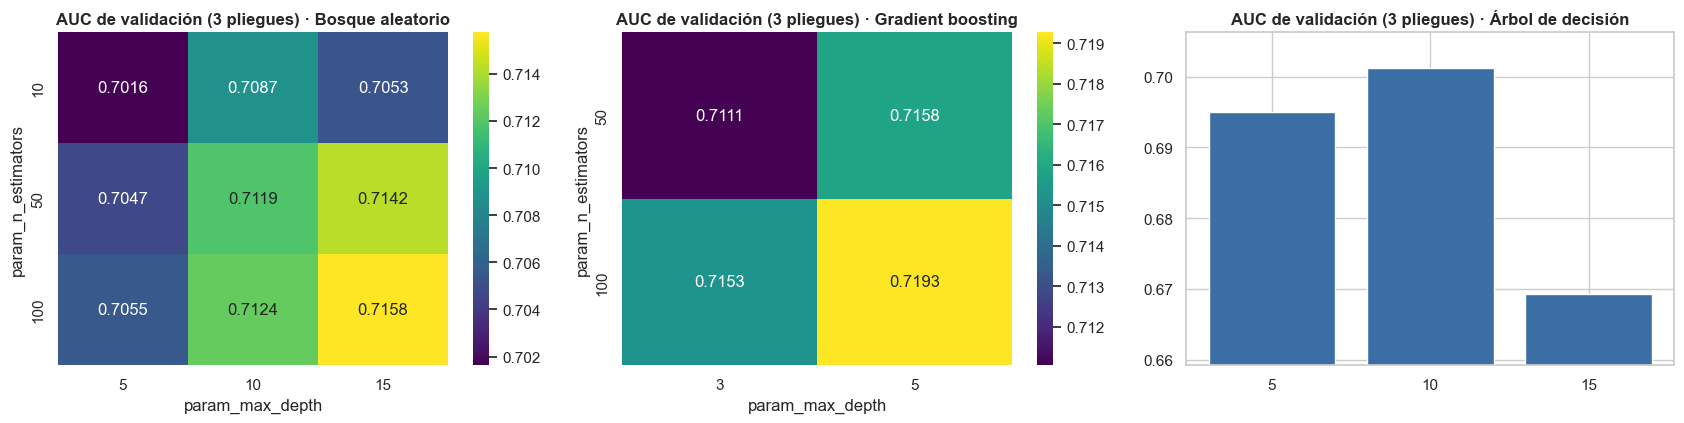

In [9]:
resumen = pd.DataFrame([{
    "modelo": r["modelo"], "mejores hiperparámetros": json.dumps(r["mejores_hiperparametros"]),
    "AUC CV": r["auc_cv"], "± sd (pliegues)": r["auc_cv_sd"], "AUC entrenamiento": r["auc_train_reajustado"],
    "brecha (train − CV)": r["auc_train_reajustado"] - r["auc_cv"],
    "tiempo entrenamiento + CV (s)": r["t_entrenamiento_con_cv_s"], "tiempo predicción test (s)": r["t_prediccion_s"]}
    for r in RES.values()]).set_index("modelo")
display(resumen)
resumen.to_csv(RESULTS / "sk_resumen_modelos.csv")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
for a, clave in zip(ax, ["RF", "GB", "DT"]):
    cv_ = pd.read_csv(RESULTS / f"sk_cv_{clave}.csv")
    pcols = [c for c in cv_.columns if c.startswith("param_")]
    if len(pcols) == 2:
        pv = cv_.pivot(index=pcols[1], columns=pcols[0], values="mean_test_score")
        sns.heatmap(pv, annot=True, fmt=".4f", cmap="viridis", ax=a)
    else:
        a.bar(cv_[pcols[0]].astype(str), cv_["mean_test_score"], color="#3b6ea5")
        a.set_ylim(cv_["mean_test_score"].min() - 0.01, cv_["mean_test_score"].max() + 0.005)
    a.set_title(f"AUC de validación (3 pliegues) · {lm.NOMBRES[clave]}")
plt.tight_layout()
plt.show()

### Comprobación: ¿filtra información el escalado fuera de la validación cruzada?

Para que ambos entornos partan de matrices idénticas, los transformadores (codificación *one-hot* con
agrupación de categorías infrecuentes y estandarización) se ajustan una sola vez con todo el
entrenamiento, antes de la validación cruzada. Para la regresión logística y la SVM lineal esto hace
que la media y la desviación de cada pliegue de validación entren en el escalado: una fuga leve, porque
son estadísticos sin la etiqueta. Para acotarla, se repite la búsqueda de la regresión logística con
`Pipeline`, que reajusta el escalador dentro de cada pliegue, y se compara.

In [10]:
t0 = time.time()
gs_pipe = GridSearchCV(make_pipeline(StandardScaler(), LogisticRegression(max_iter=100, random_state=lc.SEED)),
                       {"logisticregression__C": specs["LR"][1]["C"]}, cv=FOLDS, scoring="roc_auc", n_jobs=-1).fit(X_train, y_train)
comp = pd.DataFrame({"AUC CV (mejor C)": [RES["LR"]["auc_cv"], gs_pipe.best_score_],
                     "mejor C": [RES["LR"]["mejores_hiperparametros"]["C"], gs_pipe.best_params_["logisticregression__C"]]},
                    index=["sin Pipeline (escalador con todo el entrenamiento)", "con Pipeline (escalador dentro de cada pliegue)"])
display(comp)
DIF_ESCALADO = float(RES["LR"]["auc_cv"] - gs_pipe.best_score_)
print(f"Diferencia de AUC CV = {DIF_ESCALADO:+.6f} (calculada en {time.time() - t0:.0f} s)")

,AUC CV (mejor C),mejor C
sin Pipeline (escalador con todo el entrenamiento),0.7096,0.9292
con Pipeline (escalador dentro de cada pliegue),0.7096,0.9292


Diferencia de AUC CV = -0.000000 (calculada en 13 s)


La diferencia de AUC es inferior a 10⁻⁶ y el hiperparámetro elegido es idéntico: con más de 700 000
filas por ajuste, la media y la desviación de un pliegue apenas cambian, y el escalado no filtra
información relevante sobre la etiqueta.

## 2.7 Evaluación en el conjunto de prueba

Se reportan **exactitud (*accuracy*), precisión, sensibilidad (*recall*), F1 y ROC AUC**, junto con la matriz
de confusión. Para las
métricas con umbral se muestran dos puntos de operación: el **por defecto** (0.5 para probabilidades,
0 para el valor de decisión de `LinearSVC`) y el **umbral que maximiza F1 en las puntuaciones fuera de
pliegue del entrenamiento** (no del conjunto de prueba).

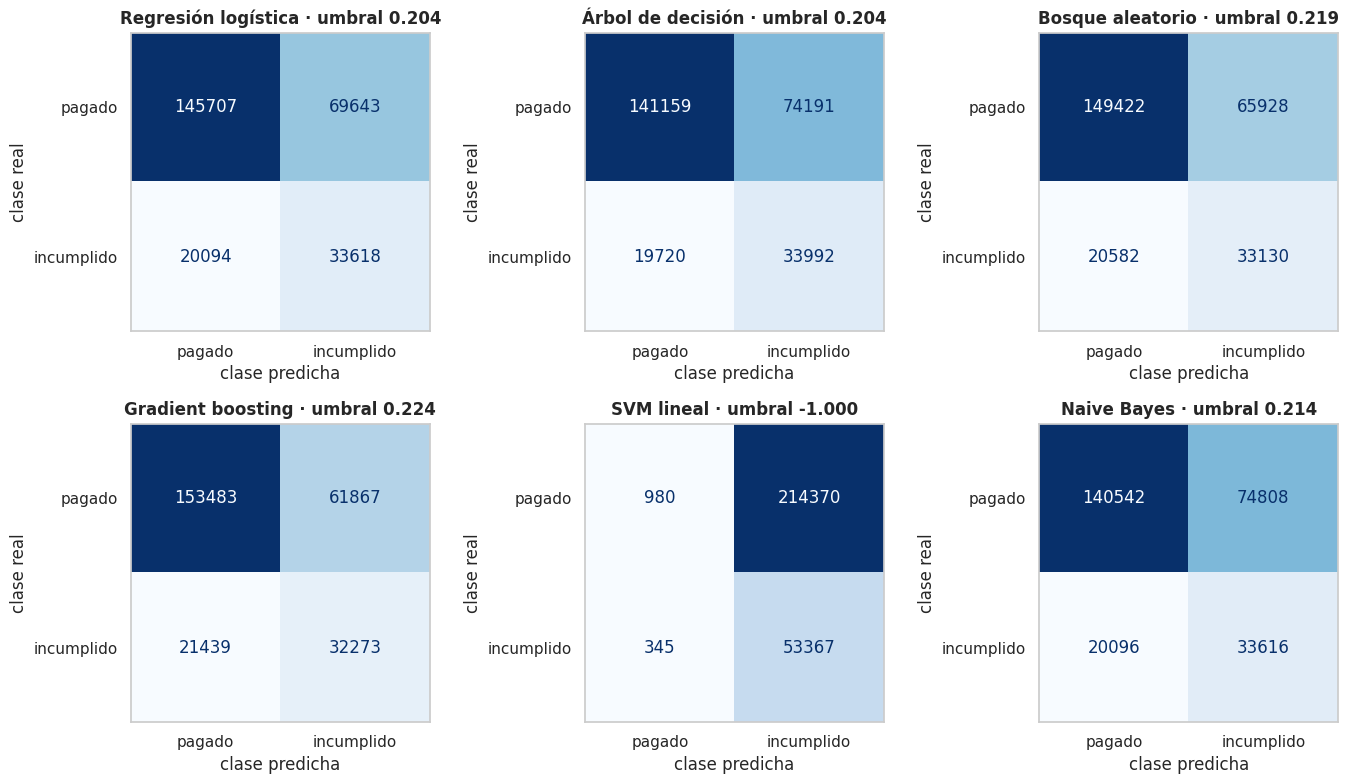

In [2]:
if "SCORES_TEST" not in globals():      # permite ejecutar esta celda sola, desde los resultados guardados
    _st = pd.read_parquet(RESULTS / "sk_scores_test.parquet")
    RES = json.loads((RESULTS / "sk_resultados.json").read_text(encoding="utf-8"))["modelos"]
    y_test = _st["y"].to_numpy()
    SCORES_TEST = {k: _st[k].to_numpy() for k in RES}
filas = []
for clave, r in RES.items():
    s = SCORES_TEST[clave]
    for nombre, thr in (("defecto", r["umbral_defecto"]), ("umbral F1 (OOF)", r["umbral_f1"])):
        mt = lc.threshold_metrics(y_test, s, thr)
        filas.append({"modelo": r["modelo"], "umbral usado": nombre, **mt, "ROC AUC": r["auc_test"],
                      "AUC-PR": average_precision_score(y_test, s)})
met = pd.DataFrame(filas).set_index(["modelo", "umbral usado"])
fmt = {c: "{:.4f}" for c in ["accuracy", "precision", "recall", "f1", "ROC AUC", "AUC-PR", "balanced_acc", "mcc", "especificidad"]}
fmt.update({"umbral": "{:.3f}", "TN": "{:,.0f}", "FP": "{:,.0f}", "FN": "{:,.0f}", "TP": "{:,.0f}"})
display(met[["umbral", "accuracy", "precision", "recall", "f1", "ROC AUC", "AUC-PR", "TN", "FP", "FN", "TP"]].style.format(fmt))
met.to_csv(RESULTS / "sk_metricas_test.csv")

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
for a, (clave, r) in zip(ax.ravel(), RES.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, (SCORES_TEST[clave] >= r["umbral_f1"]).astype(int),
                                            display_labels=["pagado", "incumplido"], cmap="Blues", ax=a,
                                            colorbar=False, values_format="d")
    a.set(xlabel="clase predicha", ylabel="clase real")
    a.set_title(f"{r['modelo']} · umbral {r['umbral_f1']:.3f}")
    a.grid(False)
plt.tight_layout()
plt.show()

Con el umbral por defecto la exactitud es alta pero la sensibilidad es muy baja en los
modelos que ordenan bien pero no cruzan 0.5 (la clase minoritaria rara vez supera esa probabilidad):
es el efecto del desbalance, y la razón por la que **la exactitud no sirve** como criterio aquí. Con el
umbral elegido en el entrenamiento cada modelo detecta una fracción mucho mayor de incumplimientos a
costa de más falsas alarmas.

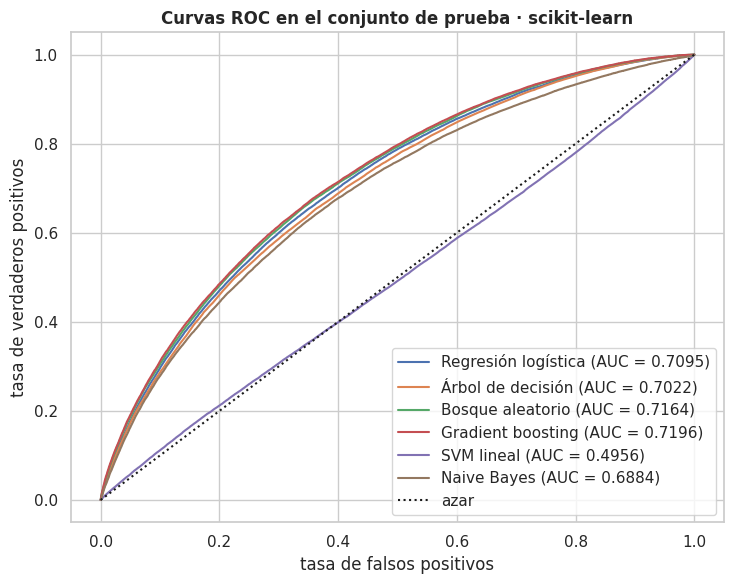

In [3]:
if "SCORES_TEST" not in globals():      # permite ejecutar esta celda sola, desde los resultados guardados
    _st = pd.read_parquet(RESULTS / "sk_scores_test.parquet")
    RES = json.loads((RESULTS / "sk_resultados.json").read_text(encoding="utf-8"))["modelos"]
    y_test = _st["y"].to_numpy()
    SCORES_TEST = {k: _st[k].to_numpy() for k in RES}
from sklearn.metrics import roc_curve  # noqa: E402

fig, ax = plt.subplots(figsize=(7.5, 6))
for clave, r in RES.items():
    fpr, tpr, _ = roc_curve(y_test, SCORES_TEST[clave])
    ax.plot(fpr, tpr, label=f"{r['modelo']} (AUC = {r['auc_test']:.4f})")
ax.plot([0, 1], [0, 1], "k:", label="azar")
ax.set(xlabel="tasa de falsos positivos", ylabel="tasa de verdaderos positivos")
ax.legend(loc="lower right")
ax.set_title("Curvas ROC en el conjunto de prueba · scikit-learn")
plt.tight_layout()
plt.show()

## 2.8 Guardar las puntuaciones del conjunto de prueba, los umbrales y los tiempos

Se guardan, para cada modelo, las puntuaciones continuas del conjunto de prueba junto con `id` y `default`
(`resultados/sk_scores_test.parquet`), que usará la prueba de DeLong, y las puntuaciones **fuera de
pliegue** del entrenamiento (`sk_scores_oof.parquet`) con las que se eligió cada umbral.

In [13]:
pd.DataFrame({"id": test["id"].to_numpy(), "y": y_test, **{k: v for k, v in SCORES_TEST.items()}}).to_parquet(
    RESULTS / "sk_scores_test.parquet", index=False)
pd.DataFrame({"id": train["id"].to_numpy(), "y": y_train, **{k: v for k, v in SCORES_OOF.items()}}).to_parquet(
    RESULTS / "sk_scores_oof.parquet", index=False)
ESTADO = {"modelos": RES, "tiempos_comunes_s": TIMES, "hilos": N_CPU, "ram_gb": psutil.virtual_memory().total / 1e9,
          "filas_train": int(N_TRAIN), "filas_test": int(len(y_test)), "n_features_modelo": int(X_train.shape[1]),
          "gb_hist": GB_HIST, "sklearn": sklearn.__version__, "dif_escalado_auc_cv": DIF_ESCALADO}
(RESULTS / "sk_resultados.json").write_text(json.dumps(ESTADO, indent=1, default=float), encoding="utf-8")
print("Guardado:", sorted(p.name for p in RESULTS.glob("sk_*")))

Guardado: ['sk_cv_DT.csv', 'sk_cv_GB.csv', 'sk_cv_LR.csv', 'sk_cv_RF.csv', 'sk_cv_SVM.csv', 'sk_metricas_test.csv', 'sk_resultados.json', 'sk_resumen_modelos.csv', 'sk_scores_oof.parquet', 'sk_scores_test.parquet']


## 2.9 Validación temporal complementaria (bosque aleatorio)

La partición aleatoria mezcla épocas: el modelo "conoce" el futuro (préstamos posteriores a los que
predice). En la práctica un modelo de crédito se entrena con el pasado y se usa en el futuro. Para
medir cuánto optimismo introduce la partición aleatoria, se entrena con préstamos **≤ 2014** y se
evalúa con los de **2015**, en plazo de **36 meses** (los de 36 meses otorgados en 2015 vencían a más tardar a finales
de 2018, así que la censura vista en el EDA es mínima). Se comparan **las mismas filas** de prueba con el modelo de la
partición aleatoria (bosque con los mejores hiperparámetros de 2.5).

In [14]:
rf_best = BEST["RF"]
tr_t = train[(train["issue_year"] <= 2014) & (train["term_months"] == 36)]
te_t = test[(test["issue_year"] == 2015) & (test["term_months"] == 36)]
prep_t = lc.make_preprocessor()
Xt_tr = prep_t.fit_transform(tr_t[lc.FEATURES]).astype(np.float32)
Xt_te = prep_t.transform(te_t[lc.FEATURES]).astype(np.float32)
rf_t = RandomForestClassifier(**{**rf_best.get_params(deep=False), "n_jobs": -1}).fit(Xt_tr, tr_t["default"])
auc_temporal = roc_auc_score(te_t["default"], rf_t.predict_proba(Xt_te)[:, 1])
p_rand = rf_best.predict_proba(prep.transform(te_t[lc.FEATURES]).astype(np.float32))[:, 1]
auc_random_mismas = roc_auc_score(te_t["default"], p_rand)
display(pd.DataFrame({"AUC en préstamos de 2015 (36 m)": [auc_random_mismas, auc_temporal],
                      "entrenó con": ["partición aleatoria (todos los años, incl. 2015 y posteriores)", "solo 2007–2014"]},
                     index=["Modelo de la partición aleatoria", "Modelo temporal (pasado → futuro)"]))
print(f"Filas de entrenamiento temporal: {len(tr_t):,} · filas de prueba (2015, 36 m): {len(te_t):,} · "
      f"diferencia de AUC = {auc_random_mismas - auc_temporal:+.4f}")
ESTADO["auc_temporal_2015_36m"], ESTADO["auc_aleatorio_mismas_filas"] = float(auc_temporal), float(auc_random_mismas)
del tr_t, Xt_tr, Xt_te, rf_t
gc.collect()

,AUC en préstamos de 2015 (36 m),entrenó con
Modelo de la partición aleatoria,0.6977,"partición aleatoria (todos los años, incl. 201..."
Modelo temporal (pasado → futuro),0.6884,solo 2007–2014


Filas de entrenamiento temporal: 268,455 · filas de prueba (2015, 36 m): 56,626 · diferencia de AUC = +0.0093


14930

La diferencia entre las dos filas es el **optimismo** de validar de forma aleatoria en
datos con orden temporal. El AUC que mejor anticipa el desempeño futuro es el temporal, que suele ser
algo menor.

> **Nota.** Esta comparación mezcla tres factores a la vez: el optimismo temporal, un tamaño de entrenamiento
> distinto (1.08 millones de filas en el modelo aleatorio frente a 268 455 en el temporal, todas a 36
> meses) y una composición de datos distinta. Por eso la diferencia no mide el optimismo temporal de forma aislada:
> el mayor tamaño del modelo aleatorio tiende a agrandarla y la composición más homogénea del temporal
> podría reducirla. Además, es una sola partición temporal y se reporta sin intervalo de confianza.

## 2.10 Importancia de variables (bosque aleatorio)

La importancia por **permutación** mide cuánto cae el AUC al barajar una variable (sobre 50 000 filas
de prueba, solo por costo; es una herramienta de **interpretación**, no se usa para elegir nada).

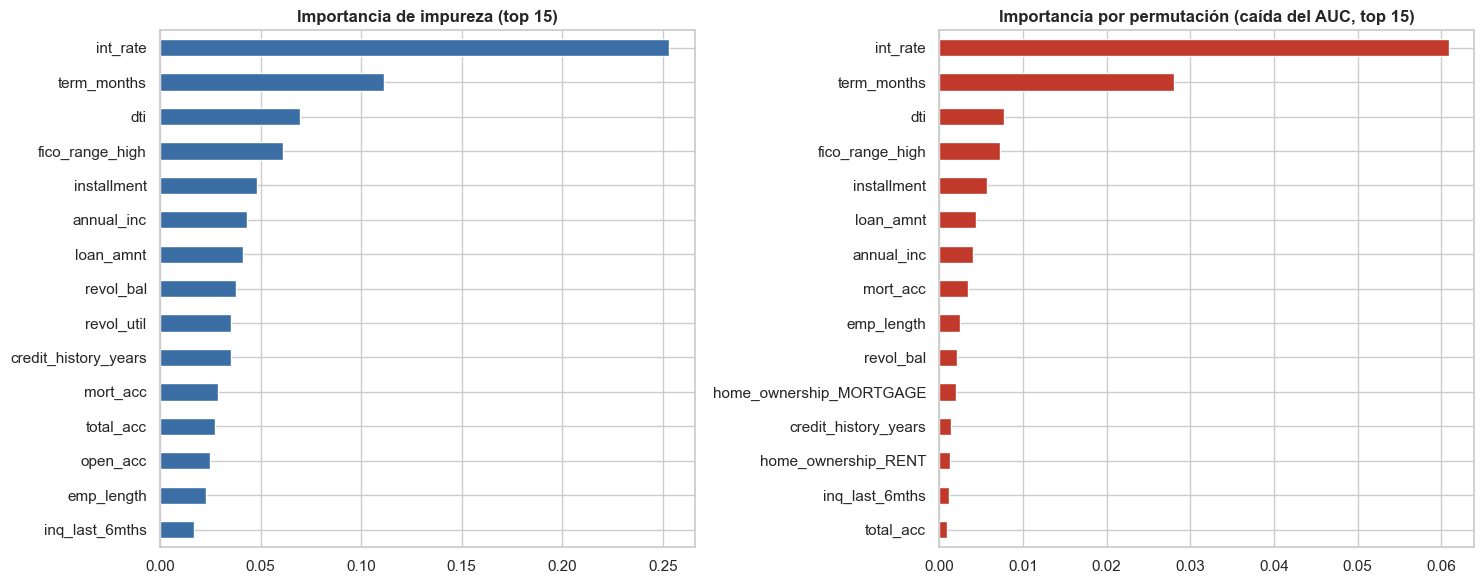

In [15]:
imp_imp = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)
sub = np.random.default_rng(lc.SEED).choice(len(y_test), 50000, replace=False)
pi = permutation_importance(rf_best, X_test[sub], y_test[sub], scoring="roc_auc", n_repeats=3, random_state=lc.SEED, n_jobs=-1)
imp_perm = pd.Series(pi.importances_mean, index=feature_names).sort_values(ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
imp_imp.head(15).iloc[::-1].plot.barh(ax=ax[0], color="#3b6ea5")
ax[0].set(title="Importancia de impureza (top 15)")
imp_perm.head(15).iloc[::-1].plot.barh(ax=ax[1], color="#c0392b")
ax[1].set(title="Importancia por permutación (caída del AUC, top 15)")
plt.tight_layout()
plt.show()

## 2.11 Latencia de predicción del mejor modelo con probabilidades (para LIME)

LIME se aplica al modelo de **mayor AUC de cada entorno entre los que entregan probabilidades**
(`LinearSVC` no las produce). Necesita evaluar el modelo miles de veces sobre datos perturbados;
se mide cuánto tarda `predict_proba` según el tamaño del lote.

In [16]:
prob = {k: r["auc_test"] for k, r in RES.items() if r["tipo_puntuacion"] == "proba"}
LIME_CLAVE = max(prob, key=prob.get)
print(f"Mejor modelo con probabilidades (AUC en test): {lm.NOMBRES[LIME_CLAVE]} = {prob[LIME_CLAVE]:.4f}")
mejor = BEST[LIME_CLAVE]
Xl = X_test if not lm.USA_ESCALADO.get(LIME_CLAVE) else Xs_test
lat = {}
for n in (1, 100, 5000):
    ts = []
    for _ in range(5):
        t0 = time.perf_counter()
        mejor.predict_proba(Xl[:n])
        ts.append(time.perf_counter() - t0)
    lat[n] = float(np.median(ts))
print({k: f"{v * 1000:.1f} ms" for k, v in lat.items()})
ESTADO["lime_modelo"] = LIME_CLAVE
ESTADO["latencia_predict_s"] = {str(k): v for k, v in lat.items()}

Mejor modelo con probabilidades (AUC en test): Gradient boosting = 0.7196
{1: '0.2 ms', 100: '0.6 ms', 5000: '13.5 ms'}


## 2.12 Experimento de escala: ¿cuánto tarda un bosque según el volumen?

Se ajusta **un bosque fijo** (50 árboles, profundidad 10, `n_jobs=-1`) con subconjuntos crecientes del
entrenamiento (las filas con `rank` < N, el mismo orden aleatorio que usará PySpark) y se mide el tiempo.
Es un *benchmark* de tiempos, por eso aquí sí hay submuestras; los modelos principales se entrenan
con todo el conjunto de entrenamiento.

In [17]:
rank_train = split.loc[~es_test, "rank"].to_numpy()
esc = []
for n in [10_000, 50_000, 100_000, 250_000, 500_000, N_TRAIN]:
    sel = rank_train < n
    t0 = time.time()
    rf_e = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=lc.SEED, n_jobs=-1).fit(X_train[sel], y_train[sel])
    t_fit = time.time() - t0
    a = roc_auc_score(y_test, rf_e.predict_proba(X_test)[:, 1])
    esc.append({"filas_train": int(sel.sum()), "t_ajuste_s": t_fit, "auc_test": a})
    print(f"{int(sel.sum()):>10,} filas · ajuste {t_fit:6.1f} s · AUC {a:.4f}", flush=True)
pd.DataFrame(esc).to_csv(RESULTS / "escala_sklearn.csv", index=False)

    10,000 filas · ajuste    0.3 s · AUC 0.7012


    50,000 filas · ajuste    0.7 s · AUC 0.7086


   100,000 filas · ajuste    1.2 s · AUC 0.7101


   250,000 filas · ajuste    3.3 s · AUC 0.7113


   500,000 filas · ajuste    6.9 s · AUC 0.7114


 1,076,248 filas · ajuste   16.2 s · AUC 0.7114


## 2.13 Guardar los artefactos para los siguientes capítulos

In [18]:
ESTADO["tiempo_total_modelos_s"] = float(sum(r["t_entrenamiento_con_cv_s"] + r["t_prediccion_s"] for r in RES.values()))
(RESULTS / "sk_resultados.json").write_text(json.dumps(ESTADO, indent=1, default=float), encoding="utf-8")
joblib.dump({"prep": prep, "scaler": scaler if lm.USA_ESCALADO.get(LIME_CLAVE) else None, "model": BEST[LIME_CLAVE],
             "clave": LIME_CLAVE, "threshold": RES[LIME_CLAVE]["umbral_f1"]}, DATA_DIR / "models" / "sk_lime_model.joblib")
joblib.dump(BEST["RF"], DATA_DIR / "models" / "sk_rf.joblib")
print("Artefactos guardados en data/models/ · tiempo total de entrenamiento+predicción de los seis modelos: "
      f"{ESTADO['tiempo_total_modelos_s'] / 60:.1f} min")

Artefactos guardados en data/models/ · tiempo total de entrenamiento+predicción de los seis modelos: 80.2 min


# 3 · Preprocesamiento y modelado con PySpark (seis modelos)

**Objetivo del capítulo.** Lo mismo que en el capítulo de scikit-learn, pero con **Spark MLlib**:
lectura del CSV completo, las mismas variables, la **misma partición** entrenamiento/prueba **y los mismos
pliegues**, los **seis modelos** (`LogisticRegression`, `DecisionTreeClassifier`,
`RandomForestClassifier`, `GBTClassifier`, `LinearSVC`, `NaiveBayes`) con `ParamGridBuilder` +
`CrossValidator` (`numFolds = 3`), medición de tiempos y LIME sobre el mejor modelo con probabilidades.

## Protocolo experimental en PySpark

| Elemento | Dónde |
|---|---|
| Conjunto de datos **completo**, sin muestreo | 3.2 (se lee el CSV entero) |
| Ninguna transferencia de datos al *driver* antes de entrenar | Ninguna celda lo hace antes del ajuste. Las únicas transferencias al driver son **agregados diminutos** (conteos por categoría, sumas de aciertos para el umbral) y, **después de entrenar**, `id`, `default` y la puntuación del conjunto de prueba (3 columnas) para DeLong y las curvas ROC |
| `StringIndexer` + `OneHotEncoder` + `VectorAssembler` | 3.4 |
| **Cachear** el DataFrame tras el `VectorAssembler` y antes del modelo (`persist(MEMORY_AND_DISK)`) | 3.4 |
| Hiperparámetros **solo** con `ParamGridBuilder` + `CrossValidator` (`numFolds = 3`, `foldCol` con los mismos pliegues que scikit-learn), sin bucles manuales | 3.5 |
| Evaluar con `BinaryClassificationEvaluator`; exactitud, precisión, sensibilidad, F1, ROC AUC y matriz de confusión (manual) | 3.5 y 3.6 |
| Tiempo total de entrenamiento y predicción de **cada modelo** (incluye la validación cruzada); la transferencia de `id`, `default` y puntuación se mide aparte | 3.5 |
| Configuración de la sesión (paralelismo y memoria) | 3.1 |

> **Nota.** La partición 80/20 **no** usa `randomSplit`: se lee el mismo archivo (`id`, `split`, `fold`) que el capítulo de
> scikit-learn (hecho en el EDA, estratificado), de modo que ambos motores ven exactamente los mismos
> préstamos. `randomSplit` solo aparece en la sección 3.3, en una celda de demostración que muestra por qué
> no serviría para este fin; **no interviene en la partición real ni en el entrenamiento de los modelos**.

In [1]:
import gc
import json
import os
import platform
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_models as lm  # noqa: E402
from src import lc_spark_models as lsm  # noqa: E402
from src import lc_utils as lc  # noqa: E402

# Spark 3.5 necesita Java 8/11/17 (no funciona con Java 25). Se usa el JDK 17 del entorno conda.
if "JAVA_HOME" not in os.environ:
    jvm = Path(sys.prefix) / "Library" / "lib" / "jvm"
    if jvm.exists():
        os.environ["JAVA_HOME"] = str(jvm)
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import pyspark  # noqa: E402
from pyspark import StorageLevel  # noqa: E402
from pyspark.ml import Pipeline  # noqa: E402
from pyspark.ml.feature import OneHotEncoder, StandardScaler, StringIndexer, VectorAssembler  # noqa: E402
from pyspark.ml.functions import vector_to_array  # noqa: E402
from pyspark.sql import SparkSession  # noqa: E402
from pyspark.sql import functions as F  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS, DATA_DIR = Path("../resultados"), Path("../data")
TIMES = {}
ESTADO = {}


def guardar_estado():
    """Escribe a disco lo calculado hasta ahora (si una etapa posterior fallara, no se pierde lo anterior)."""
    (RESULTS / "sp_resultados.json").write_text(
        json.dumps({**ESTADO, "tiempos_s": TIMES}, indent=2, default=float), encoding="utf-8")


print(f"Python {platform.python_version()} · PySpark {pyspark.__version__}")

Python 3.10.21 · PySpark 3.5.9


## 3.1 Configuración de la sesión

La sesión fija paralelismo y memoria de forma explícita, más dos líneas que **no** cambian esa
configuración: `spark.ui.showConsoleProgress` (apaga la barra de progreso para que la salida sea legible) y
`spark.sql.execution.arrow.pyspark.enabled = true` (transferencia en bloques entre Python y la JVM). La
segunda **no era opcional en la práctica**: en una ejecución preliminar de este trabajo, sin Arrow, cada
llamada de predicción desde Python tardó ≈ 7–8 minutos (se mide en el capítulo 3b).

In [2]:
t0 = time.time()
spark = (SparkSession.builder
         .appName("LendingClub_Optimized")
         .config("spark.sql.shuffle.partitions", "400")
         .config("spark.default.parallelism", "400")
         .config("spark.executor.memory", "8g")
         .config("spark.driver.memory", "8g")
         .config("spark.memory.fraction", 0.8)
         .config("spark.memory.storageFraction", 0.3)
         .config("spark.ui.showConsoleProgress", "false")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
TIMES["arranque_sesion"] = time.time() - t0
conf = dict(spark.sparkContext.getConf().getAll())
heap = spark._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1e9
print(f"Spark {spark.version} · master = {spark.sparkContext.master} · arranque {TIMES['arranque_sesion']:.1f} s")
print(f"defaultParallelism (fijado a mano, no son los núcleos reales): {spark.sparkContext.defaultParallelism}")
for k in ("spark.sql.shuffle.partitions", "spark.default.parallelism", "spark.executor.memory",
          "spark.driver.memory", "spark.memory.fraction", "spark.memory.storageFraction",
          "spark.sql.execution.arrow.pyspark.enabled"):
    print(f"  {k:32s} = {conf.get(k)}")
print(f"Memoria máxima de la JVM (heap): {heap:.1f} GB")

Spark 3.5.9 · master = local[*] · arranque 24.1 s
defaultParallelism (fijado a mano, no son los núcleos reales): 400
  spark.sql.shuffle.partitions     = 400
  spark.default.parallelism        = 400
  spark.executor.memory            = 8g
  spark.driver.memory              = 8g
  spark.memory.fraction            = 0.8
  spark.memory.storageFraction     = 0.3
  spark.sql.execution.arrow.pyspark.enabled = true
Memoria máxima de la JVM (heap): 8.6 GB


**Aclaración sobre el `defaultParallelism` de 400.** Este valor se debe a que
la sesión fija `spark.default.parallelism = 400` explícitamente; **no** son los núcleos reales. El equipo tiene
12 hilos lógicos (8 núcleos físicos). El valor 400 corresponde a una configuración pensada para un clúster con
muchos ejecutores; en el equipo utilizado equivale a más de 30 particiones por hilo, bastante más de lo que suele
convenir en una sola máquina, y su costo se mide en el capítulo 3b.

La ejecución se hace en **modo local** (`master = local[*]`): el *driver* y
los *executors* viven en **el mismo proceso** de la JVM. Por eso `spark.executor.memory = 8g` **no
tiene efecto** (no hay executors separados), y lo que limita la memoria es `spark.driver.memory`
(8 GB, verificado arriba en el *heap* real). En un clúster, ambos parámetros sí serían
independientes. Asimismo, `shuffle.partitions = 400` está pensado para un clúster: con 12 hilos
genera muchas tareas muy pequeñas. Su efecto real se mide en el capítulo 3b.

## 3.2 Lectura del CSV completo

`spark.read.csv` es **perezoso**: no lee nada hasta que se ejecuta una acción. Para medir el
tiempo de carga se fuerza la lectura con una acción que **no** transfiere datos al driver
(`format("noop")` procesa todas las filas y descarta el resultado).

In [3]:
CSV = str(lc.DATA_PATH)
# escape='"': en CSV, una comilla dentro de un texto entrecomillado se escribe duplicada (""). Sin esta
# opción Spark lee mal alguna fila (aquí: una fila menos entre los préstamos con desenlace conocido).
raw = spark.read.csv(CSV, header=True, inferSchema=False, escape='"')       # dataset COMPLETO
t0 = time.time()
raw.write.format("noop").mode("overwrite").save()                 # fuerza la lectura de las 151 columnas
TIMES["carga_csv_151_columnas"] = time.time() - t0
t0 = time.time()
n_total = raw.select(*lc.RAW_COLUMNS).count()                     # solo las 24 columnas necesarias
TIMES["carga_csv_24_columnas"] = time.time() - t0
print(f"Filas del archivo: {n_total:,} · columnas: {len(raw.columns)}")
print(f"Lectura completa (151 columnas, formato noop): {TIMES['carga_csv_151_columnas']:.1f} s")
print(f"Lectura de las 24 columnas necesarias + conteo:  {TIMES['carga_csv_24_columnas']:.1f} s")

Filas del archivo: 2,260,701 · columnas: 151
Lectura completa (151 columnas, formato noop): 8.0 s
Lectura de las 24 columnas necesarias + conteo:  3.8 s


**Comparabilidad de los tiempos de carga.** Estos tiempos no son comparables directamente con los de
pandas. Spark lee de forma **perezosa** y **descarta las columnas que ninguna operación necesita**
(*column pruning*): ni el `noop` ni el conteo requieren el valor de ninguna columna, así que Spark solo
recorre el archivo separando líneas (4–8 s). pandas, en cambio, **convierte a memoria las 151 columnas**
(más de un minuto; capítulo 1). El costo real de leer y convertir las columnas necesarias en Spark aparece
más abajo, dentro del **preprocesamiento** (sección 3.4: 323 s, que incluye leer, construir variables,
unir con la partición, ajustar los transformadores y cachear). En la sección 6.3 la comparación de
"carga" se hace con ese tiempo total en ambos lados.

## 3.3 Variables y partición (idénticas a las de scikit-learn)

Las variables se calculan con las **mismas reglas** que en pandas (`src/lc_utils.py`), escritas con
funciones de Spark. Luego se une con el archivo de la partición hecho en el EDA (`id`, `split`, `fold`).

**¿Por qué no `randomSplit`?** (1) No es **estratificado**; (2) su resultado depende del número de
particiones del DataFrame (no es reproducible si cambia el particionado; se demuestra abajo); y
(3) daría un conjunto de prueba **distinto** al de scikit-learn, impidiendo comparar ambos modelos sobre los mismos
préstamos. Unir con una lista fija de `id` es una transformación de Spark (no mueve datos al driver).

In [4]:
MONTHS_MAP = F.create_map([F.lit(x) for kv in lc.MONTHS.items() for x in kv])


def year_month(col):
    """'Aug-2003' -> 2003 + 7/12; misma regla que en pandas (independiente del idioma del sistema)."""
    return F.substring(col, -4, 4).cast("double") + (MONTHS_MAP[F.substring(col, 1, 3)].cast("double") - 1) / 12.0


NUM_RAW = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_high", "open_acc",
           "revol_bal", "revol_util", "total_acc", "pub_rec", "delinq_2yrs", "inq_last_6mths", "mort_acc"]


def build_features(sdf):
    d = sdf.filter(F.col("loan_status").isin(lc.RESOLVED))          # desenlace conocido (no es muestreo)
    return d.select(
        F.col("id").cast("string").alias("id"),
        (F.col("loan_status") == "Charged Off").cast("int").alias("default"),
        F.substring("issue_d", -4, 4).cast("int").alias("issue_year"),
        F.regexp_extract("term", r"(\d+)", 1).cast("double").alias("term_months"),
        F.when(F.col("emp_length").isNull(), F.lit(None).cast("double"))
         .when(F.col("emp_length").startswith("<"), F.lit(0.0))
         .otherwise(F.regexp_extract("emp_length", r"(\d+)", 1).cast("double")).alias("emp_length"),
        (year_month(F.col("issue_d")) - year_month(F.col("earliest_cr_line"))).alias("credit_history_years"),
        *[F.col(c).cast("double").alias(c) for c in NUM_RAW],
        *[F.coalesce(F.col(c), F.lit("Desconocido")).alias(c) for c in lc.CATEGORICAL])


t_prep0 = time.time()
split_sdf = spark.read.parquet(str(DATA_DIR / "split_ids.parquet"))           # id, split, fold, is_test, rank
feat = build_features(raw).join(F.broadcast(split_sdf), on="id", how="inner")
n_modelo = feat.count()
print(f"Préstamos con desenlace conocido tras unir con la partición: {n_modelo:,} (esperado: {split_sdf.count():,})")
assert n_modelo == split_sdf.count(), "El join perdió o duplicó filas"

# Paridad con pandas: las medias de cada variable deben coincidir con las calculadas en el capítulo de sklearn.
par = RESULTS / "paridad_features.json"
if par.exists():
    ref = json.loads(par.read_text())
    med = feat.agg(*[F.mean(c).alias(c) for c in lc.NUMERIC]).first().asDict()
    dif = pd.Series({c: abs(med[c] - ref["medias"][c]) / max(abs(ref["medias"][c]), 1e-12) for c in lc.NUMERIC})
    print(f"Paridad pandas vs Spark (diferencia relativa máxima de las medias): {dif.max():.2e}")
    assert dif.max() < 1e-9, "Las features de Spark no coinciden con las de pandas"

Préstamos con desenlace conocido tras unir con la partición: 1,345,310 (esperado: 1,345,310)


Paridad pandas vs Spark (diferencia relativa máxima de las medias): 2.28e-15


In [5]:
# ¿Por qué no randomSplit? Misma semilla, distinto particionado -> particiones DISTINTAS.
base = feat.select("id")
test8 = base.repartition(8).randomSplit([0.8, 0.2], seed=42)[1]
test64 = base.repartition(64).randomSplit([0.8, 0.2], seed=42)[1]
n8, n64, comun = test8.count(), test64.count(), test8.join(test64, "id").count()     # solo conteos
print(f"randomSplit con la MISMA semilla y distinto particionado (8 vs 64): test de {n8:,} y {n64:,} filas; "
      f"solo {comun / n8:.1%} de las filas de prueba coinciden -> no es reproducible entre configuraciones.")

randomSplit con la MISMA semilla y distinto particionado (8 vs 64): test de 268,696 y 269,605 filas; solo 20.0% de las filas de prueba coinciden -> no es reproducible entre configuraciones.


`test8` y `test64` son objetos desechables de esta demostración: no se usan en ninguna celda posterior.
La partición real de entrenamiento y prueba, la que sí alimenta los seis modelos, es la unión por `id`
hecha arriba (3.3) con el archivo compartido con scikit-learn; `randomSplit` no interviene en el modelado.

## 3.4 Preprocesamiento: `StringIndexer` + `OneHotEncoder` + `VectorAssembler` + caché

* **Categorías infrecuentes:** las que tengan **< 1 % del entrenamiento** se agrupan en
  `infrecuente` (igual que `OneHotEncoder(min_frequency=0.01)` de scikit-learn). Para calcularlas
  solo se traen al driver los **conteos por categoría** (≤ 51 filas por variable): un agregado
  mínimo, no el conjunto de datos.
* **Nulos numéricos:** centinela −1 (sin parámetros aprendidos), igual que en scikit-learn.
* **Escalado** (`StandardScaler`, media 0 y desviación 1) en la columna `features_sc`, que usan solo la
  regresión logística y la SVM lineal; los árboles, el *boosting* y Naive Bayes usan `features` (sin escalar).
  Se ajusta **solo con el entrenamiento** (como en scikit-learn).
* Los transformadores se **ajustan solo con el entrenamiento** y luego se aplican al conjunto de prueba.
* **Se cachea** el DataFrame resultante con `persist(MEMORY_AND_DISK)`, **después** del
  `VectorAssembler` y **antes** de cualquier modelo.

In [6]:
train_raw = feat.filter(F.col("split") == "train")
n_train = train_raw.count()
keep, n_raras = {}, {}
for c in lc.CATEGORICAL:
    conteos = train_raw.groupBy(c).count().collect()                # <= 51 filas: agregado diminuto
    keep[c] = sorted(r[c] for r in conteos if r["count"] >= 0.01 * n_train)
    n_raras[c] = len(conteos) - len(keep[c])
infrec = RESULTS / "categorias_infrecuentes.json"
if infrec.exists():
    ref = json.loads(infrec.read_text())
    for c in lc.CATEGORICAL:
        raras = sorted(r[c] for r in train_raw.groupBy(c).count().collect() if r["count"] < 0.01 * n_train)
        assert raras == ref[c], f"Categorías infrecuentes de {c} distintas a las de scikit-learn"
    print("Categorías infrecuentes idénticas a las de scikit-learn: OK")
print({c: len(v) for c, v in keep.items()}, "categorías frecuentes por variable")


def to_model_input(sdf):
    """Aplica las reglas de preprocesamiento sin parámetros aprendidos (mapeo de raras + centinela)."""
    out = sdf.na.fill(-1.0, subset=lc.NUMERIC)
    for c in lc.CATEGORICAL:
        out = out.withColumn(c, F.when(F.col(c).isin(keep[c]), F.col(c)).otherwise(F.lit("infrecuente")))
    return out


idx_out = [f"{c}_idx" for c in lc.CATEGORICAL]
ohe_out = [f"{c}_ohe" for c in lc.CATEGORICAL]
prep_stages = [StringIndexer(inputCols=lc.CATEGORICAL, outputCols=idx_out, handleInvalid="keep"),
               OneHotEncoder(inputCols=idx_out, outputCols=ohe_out, dropLast=False, handleInvalid="keep"),
               VectorAssembler(inputCols=lc.NUMERIC + ohe_out, outputCol="features", handleInvalid="keep"),
               StandardScaler(inputCol="features", outputCol="features_sc", withMean=True, withStd=True)]

train_in = to_model_input(train_raw)
test_in = to_model_input(feat.filter(F.col("split") == "test"))
prep_model = Pipeline(stages=prep_stages).fit(train_in)             # se ajusta SOLO con el entrenamiento
cols_keep = ["id", "default", "issue_year", "term_months", "rank", F.col("fold").cast("int").alias("fold"), "features", "features_sc"]
train_f = prep_model.transform(train_in).select(*cols_keep).persist(StorageLevel.MEMORY_AND_DISK)
test_f = prep_model.transform(test_in).select(*cols_keep).persist(StorageLevel.MEMORY_AND_DISK)
n_train_f, n_test_f = train_f.count(), test_f.count()               # materializa la caché
TIMES["preprocesamiento"] = time.time() - t_prep0
n_feat = len(train_f.select("features").first()[0])
n_equiv = len(lc.NUMERIC) + sum(len(keep[c]) + (1 if n_raras[c] > 0 else 0) for c in lc.CATEGORICAL)
print(f"train = {n_train_f:,} · test = {n_test_f:,} · preprocesamiento + caché en {TIMES['preprocesamiento']:.0f} s")
print(f"Dimensión del vector de features: {n_feat} (= {n_equiv} equivalentes a scikit-learn + "
      f"{n_feat - n_equiv} columnas 'categoría desconocida' que Spark añade con handleInvalid='keep' y quedan siempre en 0)")
print("Nivel de almacenamiento:", train_f.storageLevel)

Categorías infrecuentes idénticas a las de scikit-learn: OK
{'purpose': 8, 'home_ownership': 3, 'addr_state': 28, 'verification_status': 3} categorías frecuentes por variable


train = 1,076,248 · test = 269,062 · preprocesamiento + caché en 323 s
Dimensión del vector de features: 70 (= 62 equivalentes a scikit-learn + 8 columnas 'categoría desconocida' que Spark añade con handleInvalid='keep' y quedan siempre en 0)
Nivel de almacenamiento: Disk Memory Serialized 1x Replicated


## 3.5 Los seis modelos y sus espacios de búsqueda

**Los mismos** que en scikit-learn (`src/lc_models.py` define los espacios una sola vez). El efecto de
`maxBins` se analiza en la Discusión (diferencias de implementación).

| Modelo | Estimador de PySpark | Espacio de búsqueda | Datos |
|---|---|---|---|
| Regresión logística | `LogisticRegression(elasticNetParam=0)` (L2) | `regParam` ∈ {1e-6, 1e-5, 1e-4} | escalados |
| Árbol de decisión | `DecisionTreeClassifier` (`maxBins=32`) | `maxDepth` ∈ {5, 10, 15} | sin escalar |
| Bosque aleatorio | `RandomForestClassifier` (`maxBins=32`) | `numTrees` ∈ {10, 50, 100} × `maxDepth` ∈ {5, 10, 15} | sin escalar |
| Gradient boosting | `GBTClassifier(stepSize=0.1)` (`maxBins=32`) | `maxIter` ∈ {50, 100} × `maxDepth` ∈ {3, 5} | sin escalar |
| SVM lineal | `LinearSVC` (pérdida *hinge*, L2) | `regParam` ∈ {1e-6, 1e-5, 1e-4} | escalados |
| Naive Bayes | `NaiveBayes(modelType="gaussian")` | sin búsqueda (una combinación) | sin escalar |

## 3.6 Entrenamiento con `ParamGridBuilder` + `CrossValidator`

Para **cada** modelo (función `lsm.run_model`):

1. `CrossValidator(numFolds=3, foldCol="fold", parallelism=1)` con `BinaryClassificationEvaluator`
   (`areaUnderROC`), que también es el criterio de selección. `foldCol` hace que Spark use **los mismos
   3 pliegues estratificados** que scikit-learn (en vez de pliegues al azar sin estratificar). El tiempo incluye la validación cruzada y el
   reajuste final del mejor modelo con todo el entrenamiento.
2. Predicción sobre el conjunto de prueba con pocas tareas simultáneas (`coalesce`): cada tarea recibe
   una copia del modelo y, con un bosque grande, el *heap* de 8 GB no alcanza si se ejecutan unas 12 a la vez.
3. **Transferencia al driver, después de entrenar y predecir,** solo de `id`, `default` y la puntuación
   del conjunto de prueba (`probability[1]`, o `rawPrediction[1]` en `LinearSVC`); su tiempo se mide **aparte**.
4. Umbral de decisión con puntuaciones **fuera de pliegue** del entrenamiento: se reajusta el mejor
   modelo dejando fuera cada pliegue (bucle sobre **pliegues**, no sobre hiperparámetros) y los aciertos
   para una malla de umbrales se calculan con **agregados de Spark** (no se trae ninguna fila).

> **Nota.** El `BinaryClassificationEvaluator` usa `probability` (no `rawPrediction`) en los modelos que la tienen:
> en `DecisionTreeClassifier` la columna `rawPrediction` contiene **conteos** de la hoja, cuyo orden no es el
> de la probabilidad; `LinearSVC` no produce probabilidades, así que se evalúa con `rawPrediction`
> (el margen de decisión).

**Ajustes por restricciones de memoria.** Con 16 GB de RAM el bosque de 100 árboles y profundidad 15 agotó la memoria en
varios intentos (`OutOfMemoryError`) mientras se tuvo `parallelism = 3` y `maxMemoryInMB = 256`. La traza
mostró que se agotaban los buffers de **histogramas** de los niveles profundos. Las decisiones que lo
resolvieron y no cambian el algoritmo: `parallelism = 1` (un modelo a la vez), `maxMemoryInMB = 64` (límite
de memoria de histogramas por pasada; documentado en el modelo) y predicción con pocas tareas simultáneas.

In [7]:
MODELOS = {}
BEST_PROB = {"clave": None, "auc": -1.0, "modelo": None}         # solo se conserva en memoria el mejor con probabilidades
t_total0 = time.time()
for clave in lm.CLAVES:
    r, mdl = lsm.run_model(spark, clave, train_f, test_f, RESULTS, keep_model=(clave != "SVM"))
    MODELOS[clave] = r
    if mdl is not None and r["auc_test"] > BEST_PROB["auc"]:
        BEST_PROB.update(clave=clave, auc=r["auc_test"], modelo=mdl)
    del mdl
    gc.collect()
    spark._jvm.System.gc()
TIMES["seis_modelos_esta_sesion_s"] = time.time() - t_total0

[LR] mejores {'regParam': 1e-06} · AUC CV 0.7096 · entrenamiento+CV 3799 s


[LR] AUC test 0.7095 · predicción 0.8 s · transferencia 0.5 s · umbral OOF 0.206 (365 s)


[DT] mejores {'maxDepth': 10} · AUC CV 0.7002 · entrenamiento+CV 3867 s


[DT] AUC test 0.7004 · predicción 0.6 s · transferencia 0.3 s · umbral OOF 0.206 (334 s)


[RF] mejores {'maxDepth': 15, 'numTrees': 100} · AUC CV 0.7152 · entrenamiento+CV 21145 s


...

[GB] AUC test 0.7189 · predicción 2.4 s · transferencia 0.5 s · umbral OOF 0.216 (12059 s)


[SVM] mejores {'regParam': 1e-05} · AUC CV 0.6113 · entrenamiento+CV 12955 s


[SVM] AUC test 0.5985 · predicción 0.6 s · transferencia 0.3 s · umbral OOF -1.000 (3478 s)


[NB] mejores {} · AUC CV 0.6887 · entrenamiento+CV 2562 s


[NB] AUC test 0.6883 · predicción 0.6 s · transferencia 0.3 s · umbral OOF 0.216 (19 s)


## 3.7 Resumen de la validación cruzada y de los tiempos

,mejores hiperparámetros,maxBins,AUC CV,± sd (pliegues),AUC test,entrenamiento + CV (s),predicción test (s),transferencia al driver (s),umbral OOF (s)
modelo,,,,,,,,,
Regresión logística,"{""regParam"": 1e-06}",nan,0.7096,0.0002,0.7095,"3,799",0.8,0.5,365
Árbol de decisión,"{""maxDepth"": 10}",32.000000,0.7002,0.0005,0.7004,"3,867",0.6,0.3,334
Bosque aleatorio,"{""maxDepth"": 15, ""numTrees"": 100}",32.000000,0.7152,0.0002,0.7152,"21,145",39.3,7.9,"6,730"
Gradient boosting,"{""maxDepth"": 5, ""maxIter"": 100}",32.000000,0.7182,0.0001,0.7189,"36,419",2.4,0.5,"12,059"
SVM lineal,"{""regParam"": 1e-05}",nan,0.6113,0.0021,0.5985,"12,955",0.6,0.3,"3,478"
Naive Bayes,{},nan,0.6887,0.0007,0.6883,"2,562",0.6,0.3,19


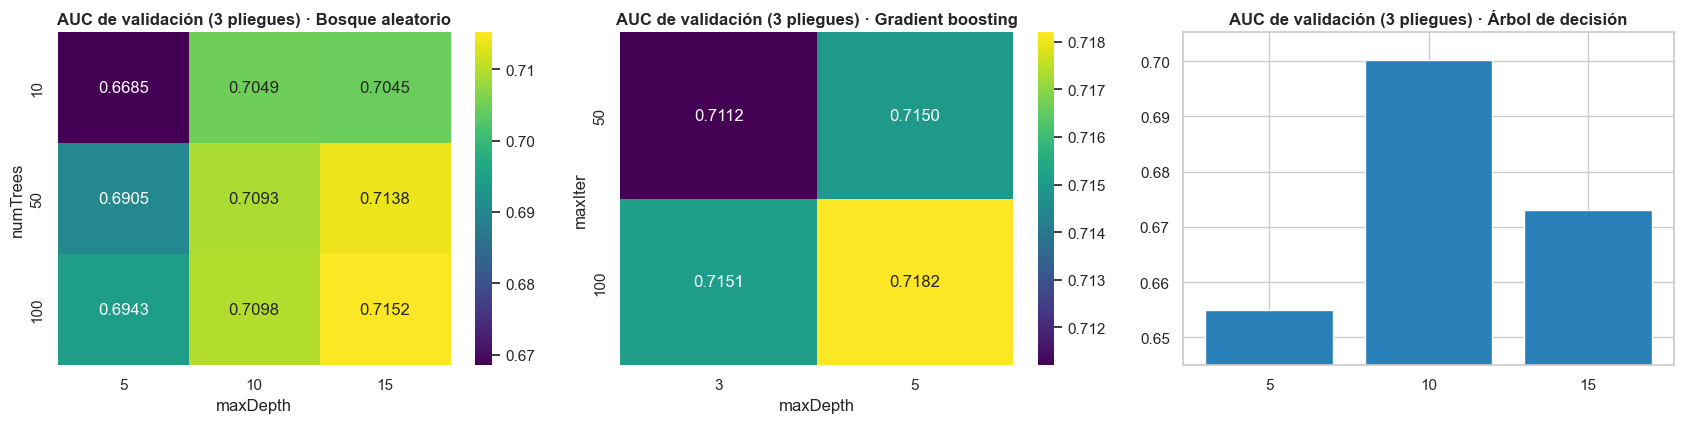

In [8]:
resumen = pd.DataFrame([{
    "modelo": r["modelo"], "mejores hiperparámetros": json.dumps(r["mejores_hiperparametros"]), "maxBins": r["maxBins"],
    "AUC CV": r["auc_cv"], "± sd (pliegues)": r["auc_cv_sd"], "AUC test": r["auc_test"],
    "entrenamiento + CV (s)": r["t_entrenamiento_con_cv_s"], "predicción test (s)": r["t_prediccion_s"],
    "transferencia al driver (s)": r["t_transferencia_s"], "umbral OOF (s)": r["t_oof_umbral_s"]}
    for r in MODELOS.values()]).set_index("modelo")
display(resumen.style.format({"AUC CV": "{:.4f}", "± sd (pliegues)": "{:.4f}", "AUC test": "{:.4f}", "entrenamiento + CV (s)": "{:,.0f}",
                              "predicción test (s)": "{:.1f}", "transferencia al driver (s)": "{:.1f}", "umbral OOF (s)": "{:,.0f}"}))
resumen.to_csv(RESULTS / "sp_resumen_modelos.csv")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
for a, clave in zip(ax, ["RF", "GB", "DT"]):
    cv_ = pd.read_csv(RESULTS / f"sp_cv_{clave}.csv")
    pcols = [c for c in cv_.columns if c != "mean_test_score"]
    if len(pcols) == 2:
        sns.heatmap(cv_.pivot(index=pcols[0], columns=pcols[1], values="mean_test_score"), annot=True, fmt=".4f", cmap="viridis", ax=a)
    else:
        a.bar(cv_[pcols[0]].astype(str), cv_["mean_test_score"], color="#2980b9")
        a.set_ylim(cv_["mean_test_score"].min() - 0.01, cv_["mean_test_score"].max() + 0.005)
    a.set_title(f"AUC de validación (3 pliegues) · {lm.NOMBRES[clave]}")
plt.tight_layout()
plt.show()

## 3.8 Evaluación en el conjunto de prueba

Se reportan **exactitud, precisión, sensibilidad, F1 y ROC AUC**, junto con la matriz de confusión, con el umbral por
defecto (0.5; 0 para el valor de decisión de `LinearSVC`) y con el umbral elegido en el entrenamiento
(fuera de pliegue). El cálculo usa las tres columnas transferidas (`id`, `default`, puntuación).

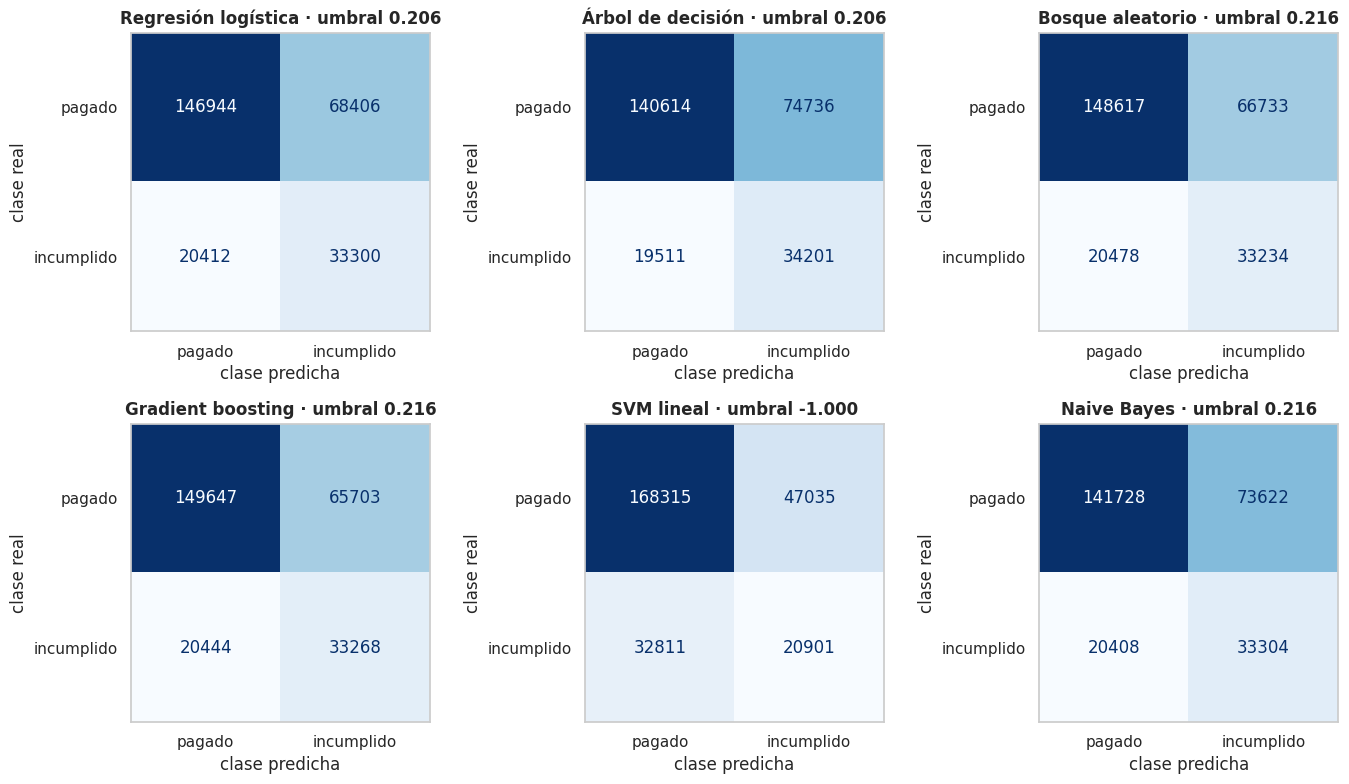

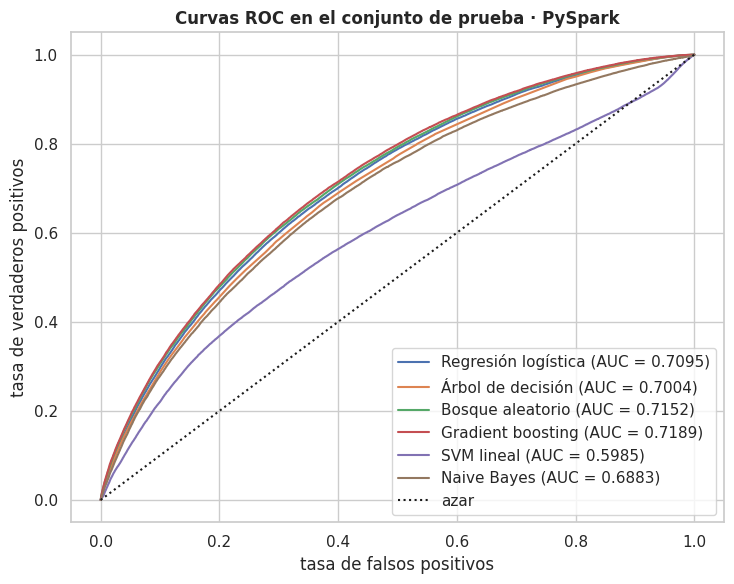

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, average_precision_score, roc_auc_score  # noqa: E402

from sklearn.metrics import roc_curve  # noqa: E402

SC = {k: pd.read_parquet(RESULTS / f"sp_scores_test_{k}.parquet") for k in lm.CLAVES}
if "MODELOS" not in globals():          # permite ejecutar esta celda sola, desde los resultados guardados
    MODELOS = {k: json.loads((RESULTS / f"sp_modelo_{k}.json").read_text(encoding="utf-8")) for k in lm.CLAVES}
for clave, r in MODELOS.items():
    r.setdefault("modelo", lm.NOMBRES[clave])
    r.setdefault("umbral_defecto", 0.0 if clave == "SVM" else 0.5)
filas = []
for clave, r in MODELOS.items():
    s = SC[clave]
    for nombre, thr in (("defecto", r["umbral_defecto"]), ("umbral F1 (OOF)", r["umbral_f1"])):
        mt = lc.threshold_metrics(s["y"].to_numpy(), s["score"].to_numpy(), thr)
        filas.append({"modelo": r["modelo"], "umbral usado": nombre, **mt, "ROC AUC": roc_auc_score(s["y"], s["score"]),
                      "AUC-PR": average_precision_score(s["y"], s["score"])})
met = pd.DataFrame(filas).set_index(["modelo", "umbral usado"])
fmt = {c: "{:.4f}" for c in ["accuracy", "precision", "recall", "f1", "ROC AUC", "AUC-PR"]}
fmt.update({"umbral": "{:.3f}", "TN": "{:,.0f}", "FP": "{:,.0f}", "FN": "{:,.0f}", "TP": "{:,.0f}"})
display(met[["umbral", "accuracy", "precision", "recall", "f1", "ROC AUC", "AUC-PR", "TN", "FP", "FN", "TP"]].style.format(fmt))
met.to_csv(RESULTS / "sp_metricas_test.csv")

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
for a, (clave, r) in zip(ax.ravel(), MODELOS.items()):
    s = SC[clave]
    ConfusionMatrixDisplay.from_predictions(s["y"], (s["score"] >= r["umbral_f1"]).astype(int), display_labels=["pagado", "incumplido"],
                                            cmap="Blues", ax=a, colorbar=False, values_format="d")
    a.set(xlabel="clase predicha", ylabel="clase real")
    a.set_title(f"{r['modelo']} · umbral {r['umbral_f1']:.3f}")
    a.grid(False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 6))
for clave, r in MODELOS.items():
    s = SC[clave]
    fpr, tpr, _ = roc_curve(s["y"], s["score"])
    ax.plot(fpr, tpr, label=f"{r['modelo']} (AUC = {roc_auc_score(s['y'], s['score']):.4f})")
ax.plot([0, 1], [0, 1], "k:", label="azar")
ax.set(xlabel="tasa de falsos positivos", ylabel="tasa de verdaderos positivos")
ax.legend(loc="lower right")
ax.set_title("Curvas ROC en el conjunto de prueba · PySpark")
plt.tight_layout()
plt.show()

## 3.9 LIME con el mejor modelo de PySpark que entrega probabilidades

LIME se aplica al modelo de mayor AUC de cada entorno entre los que entregan probabilidades
(`LinearSVC` no las produce), sobre dos préstamos mal clasificados por ambos entornos. Aquí se
hace con el modelo de Spark **tal como quedó tras la validación cruzada**, dentro de la misma sesión
(en Windows, Spark requiere `winutils` para escribir modelos en disco, así que LIME se ejecuta en la
misma sesión del entrenamiento). Los dos préstamos se eligieron entre los que
fallan en ambos entornos (uno que incumplió y ambos modelos dejaron pasar; uno que se pagó y ambos
marcaron como riesgoso), para poder comparar las explicaciones de scikit-learn (capítulo 4) y de PySpark.

Solo se traen al driver **una fila** (la instancia) y **20 000 filas de entrenamiento** al azar que LIME
necesita como referencia estadística; esas filas **no** entrenan nada y se traen **después** de entrenar.

In [10]:
sk_meta = json.loads((RESULTS / "sk_resultados.json").read_text())
clave_sk = sk_meta["lime_modelo"]
prob_sp = {k: r["auc_test"] for k, r in MODELOS.items() if r["score_col"] == "probability"}
clave_sp = max(prob_sp, key=prob_sp.get)
print(f"scikit-learn: {lm.NOMBRES[clave_sk]} (AUC {sk_meta['modelos'][clave_sk]['auc_test']:.4f}) · "
      f"PySpark: {lm.NOMBRES[clave_sp]} (AUC {prob_sp[clave_sp]:.4f})")
thr_sk, thr_sp = sk_meta["modelos"][clave_sk]["umbral_f1"], MODELOS[clave_sp]["umbral_f1"]
d = (pd.read_parquet(RESULTS / "sk_scores_test.parquet")[["id", "y", clave_sk]].rename(columns={clave_sk: "p_sklearn"})
     .merge(SC[clave_sp][["id", "score"]].rename(columns={"score": "p_spark"}), on="id"))
d["pct"] = d["p_sklearn"].rank(pct=True) + d["p_spark"].rank(pct=True)          # percentil conjunto de riesgo
fn = d[(d["y"] == 1) & (d["p_sklearn"] < thr_sk) & (d["p_spark"] < thr_sp)].nsmallest(1, "pct").iloc[0]
fp = d[(d["y"] == 0) & (d["p_sklearn"] >= thr_sk) & (d["p_spark"] >= thr_sp)].nlargest(1, "pct").iloc[0]
inst = {"FN": {"id": str(fn["id"]), "p_sklearn": float(fn["p_sklearn"]), "p_spark": float(fn["p_spark"])},
        "FP": {"id": str(fp["id"]), "p_sklearn": float(fp["p_sklearn"]), "p_spark": float(fp["p_spark"])},
        "modelo_sklearn": clave_sk, "modelo_spark": clave_sp, "umbral_sklearn": thr_sk, "umbral_spark": thr_sp}
(RESULTS / "instancias_lime.json").write_text(json.dumps(inst, indent=1), encoding="utf-8")
print(json.dumps(inst, indent=1))

scikit-learn: Gradient boosting (AUC 0.7196) · PySpark: Gradient boosting (AUC 0.7189)


{
 "FN": {
  "id": "36099806",
  "p_sklearn": 0.02005936721168558,
  "p_spark": 0.02212184328392397
 },
 "FP": {
  "id": "55961482",
  "p_sklearn": 0.8256249625310915,
  "p_spark": 0.8630584017737063
 },
 "modelo_sklearn": "GB",
 "modelo_spark": "GB",
 "umbral_sklearn": 0.22363636363636363,
 "umbral_spark": 0.2159
}


In [11]:
modelo_lime = BEST_PROB["modelo"] if BEST_PROB["clave"] == clave_sp else None
if modelo_lime is None:                                  # tras una reanudación el objeto ya no está en memoria: se reajusta
    t0 = time.time()
    modelo_lime = lsm.refit_best(clave_sp, MODELOS[clave_sp], train_f)
    print(f"Modelo reajustado con sus mejores hiperparámetros en {time.time() - t0:.0f} s")
col_prob = "probability"
ref_lime = train_raw.select(*lc.FEATURES).sample(fraction=0.03, seed=lc.SEED).limit(20000).toPandas()     # referencia de LIME
filas_lime = {k: feat.filter(F.col("id") == inst[k]["id"]).select(*lc.FEATURES).toPandas() for k in ("FN", "FP")}
print(f"Referencia para LIME: {len(ref_lime):,} filas de entrenamiento · instancias: {[len(v) for v in filas_lime.values()]} fila(s)")


def predecir_spark(pdf: pd.DataFrame) -> np.ndarray:
    """DataFrame de variables crudas (pandas) -> probabilidad de incumplimiento, con el modelo de Spark."""
    s = spark.createDataFrame(pdf[lc.FEATURES]).coalesce(1)
    x = prep_model.transform(to_model_input(s))
    return np.array(lsm.pred_con(modelo_lime, x, n=1).select(vector_to_array(col_prob)[1]).toPandas().iloc[:, 0])


# Latencia real del modelo final (con Arrow) según el tamaño del lote
lote = feat.filter(F.col("split") == "test").select(*lc.FEATURES).limit(5000).toPandas()
lat = {}
for n in (1, 100, 5000):
    ts = []
    for _ in range(3):
        t0 = time.perf_counter()
        predecir_spark(lote.iloc[:n])
        ts.append(time.perf_counter() - t0)
    lat[n] = float(np.median(ts))
print("Latencia del modelo final de Spark (con Arrow):", {k: f"{v:.2f} s" for k, v in lat.items()})

Referencia para LIME: 20,000 filas de entrenamiento · instancias: [1, 1] fila(s)


Latencia del modelo final de Spark (con Arrow): {1: '0.29 s', 100: '0.27 s', 5000: '0.51 s'}


In [12]:
adapter = lc.LimeAdapter(ref_lime, predecir_spark, extra=pd.concat(filas_lime.values()))
LIME = {"modelo": clave_sp, "latencia_predict_s": {str(k): v for k, v in lat.items()}, "instancias": {}}
for k, f in filas_lime.items():
    t0 = time.time()
    e = adapter.explain(f, num_features=10, num_samples=5000)
    seg = time.time() - t0
    LIME["instancias"][k] = {"id": inst[k]["id"], "tiempo_s": seg, "r2_local": float(e.score),
                             "pred_local": float(e.local_pred[0]), "p_spark": float(predecir_spark(f)[0]),
                             "pesos": [[a_, float(b_)] for a_, b_ in e.as_list(label=1)]}
    print(f"\n=== {k} (préstamo {inst[k]['id']}) · {seg:.1f} s · R² local {e.score:.3f} · probabilidad de Spark "
          f"{LIME['instancias'][k]['p_spark']:.3f}")
    display(pd.DataFrame(e.as_list(label=1), columns=["condición de la variable", "peso (hacia 'incumple' si > 0)"]))
(RESULTS / "lime_spark.json").write_text(json.dumps(LIME, indent=1, default=float), encoding="utf-8")


=== FN (préstamo 36099806) · 0.6 s · R² local 0.510 · probabilidad de Spark 0.022


,condición de la variable,peso (hacia 'incumple' si > 0)
0,int_rate <= 9.17,-0.1222
1,term_months <= 36.00,-0.0859
2,fico_range_high > 714.00,-0.0460
3,dti <= 12.08,-0.0395
4,home_ownership=MORTGAGE,-0.0294
5,open_acc <= 8.00,-0.0239
6,inq_last_6mths <= 0.00,-0.0191
7,annual_inc > 90496.25,-0.0164
8,revol_bal > 19969.75,-0.0164
9,verification_status=Not Verified,-0.0148



=== FP (préstamo 55961482) · 0.6 s · R² local 0.554 · probabilidad de Spark 0.863


,condición de la variable,peso (hacia 'incumple' si > 0)
0,int_rate > 15.59,0.1297
1,term_months > 36.00,0.0943
2,fico_range_high > 714.00,-0.0428
3,dti <= 12.08,-0.0380
4,home_ownership=RENT,0.0280
5,loan_amnt > 20000.00,0.0252
6,mort_acc <= 0.00,0.0220
7,annual_inc > 90496.25,-0.0213
8,open_acc <= 8.00,-0.0212
9,total_acc <= 16.00,0.0207


1897

## 3.10 Guardar resultados

In [13]:
ESTADO.update({"spark_version": spark.version, "heap_jvm_gb": float(heap), "nucleos_defaultParallelism": int(spark.sparkContext.defaultParallelism),
               "hilos_reales": os.cpu_count(), "filas_train": int(n_train_f), "filas_test": int(n_test_f), "dimension_features": int(n_feat),
               "numFolds": 3, "maxMemoryInMB": lsm.MAXMEM, "maxBins": lsm.MAXBINS, "lime_modelo": clave_sp, "modelos": MODELOS})
guardar_estado()
print("Guardado:", sorted(p.name for p in RESULTS.glob("sp_*")))
spark.stop()

Guardado: ['sp_cv_DT.csv', 'sp_cv_GB.csv', 'sp_cv_LR.csv', 'sp_cv_NB.csv', 'sp_cv_RF.csv', 'sp_cv_SVM.csv', 'sp_metricas_test.csv', 'sp_modelo_DT.json', 'sp_modelo_GB.json', 'sp_modelo_LR.json', 'sp_modelo_NB.json', 'sp_modelo_RF.json', 'sp_modelo_SVM.json', 'sp_resultados.json', 'sp_resumen_modelos.csv', 'sp_scores_test_DT.parquet', 'sp_scores_test_GB.parquet', 'sp_scores_test_LR.parquet', 'sp_scores_test_NB.parquet', 'sp_scores_test_RF.parquet', 'sp_scores_test_SVM.parquet']


# 3b · Costos de PySpark: latencia de predicción y efecto de la configuración

El capítulo 3 entrenó y evaluó los seis modelos. Aquí se hacen las **pruebas de costo** que sustentan
la discusión sobre el desempeño de Spark:

1. **Latencia de predicción** desde Python y qué implica para LIME (¿por qué tardaba ≈ 8 minutos
   una predicción en una ejecución preliminar?).
2. **Efecto de cada elemento de la configuración** (caché, particiones, pliegues del `CrossValidator`).
3. **Experimento de escala**: ¿desde qué volumen conviene Spark?

> **Nota.** Este capítulo corre en una **sesión nueva** (misma configuración del capítulo 3): las pruebas se
> hacen con **bosques pequeños** entrenados aquí, no con el bosque final de 100 árboles y
> profundidad 15. En 3b.2 se describe por qué, en una **ejecución preliminar** de este trabajo (sin
> Apache Arrow), una sola predicción tardaba ≈ 8 minutos, y en 3b.3 se comprueba. La sesión definitiva del
> capítulo 3 ya usa Arrow.

In [1]:
import json
import os
import platform
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_spark as lcs  # noqa: E402
from src import lc_utils as lc  # noqa: E402

lcs.configure_java()
import pyspark  # noqa: E402
from pyspark import StorageLevel  # noqa: E402
from pyspark.ml.classification import RandomForestClassifier  # noqa: E402
from pyspark.ml.evaluation import BinaryClassificationEvaluator  # noqa: E402
from pyspark.ml.functions import vector_to_array  # noqa: E402
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder  # noqa: E402
from pyspark.sql import functions as F  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS, DATA_DIR = Path("../resultados"), Path("../data")
MAXMEM = 64
ESTADO = {}


def guardar():
    (RESULTS / "spark_costos.json").write_text(json.dumps(ESTADO, indent=2, default=float), encoding="utf-8")


print(f"Python {platform.python_version()} · PySpark {pyspark.__version__} · {os.cpu_count()} hilos lógicos")

Python 3.10.21 · PySpark 3.5.9 · 12 hilos lógicos


## 3b.1 Sesión y datos

Misma configuración de sesión del capítulo 3 (con **Arrow desactivado al inicio**, para medir su efecto) y los
mismos datos, preparados y **cacheados**.

In [2]:
t0 = time.time()
spark = lcs.start_session()
train_f, test_f, prep_model, keep, to_model_input, feat, train_raw = lcs.prepare(spark, DATA_DIR)
n_train_f, n_test_f = train_f.count(), test_f.count()
print(f"Sesión y datos listos en {time.time() - t0:.0f} s · train {n_train_f:,} · test {n_test_f:,} · "
      f"particiones de train_f: {train_f.rdd.getNumPartitions()}")
evaluador = BinaryClassificationEvaluator(labelCol="default", rawPredictionCol="rawPrediction", metricName="areaUnderROC")


def pred_con(modelo, df, n=3):
    """Aplica un modelo con pocas tareas simultáneas (cada tarea recibe una copia del modelo)."""
    return modelo.transform(df.coalesce(n))

Sesión y datos listos en 123 s · train 1,076,248 · test 269,062 · particiones de train_f: 400


## 3b.2 El síntoma: una predicción con el bosque final tardaba ≈ 8 minutos

En una ejecución preliminar de este trabajo (sin Arrow) se intentó medir la latencia con el **bosque final** (100 árboles,
profundidad 15). La interfaz de Spark registró el tiempo de cada llamada
(`resultados/spark_ui_llamadas_bosque_final.json`, copiado de la interfaz web de Spark). El bosque
tiene millones de nodos, así que la primera hipótesis fue que el costo estuviera en el modelo: que
cada llamada tuviera que serializarlo y enviarlo a las tareas. La prueba de 3b.3 no respalda esa
hipótesis, aunque sin repetir la medición con el bosque final (ver el límite señalado en 3b.3).
(La correspondencia entre cada llamada y su tamaño de lote se deduce del orden en que el código las
ejecutaba: cinco llamadas con 1 fila y luego las primeras con 100; la ejecución se interrumpió allí.) Como estos
tiempos se transcribieron de la interfaz web de Spark, se presentan como una observación preliminar y no
como una medición controlada.

In [3]:
ui = json.loads((RESULTS / "spark_ui_llamadas_bosque_final.json").read_text())
ui = pd.DataFrame(ui)
display(ui[["filas por llamada", "segundos"]].rename(columns={"segundos": "tiempo de la llamada (s)"}))
print(f"Mediana de las {len(ui)} llamadas: {ui['segundos'].median():.0f} s = {ui['segundos'].median() / 60:.1f} min "
      f"(scikit-learn: {json.loads((RESULTS / 'sk_resultados.json').read_text())['latencia_predict_s']['1'] * 1000:.1f} ms para 1 fila)")
ESTADO["latencia_bosque_final_mediana_s"] = float(ui["segundos"].median())

,filas por llamada,tiempo de la llamada (s)
0,1,535.6000
1,1,476.2000
2,1,468.7000
3,1,465.1000
4,1,462.9000
5,100,467.8000
6,100,469.5000


Mediana de las 7 llamadas: 469 s = 7.8 min (scikit-learn: 0.2 ms para 1 fila)


El tiempo es **igual** para 1 fila o para 100: no depende de cuántos préstamos se
predicen, sino de un **sobrecosto fijo elevado por llamada**. Como LIME necesita al menos una llamada por
explicación, con esa configuración explicar **un solo préstamo** costaría ≈ 8 minutos (frente a
fracciones de segundo con scikit-learn). Hay dos causas posibles y se miden **por separado**:
(a) el costo de **enviar el lote** a Spark y (b) el costo de **enviar el modelo** a las tareas.

## 3b.3 Dos costos por separado

### (a) Enviar el lote a Spark (`createDataFrame` desde pandas)
Con `spark.default.parallelism = 400` (fijado en la sesión), `createDataFrame` reparte incluso un lote
diminuto en hasta 400 particiones, y cada partición arranca un proceso de Python (operación especialmente lenta en Windows).
Se mide con y sin **Apache Arrow** (transferencia en bloques). Sin Arrow se hace **una sola
repetición** porque cada medición tarda minutos.

In [4]:
lote_base = feat.filter(F.col("is_test")).select(*lc.FEATURES).limit(5000).toPandas()     # 5 000 filas del test (post-entrenamiento)


def tiempo_crear(n, arrow, reps=3):
    spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true" if arrow else "false")
    ts = []
    for _ in range(reps):
        t0_ = time.perf_counter()
        spark.createDataFrame(lote_base.iloc[:n]).coalesce(1).count()
        ts.append(time.perf_counter() - t0_)
    return float(np.median(ts))


crear = []
for arrow in (True, False):
    for n in (1, 100, 5000):
        crear.append({"Arrow": "sí" if arrow else "no", "filas": n, "createDataFrame + count (s)": tiempo_crear(n, arrow, reps=3 if arrow else 1)})
        print(crear[-1], flush=True)
crear = pd.DataFrame(crear)
display(crear)
ESTADO["createDataFrame_s"] = crear.to_dict(orient="records")
guardar()

{'Arrow': 'sí', 'filas': 1, 'createDataFrame + count (s)': 0.051292199990712106}


{'Arrow': 'sí', 'filas': 100, 'createDataFrame + count (s)': 0.07277450000401586}


{'Arrow': 'sí', 'filas': 5000, 'createDataFrame + count (s)': 0.09927650005556643}


{'Arrow': 'no', 'filas': 1, 'createDataFrame + count (s)': 430.08549309999216}


{'Arrow': 'no', 'filas': 100, 'createDataFrame + count (s)': 426.3655910999514}


{'Arrow': 'no', 'filas': 5000, 'createDataFrame + count (s)': 423.35713969997596}


,Arrow,filas,createDataFrame + count (s)
0,sí,1,0.0513
1,sí,100,0.0728
2,sí,5000,0.0993
3,no,1,430.0855
4,no,100,426.3656
5,no,5000,423.3571


### (b) Enviar el modelo a las tareas
Se entrenan dos bosques pequeños (con **44** y con **≈ 19 000 nodos**) y se mide la predicción de un
lote (con Arrow activado, para que el costo del lote sea mínimo). Si el tiempo dependiera del
tamaño del modelo, debería crecer con el número de nodos.

In [5]:
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
modelos = {}
for nombre, kw in (("10 árboles, prof. 5", dict(numTrees=10, maxDepth=5)), ("20 árboles, prof. 10", dict(numTrees=20, maxDepth=10))):
    t0 = time.time()
    m_ = RandomForestClassifier(labelCol="default", featuresCol="features", seed=lc.SEED, maxMemoryInMB=MAXMEM, **kw).fit(train_f)
    modelos[nombre] = m_
    print(f"{nombre}: {m_.totalNumNodes:,} nodos · ajuste {time.time() - t0:.0f} s", flush=True)


def predecir(modelo, lote_pdf):
    s = spark.createDataFrame(lote_pdf).coalesce(1)
    x = prep_model.transform(to_model_input(s))
    return np.array(pred_con(modelo, x, n=1).select(vector_to_array("probability")[1]).toPandas().iloc[:, 0])


lat_rows = []
for nombre, m_ in modelos.items():
    for n in (1, 100, 5000):
        ts = []
        for _ in range(3):
            t0 = time.perf_counter()
            predecir(m_, lote_base.iloc[:n])
            ts.append(time.perf_counter() - t0)
        lat_rows.append({"modelo": nombre, "nodos": m_.totalNumNodes, "filas": n, "latencia mediana (s)": float(np.median(ts))})
lat = pd.DataFrame(lat_rows)
display(lat)
ESTADO["latencia_modelos_pequenos"] = lat.to_dict(orient="records")
guardar()

10 árboles, prof. 5: 44 nodos · ajuste 56 s


20 árboles, prof. 10: 19,302 nodos · ajuste 167 s


,modelo,nodos,filas,latencia mediana (s)
0,"10 árboles, prof. 5",44,1,0.2376
1,"10 árboles, prof. 5",44,100,0.2654
2,"10 árboles, prof. 5",44,5000,0.3380
3,"20 árboles, prof. 10",19302,1,0.2949
4,"20 árboles, prof. 10",19302,100,0.2590
5,"20 árboles, prof. 10",19302,5000,0.3998


In [6]:
sk = json.loads((RESULTS / "sk_resultados.json").read_text())
mediano = lat[lat["modelo"] == "20 árboles, prof. 10"].set_index("filas")["latencia mediana (s)"]
comp = pd.DataFrame({"scikit-learn (mejor modelo con probabilidades)": {int(k): v for k, v in sk["latencia_predict_s"].items()},
                     "PySpark (20 árboles, prof. 10, Arrow)": mediano.to_dict()})
comp["PySpark / scikit-learn"] = comp.iloc[:, 1] / comp.iloc[:, 0]
comp.index.name = "filas por llamada"
display(comp.style.format({"scikit-learn (mejor modelo con probabilidades)": "{:.4f} s", "PySpark (20 árboles, prof. 10, Arrow)": "{:.3f} s",
                           "PySpark / scikit-learn": "{:,.0f}×"}))
ESTADO["latencia_predict_s"] = {str(k): float(v) for k, v in mediano.items()}
guardar()

,scikit-learn (mejor modelo con probabilidades),"PySpark (20 árboles, prof. 10, Arrow)",PySpark / scikit-learn
filas por llamada,,,
1,0.0002 s,0.295 s,"1,221×"
100,0.0006 s,0.259 s,461×
5000,0.0135 s,0.400 s,30×


De estas mediciones se desprenden tres conclusiones:

* **(a) Sin Arrow, mover incluso una sola fila a Spark tarda ≈ 426 s (7.1 min)**, casi lo mismo para 1,
  100 o 5 000 filas: el costo es fijo. La explicación más probable son las 400 particiones fijadas en la
  sesión (400 tareas de Python que arrancar), aunque esta prueba solo varió Arrow y no el número de
  particiones. Con Arrow es de centésimas de segundo. Ese costo fijo coincide con las llamadas de
  ≈ 465 s del bosque final (3b.2): **la causa de los ≈ 8 minutos era el envío del lote sin Arrow, no el
  modelo.**
* **(b) Con Arrow, el tiempo de predicción es ≈ 0.3 s y prácticamente igual para un modelo de 44 nodos
  que para uno de ≈ 19 000**, y casi igual para 1 fila que para 5 000. Es decir, todavía queda un
  costo fijo de ≈ 0.3 s por llamada (planificar el trabajo, lanzar tareas, traer el resultado), que
  **no depende del modelo ni del lote**.
* scikit-learn tiene el modelo en la memoria del mismo proceso: la misma predicción de 1 fila cuesta
  décimas de milisegundo. La diferencia va de **poco más de un orden de magnitud (≈ 38×) con 5 000 filas
  a cerca de tres órdenes de magnitud (≈ 1 190×) con una sola fila**, porque el costo fijo de Spark pesa
  más cuanto más pequeño es el lote; en ningún caso llega a "minutos" si se usa Arrow.

> **Alcance de la medición.** No se repitió la medición con el bosque final (100 árboles, profundidad 15, millones de nodos): la
> sesión de la ejecución preliminar se cerró. Por eso **no se descarta** que un
> modelo de ese tamaño agregue algún costo de serialización, pero **no se observó** hasta 19 000 nodos
> y la diferencia de ≈ 8 min es consistente con el costo de enviar el lote sin Arrow.

## 3b.4 ¿Qué efecto tuvo cada elemento de la configuración? (micro-*benchmarks*)

Sobre **un bosque pequeño fijo** se mide qué ocurre al **quitar o cambiar** cada elemento. Son pruebas de
tiempo, no el modelo final. Cada condición se midió una sola vez y en orden fijo, así que los factores
son orientativos: el calentamiento de la JVM puede favorecer a la segunda medición.

In [7]:
def tiempo_fit(df_, n_trees=10, depth=10, seed=lc.SEED):
    t0_ = time.time()
    RandomForestClassifier(labelCol="default", featuresCol="features", numTrees=n_trees, maxDepth=depth, seed=seed,
                           maxMemoryInMB=MAXMEM).fit(df_)
    return time.time() - t0_


abl = []
# (a) Con y sin caché
peq = dict(n_trees=5, depth=5)
train_f.unpersist()
t_nocache = tiempo_fit(train_f, **peq)
train_f.persist(StorageLevel.MEMORY_AND_DISK)
train_f.count()
t_cache = tiempo_fit(train_f, **peq)
abl.append({"condición": "Caché tras VectorAssembler (5 árboles, prof. 5)", "con la condición (s)": t_cache,
            "sin / alternativa (s)": t_nocache, "alternativa": "sin .persist()"})
print(abl[-1], flush=True)

# (b) Particiones: 400 (fijadas en la sesión) vs 12 (≈ hilos)
tiempos_part = {}
for n_part in (400, os.cpu_count()):
    dfp = train_f.repartition(n_part).persist(StorageLevel.MEMORY_AND_DISK)
    dfp.count()
    tiempos_part[n_part] = tiempo_fit(dfp)
    dfp.unpersist()
abl.append({"condición": "400 particiones del DataFrame de entrenamiento (10 árboles, prof. 10)",
            "con la condición (s)": tiempos_part[400], "sin / alternativa (s)": tiempos_part[os.cpu_count()],
            "alternativa": f"{os.cpu_count()} particiones"})
print(abl[-1], flush=True)

# (c) CrossValidator: numFolds 2 vs 3 y parallelism 1 vs 3 (malla mínima de 2 combinaciones)
rf = RandomForestClassifier(labelCol="default", featuresCol="features", seed=lc.SEED, maxMemoryInMB=MAXMEM)
mini = ParamGridBuilder().addGrid(rf.numTrees, [5, 10]).addGrid(rf.maxDepth, [5]).build()
tiempos_cv = {}
for nf, par_ in ((2, 1), (3, 1), (3, 3)):
    t0_ = time.time()
    CrossValidator(estimator=rf, estimatorParamMaps=mini, evaluator=evaluador, numFolds=nf, seed=lc.SEED,
                   parallelism=par_).fit(train_f)
    tiempos_cv[(nf, par_)] = time.time() - t0_
abl.append({"condición": "CrossValidator con numFolds=3 (usado en los seis modelos) vs 2, malla de 2 combinaciones",
            "con la condición (s)": tiempos_cv[(3, 1)], "sin / alternativa (s)": tiempos_cv[(2, 1)], "alternativa": "numFolds=2"})
abl.append({"condición": "CrossValidator parallelism=1 (elegido) vs 3, 3 pliegues, malla de 2 combinaciones",
            "con la condición (s)": tiempos_cv[(3, 1)], "sin / alternativa (s)": tiempos_cv[(3, 3)], "alternativa": "parallelism=3"})
abl = pd.DataFrame(abl)
abl["factor (alternativa / condición)"] = abl["sin / alternativa (s)"] / abl["con la condición (s)"]
abl.to_csv(RESULTS / "spark_ablacion.csv", index=False)
display(abl.style.format({"con la condición (s)": "{:.1f}", "sin / alternativa (s)": "{:.1f}", "factor (alternativa / condición)": "{:.2f}"}))

{'condición': 'Caché tras VectorAssembler (5 árboles, prof. 5)', 'con la condición (s)': 50.64324641227722, 'sin / alternativa (s)': 68.54880404472351, 'alternativa': 'sin .persist()'}


{'condición': '400 particiones del DataFrame de entrenamiento (10 árboles, prof. 10)', 'con la condición (s)': 141.73896384239197, 'sin / alternativa (s)': 15.111820936203003, 'alternativa': '12 particiones'}


,condición,con la condición (s),sin / alternativa (s),alternativa,factor (alternativa / condición)
0,"Caché tras VectorAssembler (5 árboles, prof. 5)",50.6,68.5,sin .persist(),1.35
1,"400 particiones del DataFrame de entrenamiento (10 árboles, prof. 10)",141.7,15.1,12 particiones,0.11
2,"CrossValidator con numFolds=3 (usado en los seis modelos) vs 2, malla de 2 combinaciones",395.0,281.6,numFolds=2,0.71
3,"CrossValidator parallelism=1 (elegido) vs 3, 3 pliegues, malla de 2 combinaciones",395.0,350.7,parallelism=3,0.89


**Lectura de la tabla.** "Factor" es cuántas veces tarda más (> 1) o menos (< 1) la alternativa frente a la
opción usada en los capítulos 3 y 3b. Sirve para cuantificar qué efecto tuvo cada elemento de la
configuración en el tiempo de entrenamiento.

## 3b.5 Experimento de escala (mismo bosque fijo que en scikit-learn)

Se ajusta **un bosque fijo** (50 árboles, profundidad 10) con subconjuntos crecientes del
entrenamiento (`rank` < N, el mismo orden aleatorio fijo que usó scikit-learn), para ver cuándo
cambia el ganador en velocidad. Es un *benchmark*, por eso aquí sí hay submuestras.

In [8]:
tam = [10_000, 50_000, 100_000, 250_000, 500_000, n_train_f]
esc = []
for n in tam:
    sub = train_f.filter(F.col("rank") < n).persist(StorageLevel.MEMORY_AND_DISK)
    filas = sub.count()
    t0 = time.time()
    mdl = RandomForestClassifier(labelCol="default", featuresCol="features", numTrees=50, maxDepth=10, seed=lc.SEED,
                                 maxMemoryInMB=MAXMEM).fit(sub)
    t_fit = time.time() - t0
    t0 = time.time()
    a = evaluador.evaluate(pred_con(mdl, test_f))
    t_pred = time.time() - t0
    esc.append({"filas_train": int(filas), "t_ajuste_s": t_fit, "t_prediccion_s": t_pred, "auc_test": a})
    print(f"{filas:>10,} filas · ajuste {t_fit:7.1f} s · predicción+AUC {t_pred:5.1f} s · AUC {a:.4f}", flush=True)
    sub.unpersist()
    del mdl
    pd.DataFrame(esc).to_csv(RESULTS / "escala_spark.csv", index=False)
esc = pd.DataFrame(esc)

    10,000 filas · ajuste   161.0 s · predicción+AUC  21.0 s · AUC 0.7003


    50,000 filas · ajuste   172.2 s · predicción+AUC  21.9 s · AUC 0.7076


   100,000 filas · ajuste   179.2 s · predicción+AUC  21.7 s · AUC 0.7092


   250,000 filas · ajuste   201.5 s · predicción+AUC  22.0 s · AUC 0.7094


   500,000 filas · ajuste   219.2 s · predicción+AUC  21.8 s · AUC 0.7089


 1,076,248 filas · ajuste   257.6 s · predicción+AUC  20.9 s · AUC 0.7084


## 3b.6 Guardar y cerrar

In [9]:
guardar()
print("Resultados guardados. Claves del capítulo 3b:", sorted(ESTADO))
spark.stop()

Resultados guardados. Claves del capítulo 3b: ['createDataFrame_s', 'latencia_bosque_final_mediana_s', 'latencia_modelos_pequenos', 'latencia_predict_s']


# 3c · PySpark con el paralelismo ajustado al equipo (análisis de sensibilidad)

En el capítulo 3b el experimento de escala mostró que, con las **400 particiones de la sesión**, Spark
gasta ≈ 160 s de costo fijo aunque se entrene con solo 10 000 filas, y que en la prueba de particiones
(3b.4) usar ≈ 12 particiones (los hilos del equipo utilizado) fue ≈ 9.4 veces más rápido. Para que la comparación con scikit-learn no dependa
únicamente de una configuración de Spark poco adecuada para el equipo utilizado, aquí se repite el
experimento de escala con el DataFrame de entrenamiento reagrupado en **12 particiones**.

> **Importante.** Esta variante **no sustituye** la configuración del capítulo 3: los resultados de los capítulos 3 y 5
> usan las 400 particiones. Sirve para responder a la pregunta
> "¿desde qué volumen conviene Spark?": la respuesta depende de cómo esté configurado, y una máquina
> de 12 hilos no es un clúster.

In [1]:
import json
import os
import platform
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_spark as lcs  # noqa: E402
from src import lc_utils as lc  # noqa: E402

lcs.configure_java()
import pyspark  # noqa: E402
from pyspark import StorageLevel  # noqa: E402
from pyspark.ml.classification import RandomForestClassifier  # noqa: E402
from pyspark.ml.evaluation import BinaryClassificationEvaluator  # noqa: E402
from pyspark.sql import functions as F  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS, DATA_DIR = Path("../resultados"), Path("../data")
MAXMEM = 64
NPART = os.cpu_count()
print(f"Python {platform.python_version()} · PySpark {pyspark.__version__} · {NPART} hilos lógicos")

Python 3.10.21 · PySpark 3.5.9 · 12 hilos lógicos


## 3c.1 Sesión (la del capítulo 3) y datos

La sesión sigue teniendo `spark.default.parallelism = 400`; lo único que cambia es el número de
particiones del **DataFrame de entrenamiento** de cada ajuste.

In [2]:
t0 = time.time()
spark = lcs.start_session()
train_f, test_f, prep_model, keep, to_model_input, feat, train_raw = lcs.prepare(spark, DATA_DIR)
n_train_f = train_f.count()
print(f"Sesión y datos listos en {time.time() - t0:.0f} s · train {n_train_f:,}")
evaluador = BinaryClassificationEvaluator(labelCol="default", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
test_pocas = test_f.coalesce(3)   # pocas tareas simultáneas: cada una recibe una copia del modelo

Sesión y datos listos en 93 s · train 1,076,248


## 3c.2 Experimento de escala con 12 particiones

Mismo bosque fijo que en 3b.5 (50 árboles, profundidad 10) y los mismos subconjuntos (`rank` < N).

In [3]:
tam = [10_000, 50_000, 100_000, 250_000, 500_000, n_train_f]
esc = []
for n in tam:
    sub = train_f.filter(F.col("rank") < n).repartition(NPART).persist(StorageLevel.MEMORY_AND_DISK)
    filas = sub.count()
    t0 = time.time()
    mdl = RandomForestClassifier(labelCol="default", featuresCol="features", numTrees=50, maxDepth=10, seed=lc.SEED,
                                 maxMemoryInMB=MAXMEM).fit(sub)
    t_fit = time.time() - t0
    a = evaluador.evaluate(mdl.transform(test_pocas))
    esc.append({"filas_train": int(filas), "t_ajuste_s": t_fit, "auc_test": a})
    print(f"{filas:>10,} filas · ajuste {t_fit:7.1f} s · AUC {a:.4f}", flush=True)
    sub.unpersist()
    del mdl
    pd.DataFrame(esc).to_csv(RESULTS / "escala_spark_12part.csv", index=False)
esc = pd.DataFrame(esc)
display(esc)
spark.stop()

    10,000 filas · ajuste    11.9 s · AUC 0.7006


    50,000 filas · ajuste    13.3 s · AUC 0.7075


   100,000 filas · ajuste    16.4 s · AUC 0.7088


   250,000 filas · ajuste    27.3 s · AUC 0.7095


   500,000 filas · ajuste    40.4 s · AUC 0.7091


 1,076,248 filas · ajuste    69.4 s · AUC 0.7084


,filas_train,t_ajuste_s,auc_test
0,10000,11.9233,0.7006
1,50000,13.3037,0.7075
2,100000,16.3609,0.7088
3,250000,27.2646,0.7095
4,500000,40.3746,0.7091
5,1076248,69.4192,0.7084


## 3c.3 Comparación con scikit-learn y con las 400 particiones

La comparación de las tres versiones (scikit-learn, Spark con 400 particiones y Spark con 12) se presenta
en la sección 6.4, junto con el ajuste afín `t = a + b·n` de cada curva. Con el entrenamiento completo, el
mismo bosque tarda ≈ 16 s en scikit-learn, ≈ 69 s en Spark con 12 particiones y ≈ 258 s con 400 (≈ 4× y
≈ 16× más). Reagrupar a 12 particiones reduce el costo fijo de Spark de ≈ 170 s a ≈ 12 s, pero su costo por
fila sigue siendo mayor que el de scikit-learn (≈ 54 s por millón de filas frente a ≈ 15 s), así que las
rectas no se cruzan en el equipo utilizado.

La ventaja de Spark aparece cuando los datos **no caben en la memoria de una máquina**, donde scikit-learn
requeriría estrategias fuera de memoria, o cuando hay un **clúster** con muchos nodos. Con el equipo utilizado (16 GB
de RAM) y este volumen (1.08 millones de filas de entrenamiento, 21 variables) no se llega a ese punto.

# 4 · Interpretabilidad con LIME

**¿Qué es LIME?** *Local Interpretable Model-agnostic Explanations*. Un modelo de cientos de árboles es una
"caja negra": da una probabilidad pero no dice **por qué**. LIME explica **una predicción concreta**:
perturba el préstamo (cambia un poco sus variables), evalúa el modelo en cada
versión perturbada y ajusta un modelo lineal **simple** que imita al modelo **solo cerca de ese
préstamo**. Los coeficientes de ese modelo lineal son la explicación: qué variables empujaron la
predicción hacia "incumple" o hacia "paga".

**Qué se explica.** LIME se aplica **al modelo de mayor AUC de cada entorno entre los que
entregan probabilidades** (`LinearSVC` no las produce), sobre dos instancias **mal clasificadas**. Se
explican **los mismos dos préstamos** en los dos entornos, elegidos porque **ambos modelos ganadores
fallan en ellos** (sección 3.9):

* **Falso negativo:** un préstamo que **incumplió** y que ambos modelos dejaron pasar con una
  probabilidad muy baja.
* **Falso positivo:** un préstamo que **se pagó** y que ambos modelos marcaron como riesgoso.

> **Nota.** LIME se aplica en el espacio de las **variables originales** (no en el de las columnas One-Hot),
> para que "purpose = credit_card" se lea como una sola variable. El adaptador está en
> `src/lc_utils.py::LimeAdapter`. La parte de PySpark se ejecutó **dentro de la sesión de Spark del
> capítulo 3** (el modelo vive allí); aquí se leen sus resultados (`resultados/lime_spark.json`).

In [1]:
import json
import platform
import sys
import time
import warnings
from pathlib import Path

import joblib
import lime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_models as lm  # noqa: E402
from src import lc_utils as lc  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS, DATA_DIR = Path("../resultados"), Path("../data")
print(f"Python {platform.python_version()}")

Python 3.10.21


## 4.1 Datos y modelo de scikit-learn

Se reconstruye la tabla con las mismas reglas y la misma partición, y se carga el **modelo de mayor AUC
entre los que dan probabilidades**, entrenado en el capítulo 2.

In [2]:
m = lc.build_model_frame(lc.load_raw(usecols=lc.RAW_COLUMNS))
split = pd.read_parquet(DATA_DIR / "split_ids.parquet")
assert split["id"].equals(m["id"])
es_test = (split["split"] == "test").to_numpy()
train, test = m.loc[~es_test].reset_index(drop=True), m.loc[es_test].reset_index(drop=True)
art = joblib.load(DATA_DIR / "models" / "sk_lime_model.joblib")
prep, scaler, modelo, clave, THR = art["prep"], art["scaler"], art["model"], art["clave"], art["threshold"]
ids = json.loads((RESULTS / "instancias_lime.json").read_text())
print(f"Modelo de scikit-learn explicado: {lm.NOMBRES[clave]} · umbral de decisión (F1 fuera de pliegue) = {THR:.3f}")


def predict_df(df: pd.DataFrame) -> np.ndarray:
    """DataFrame de variables crudas -> probabilidad de incumplimiento (preprocesamiento + modelo)."""
    x = prep.transform(df[lc.FEATURES]).astype(np.float32)
    if scaler is not None:
        x = scaler.transform(x)
    return modelo.predict_proba(x)[:, 1]


casos = {"Falso negativo": ids["FN"]["id"], "Falso positivo": ids["FP"]["id"]}
filas = {k: test[test["id"] == v].reset_index(drop=True) for k, v in casos.items()}
for k, f in filas.items():
    p = float(predict_df(f)[0])
    print(f"{k}: préstamo {casos[k]} · probabilidad del modelo de scikit-learn = {p:.3f} · realidad: "
          f"{'incumplió' if f['default'][0] == 1 else 'pagó'} · predijo {'incumple' if p >= THR else 'paga'} (umbral {THR:.3f})")

Modelo de scikit-learn explicado: Gradient boosting · umbral de decisión (F1 fuera de pliegue) = 0.224
Falso negativo: préstamo 36099806 · probabilidad del modelo de scikit-learn = 0.020 · realidad: incumplió · predijo paga (umbral 0.224)
Falso positivo: préstamo 55961482 · probabilidad del modelo de scikit-learn = 0.826 · realidad: pagó · predijo incumple (umbral 0.224)


## 4.2 Construcción del explicador

`LimeTabularExplainer` necesita **datos de referencia** para conocer la distribución de cada variable
(cuartiles para discretizar las continuas, frecuencias de las categorías). Se usan 20 000 filas de
**entrenamiento** al azar (no del conjunto de prueba). Estos datos **no** entrenan nada: solo describen cómo suelen ser
las variables.

In [3]:
ref = train.sample(20_000, random_state=lc.SEED)
adapter = lc.LimeAdapter(ref, predict_df, extra=pd.concat(filas.values()))

## 4.3 Explicación de los dos errores (scikit-learn)

In [4]:
explicaciones, tiempos = {}, {}
for k, f in filas.items():
    t0 = time.time()
    explicaciones[k] = adapter.explain(f, num_features=10, num_samples=5000)
    tiempos[k] = time.time() - t0
    e = explicaciones[k]
    print(f"\n=== {k} (préstamo {casos[k]}) · explicación calculada en {tiempos[k]:.1f} s ===")
    print(f"Probabilidad del modelo: {predict_df(f)[0]:.3f} · predicción del modelo lineal local: "
          f"{e.local_pred[0]:.3f} · R² local = {e.score:.3f}")
    display(pd.DataFrame(e.as_list(label=1), columns=["condición de la variable", "peso (hacia 'incumple' si > 0)"]))


=== Falso negativo (préstamo 36099806) · explicación calculada en 0.1 s ===
Probabilidad del modelo: 0.020 · predicción del modelo lineal local: -0.046 · R² local = 0.501


,condición de la variable,peso (hacia 'incumple' si > 0)
0,int_rate <= 9.75,-0.1234
1,term_months <= 36.00,-0.0807
2,fico_range_high > 714.00,-0.0410
3,dti <= 11.89,-0.0364
4,home_ownership=MORTGAGE,-0.0298
5,open_acc <= 8.00,-0.0220
6,inq_last_6mths <= 0.00,-0.0183
7,annual_inc > 90000.00,-0.0164
8,revol_bal > 20100.25,-0.0156
9,1.00 < mort_acc <= 3.00,-0.0144



=== Falso positivo (préstamo 55961482) · explicación calculada en 0.1 s ===
Probabilidad del modelo: 0.826 · predicción del modelo lineal local: 0.367 · R² local = 0.584


,condición de la variable,peso (hacia 'incumple' si > 0)
0,int_rate > 15.88,0.1380
1,term_months > 36.00,0.0858
2,fico_range_high > 714.00,-0.0388
3,dti <= 11.89,-0.0376
4,home_ownership=RENT,0.0287
5,annual_inc > 90000.00,-0.0236
6,loan_amnt > 20000.00,0.0217
7,inq_last_6mths > 1.00,0.0200
8,mort_acc <= 0.00,0.0185
9,revol_bal <= 5920.00,0.0164


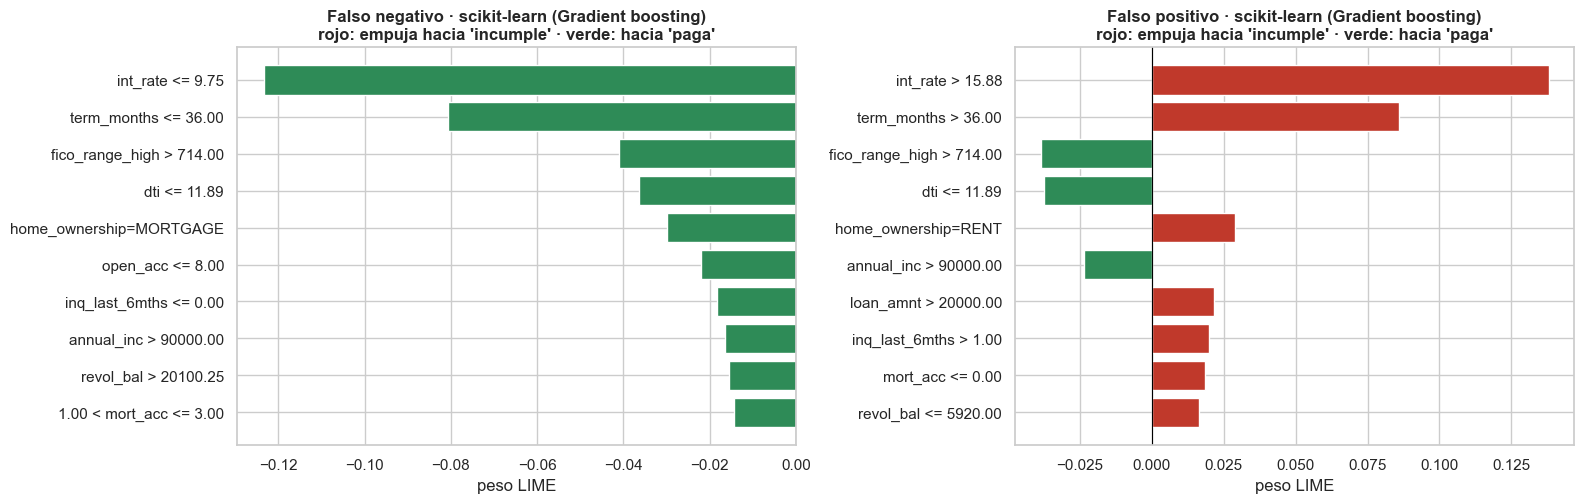

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5.2))
for a, (k, e) in zip(ax, explicaciones.items()):
    lista = e.as_list(label=1)[::-1]
    pesos = [w for _, w in lista]
    a.barh([n for n, _ in lista], pesos, color=["#c0392b" if w > 0 else "#2e8b57" for w in pesos])
    a.axvline(0, color="black", lw=0.8)
    a.set(title=f"{k} · scikit-learn ({lm.NOMBRES[clave]})\nrojo: empuja hacia 'incumple' · verde: hacia 'paga'", xlabel="peso LIME")
plt.tight_layout()
plt.show()

**Cómo se lee.** Cada barra es una condición de una variable ("int_rate > 15.88") y su peso: rojo
aumenta la probabilidad de incumplimiento, verde la reduce, para ese préstamo. R² local indica qué
tan bien el modelo lineal simple imita al modelo original cerca de esa instancia.

> **Importante.** LIME explica **al modelo**, no a la realidad del préstamo: los pesos describen qué llevó al modelo a
> dar esa probabilidad, no una relación de causa y efecto. La fidelidad local aquí es moderada
> (R² entre 0.50 y 0.58 en scikit-learn, entre 0.51 y 0.55 en PySpark), así que estas explicaciones son
> descriptivas y no deben usarse como justificación causal, ni como base única de una decisión de
> crédito individual. Además, el modelo lineal local no reproduce bien la probabilidad del modelo en todos
> los casos: para el falso positivo predice 0.37 frente a 0.83 del modelo, y para el falso negativo llega a
> un valor negativo (−0.05).

## 4.4 ¿Es estable la explicación? (limitación de LIME)

LIME **muestrea al azar**: dos ejecuciones sobre el mismo préstamo pueden dar explicaciones algo
distintas. Se repite 5 veces el falso negativo con distinta semilla y se compara qué variables
aparecen entre las 5 más importantes.

In [6]:
from lime.lime_tabular import LimeTabularExplainer  # noqa: E402

fila = filas["Falso negativo"]
top = []
for seed in range(5):
    ex = LimeTabularExplainer(adapter.encode(ref), feature_names=lc.FEATURES, categorical_features=adapter.cat_idx,
                              categorical_names={lc.FEATURES.index(c): adapter.levels[c] for c in lc.CATEGORICAL},
                              class_names=["pagado", "incumplido"], discretize_continuous=True, random_state=seed)
    e = ex.explain_instance(adapter.encode(fila)[0], adapter.predict_proba, labels=(1,), num_features=5, num_samples=5000)
    top.append([lc.FEATURES[i] for i, _ in sorted(e.as_map()[1], key=lambda t: -abs(t[1]))])
tabla_est = pd.DataFrame(top, index=[f"semilla {s}" for s in range(5)], columns=[f"top {i + 1}" for i in range(5)])
display(tabla_est)
freq = pd.Series([v for fila_ in top for v in fila_]).value_counts()
print("Frecuencia con la que cada variable aparece entre las 5 principales (de 5 ejecuciones):")
print(freq.to_string())

,top 1,top 2,top 3,top 4,top 5
semilla 0,int_rate,term_months,fico_range_high,dti,home_ownership
semilla 1,int_rate,term_months,fico_range_high,dti,home_ownership
semilla 2,int_rate,term_months,fico_range_high,dti,home_ownership
semilla 3,int_rate,term_months,fico_range_high,dti,home_ownership
semilla 4,int_rate,term_months,fico_range_high,dti,home_ownership


Frecuencia con la que cada variable aparece entre las 5 principales (de 5 ejecuciones):
int_rate           5
term_months        5
fico_range_high    5
dti                5
home_ownership     5


## 4.5 De lo local a lo global (agregando muchas explicaciones)

LIME explica **un préstamo a la vez**. Para ver qué variables importan *en general* se promedia el valor
absoluto del peso sobre 60 préstamos de prueba al azar.

60 explicaciones en 3 s


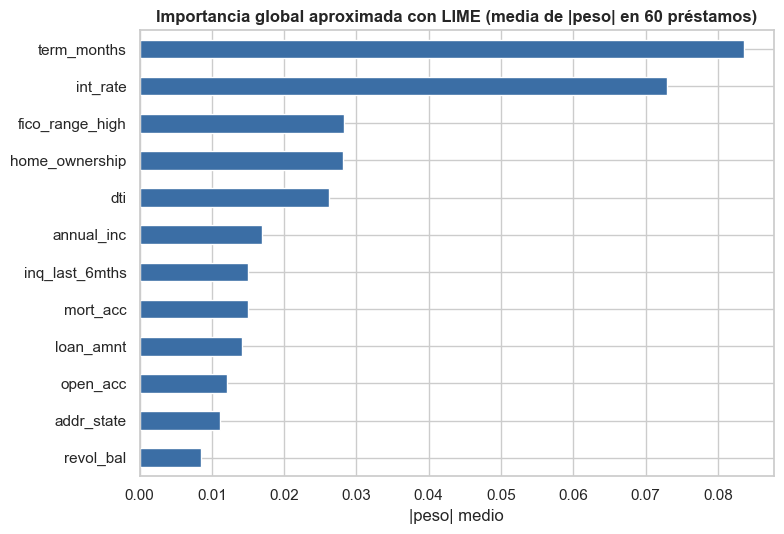

In [7]:
muestra = test.sample(60, random_state=lc.SEED).reset_index(drop=True)
acum = pd.Series(0.0, index=lc.FEATURES)
t0 = time.time()
for i in range(len(muestra)):
    e = adapter.explain(muestra.iloc[[i]], num_features=len(lc.FEATURES), num_samples=2000)
    for j, w in e.as_map()[1]:
        acum.iloc[j] += abs(w)
print(f"60 explicaciones en {time.time() - t0:.0f} s")
acum = (acum / len(muestra)).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5.5))
acum.head(12).iloc[::-1].plot.barh(ax=ax, color="#3b6ea5")
ax.set(title="Importancia global aproximada con LIME (media de |peso| en 60 préstamos)", xlabel="|peso| medio")
plt.tight_layout()
plt.show()

## 4.6 Los mismos préstamos con el modelo de PySpark

La sección 3.9 aplicó LIME **dentro de la sesión de Spark** al modelo de mayor AUC de PySpark entre los que
dan probabilidades, con **los mismos dos préstamos** y los mismos parámetros de LIME (5 000 muestras
perturbadas, 10 variables). Aquí se comparan las dos explicaciones.

Modelo de PySpark explicado: Gradient boosting


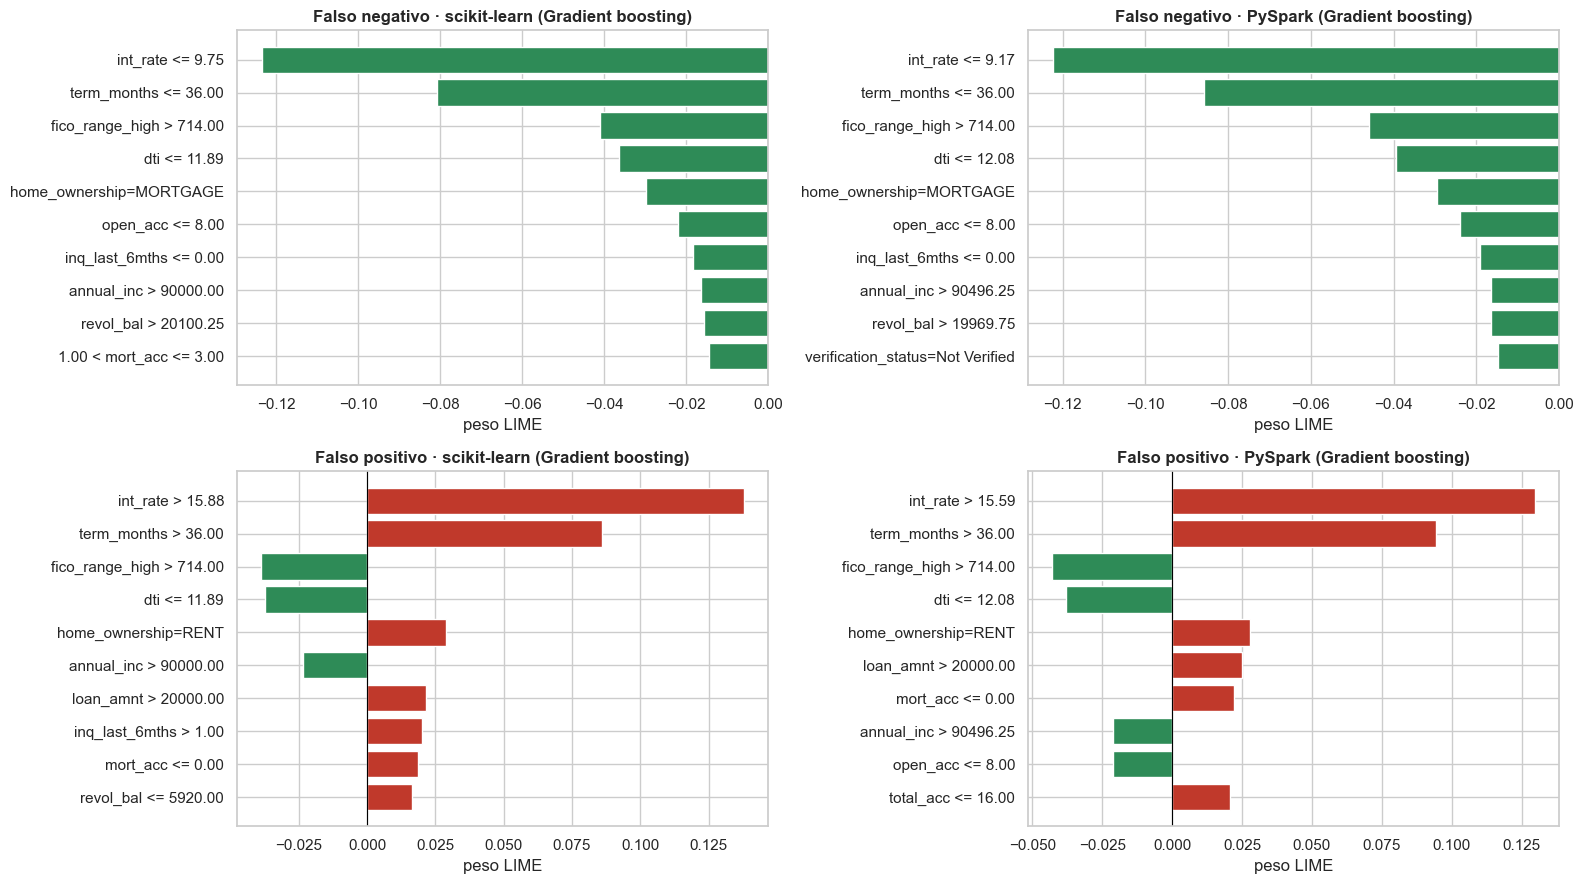

,variables en común (de 10),R² local scikit-learn,R² local PySpark,prob. scikit-learn,prob. PySpark,tiempo scikit-learn (s),tiempo PySpark (s)
instancia,,,,,,,
Falso negativo,9,0.5008,0.5100,0.0201,0.0221,0.0998,0.5591
Falso positivo,8,0.5842,0.5538,0.8256,0.8631,0.0713,0.5573


In [8]:
sp = json.loads((RESULTS / "lime_spark.json").read_text())
print(f"Modelo de PySpark explicado: {lm.NOMBRES[sp['modelo']]}")
fig, ax = plt.subplots(2, 2, figsize=(16, 9))
for fila_ax, (k, nombre) in zip(ax, (("FN", "Falso negativo"), ("FP", "Falso positivo"))):
    e_sk = explicaciones[nombre].as_list(label=1)[::-1]
    e_sp = sp["instancias"][k]["pesos"][::-1]
    for a, lista, titulo in ((fila_ax[0], e_sk, f"{nombre} · scikit-learn ({lm.NOMBRES[clave]})"),
                             (fila_ax[1], e_sp, f"{nombre} · PySpark ({lm.NOMBRES[sp['modelo']]})")):
        pesos = [w for _, w in lista]
        a.barh([n for n, _ in lista], pesos, color=["#c0392b" if w > 0 else "#2e8b57" for w in pesos])
        a.axvline(0, color="black", lw=0.8)
        a.set(title=titulo, xlabel="peso LIME")
plt.tight_layout()
plt.show()


def _vars(lista):
    """Nombres de las variables (sin la condición) de una explicación de LIME."""
    out = []
    for cond, _ in lista:
        for v in lc.FEATURES:
            if v in cond:
                out.append(v)
                break
    return out


coinc = []
for k, nombre in (("FN", "Falso negativo"), ("FP", "Falso positivo")):
    v_sk, v_sp = _vars(explicaciones[nombre].as_list(label=1)), _vars(sp["instancias"][k]["pesos"])
    coinc.append({"instancia": nombre, "variables en común (de 10)": len(set(v_sk) & set(v_sp)),
                  "R² local scikit-learn": explicaciones[nombre].score, "R² local PySpark": sp["instancias"][k]["r2_local"],
                  "prob. scikit-learn": ids[k]["p_sklearn"], "prob. PySpark": ids[k]["p_spark"],
                  "tiempo scikit-learn (s)": tiempos[nombre], "tiempo PySpark (s)": sp["instancias"][k]["tiempo_s"]})
display(pd.DataFrame(coinc).set_index("instancia"))

## 4.7 LIME y PySpark: qué cambia y qué limita

LIME **no es distribuido**: corre en la memoria de un solo proceso y necesita una función
`predict_proba` a la que llamar miles de veces. Con un modelo de PySpark eso significa:

1. **Cada llamada es un viaje a la JVM**: crear un DataFrame de Spark con las muestras perturbadas,
   aplicar el preprocesamiento y el modelo, y traer las probabilidades de vuelta. Es el caso más
   desfavorable para Spark (mucha latencia fija, poco cómputo por llamada). **Sin Apache Arrow esa
   latencia llegó a ≈ 7–8 minutos por llamada** (capítulo 3b).
2. **Datos de referencia locales**: LIME necesita una muestra de los datos en el driver para conocer las
   distribuciones. Con datos realmente masivos (que no caben en memoria) hay que recurrir a una
   **muestra** (aquí, 20 000 filas), lo que contradice el principio de no mover el conjunto de datos al *driver*.
3. **Perturbaciones sin correlaciones**: LIME muestrea cada variable por separado y puede crear préstamos
   imposibles (p. ej. tasa muy baja con FICO muy bajo), sobre los que el modelo nunca fue entrenado.
4. **Costo por instancia**: aunque en la sección 4.4 el orden de las variables no cambió entre semillas,
   LIME es aleatorio por diseño y hay que ejecutarlo para **cada** instancia; no escala a millones de
   préstamos.

En entornos distribuidos suelen preferirse explicaciones **específicas de árboles** (por ejemplo valores
SHAP para árboles; Lundberg *et al.*, 2020), que se calculan a partir de la estructura del propio
modelo, sin perturbar los datos.

In [9]:
res_sk = json.loads((RESULTS / "sk_resultados.json").read_text())
lat = pd.DataFrame({"scikit-learn": res_sk["latencia_predict_s"], "PySpark (con Arrow)": sp["latencia_predict_s"]})
lat["PySpark / scikit-learn"] = lat.iloc[:, 1] / lat.iloc[:, 0]
lat.index.name = "filas por llamada"
display(lat.style.format({c: "{:.4f}" if c != "PySpark / scikit-learn" else "{:.0f}×" for c in lat.columns}))
print(f"Cada explicación de LIME hace UNA llamada de 5 000 muestras: scikit-learn ≈ {lat.iloc[-1, 0]:.2f} s · PySpark ≈ {lat.iloc[-1, 1]:.2f} s "
      "por préstamo explicado (solo la predicción).")

,scikit-learn,PySpark (con Arrow),PySpark / scikit-learn
filas por llamada,,,
1,0.0002,0.2870,1188×
100,0.0006,0.2746,489×
5000,0.0135,0.5108,38×


Cada explicación de LIME hace UNA llamada de 5 000 muestras: scikit-learn ≈ 0.01 s · PySpark ≈ 0.51 s por préstamo explicado (solo la predicción).


# 5 · Comparación estadística de los modelos: DeLong, McNemar y bootstrap pareado

Los doce modelos (seis en scikit-learn y seis en PySpark) se evaluaron sobre **exactamente los mismos
269 062 préstamos de prueba**. Aquí se responde con pruebas estadísticas si las diferencias observadas
**entre entornos** (el mismo modelo en scikit-learn y en PySpark) y **entre modelos** (dentro de cada
entorno) son reales o compatibles con el azar del muestreo del conjunto de prueba.

| Prueba | Qué compara | Qué supone / limita |
|---|---|---|
| **DeLong pareado** (prueba principal) | AUC de dos modelos sobre las mismas observaciones, **incorporando la covarianza** entre las dos curvas ROC | Solo captura la variabilidad del **muestreo del conjunto de prueba**, no la del entrenamiento (semillas, pliegues); supone observaciones independientes; el AUC resume **todos** los umbrales |
| **McNemar** | Si dos clasificadores **aciertan y fallan con la misma frecuencia** en las mismas observaciones, con un **umbral fijo** | Trata todos los errores por igual (poco informativo con clase minoritaria); depende del umbral |
| **Bootstrap pareado** | Diferencias de AUC, **AUC-PR** y **F1** con los **mismos índices** remuestreados para ambos modelos (B = 2 000) | No requiere fórmula de varianza cerrada; también depende del umbral en F1 |

**Decisiones tomadas de antemano** (antes de mirar resultados):

* Nivel de significancia **α = 0.05** con corrección de **Holm** *dentro de cada familia* de comparaciones.
* **Margen de relevancia práctica: ΔAUC ≥ 0.005.** Con unos 270 000 préstamos de prueba, diferencias
  diminutas resultan "significativas"; el margen de 0.005 equivale a 0.01 en el índice de Gini, la
  unidad habitual en *credit scoring*, y es aproximadamente el doble del semiancho del IC95 de cada AUC
  (≈ 0.0024). Se fijó como convención antes del análisis. Se reporta por separado la **significancia
  estadística** y la **relevancia práctica**.
* **Umbral para McNemar y F1:** el que **maximiza F1 con las puntuaciones fuera de pliegue del
  entrenamiento** de cada modelo (capítulos 2 y 3), **sin usar el conjunto de prueba**.

In [1]:
import json
import platform
import sys
import time
import warnings
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import roc_auc_score

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_models as lm  # noqa: E402
from src import lc_stats as st  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS = Path("../resultados")
ALPHA, MARGEN, B, SEED = 0.05, 0.005, 2000, 42
print(f"Python {platform.python_version()} · α = {ALPHA} · margen de relevancia práctica = {MARGEN} · B = {B}")

Python 3.10.21 · α = 0.05 · margen de relevancia práctica = 0.005 · B = 2000


## 5.1 Puntuaciones de prueba de los doce modelos

Se cargan las puntuaciones continuas guardadas por los capítulos 2 y 3 (`predict_proba[:, 1]`, o el valor de
decisión en `LinearSVC`) y se verifica que **los `id` y las etiquetas coinciden** en los dos entornos.

In [2]:
sk = pd.read_parquet(RESULTS / "sk_scores_test.parquet")
S = {("sk", k): sk[k].to_numpy() for k in lm.CLAVES}
y = sk["y"].to_numpy()
for k in lm.CLAVES:
    p = pd.read_parquet(RESULTS / f"sp_scores_test_{k}.parquet")
    m = sk[["id", "y"]].merge(p, on="id", how="left", suffixes=("", "_sp"))
    assert len(p) == len(sk) and m["score"].notna().all() and (m["y"] == m["y_sp"]).all(), f"Los conjuntos de prueba difieren ({k})"
    S[("sp", k)] = m["score"].to_numpy()                       # alineado con el orden de `sk`
print(f"Observaciones de prueba: {len(y):,} · tasa de incumplimiento {y.mean():.4f} · ids y etiquetas idénticos en los 12 modelos: OK")
res_sk = json.loads((RESULTS / "sk_resultados.json").read_text())["modelos"]
res_sp = {k: json.loads((RESULTS / f"sp_modelo_{k}.json").read_text()) for k in lm.CLAVES}
UMBRAL = {("sk", k): res_sk[k]["umbral_f1"] for k in lm.CLAVES} | {("sp", k): res_sp[k]["umbral_f1"] for k in lm.CLAVES}
ENT = {"sk": "scikit-learn", "sp": "PySpark"}

Observaciones de prueba: 269,062 · tasa de incumplimiento 0.1996 · ids y etiquetas idénticos en los 12 modelos: OK


## 5.2 Validación de la implementación de DeLong

Se usa la **versión rápida** (Sun y Xu, 2014, O(n log n)), porque la directa (cuadrática) no es
viable con ≈ 270 000 observaciones. Antes de usarla a esa escala, se **valida primero con un conjunto
pequeño** frente a la versión directa. Aquí se compara `st.delong_fast` con `st.delong_direct` (que evalúa todos los pares
positivo–negativo) sobre submuestras de 2 000 observaciones, con tres pares de modelos: dos que
involucran al árbol de decisión (muchos **empates** en la puntuación, por tener pocas hojas) y uno de
regresión logística en ambos entornos (puntuación casi continua).

In [3]:
rng = np.random.default_rng(SEED)
val = []
for rep in range(3):
    ii = rng.choice(len(y), 2000, replace=False)
    for (a, b) in ((("sk", "DT"), ("sk", "RF")), (("sk", "LR"), ("sp", "LR")), (("sp", "DT"), ("sp", "GB"))):
        f, d = st.delong_fast(y[ii], S[a][ii], S[b][ii]), st.delong_direct(y[ii], S[a][ii], S[b][ii])
        val.append({"submuestra": rep, "par": f"{a[0]}-{a[1]} vs {b[0]}-{b[1]}", "AUC1 rápida": f["auc1"], "AUC1 directa": d["auc1"],
                    "ΔAUC rápida": f["delta"], "ΔAUC directa": d["delta"], "z rápida": f["z"], "z directa": d["z"],
                    "|Δ z|": abs(f["z"] - d["z"]), "|Δ p|": abs(f["p_value"] - d["p_value"])})
val = pd.DataFrame(val)
display(val.head(6).style.format("{:.6f}", subset=[c for c in val.columns if c not in ("submuestra", "par")]))
assert val["|Δ z|"].max() < 1e-6 and val["|Δ p|"].max() < 1e-6, "DeLong rápido difiere del directo"
# Nota sobre el umbral: con ΔAUC casi cero (z ≈ 0), el valor p es muy sensible a diferencias de z del
# orden de la precisión de punto flotante (~1e-10), porque la derivada de la cola normal es máxima en 0.
# Ese caso puntual puede acercarse a 1e-10 en |Δp| aunque ambas versiones coincidan en ~10 cifras
# significativas; por eso el umbral aquí es 1e-6 (siempre se cumplió con margen amplio, ver tabla).
ii = rng.choice(len(y), 5000, replace=False)
assert abs(st.delong_fast(y[ii], S[("sk", "RF")][ii], S[("sk", "LR")][ii])["auc1"] - roc_auc_score(y[ii], S[("sk", "RF")][ii])) < 1e-12
print(f"Diferencia máxima entre la versión rápida y la directa: |Δz| = {val['|Δ z|'].max():.2e}, |Δp| = {val['|Δ p|'].max():.2e} "
      "· el AUC coincide además con `roc_auc_score` de scikit-learn: OK")

,submuestra,par,AUC1 rápida,AUC1 directa,ΔAUC rápida,ΔAUC directa,z rápida,z directa,|Δ z|,|Δ p|
0,0,sk-DT vs sk-RF,0.695010,0.695010,-0.008391,-0.008391,-1.528447,-1.528447,0.000000,0.000000
1,0,sk-LR vs sp-LR,0.702219,0.702219,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0,sp-DT vs sp-GB,0.694476,0.694476,-0.011577,-0.011577,-1.946927,-1.946927,0.000000,0.000000
3,1,sk-DT vs sk-RF,0.693861,0.693861,-0.012275,-0.012275,-1.981047,-1.981047,0.000000,0.000000
4,1,sk-LR vs sp-LR,0.693786,0.693786,-0.000002,-0.000002,-0.316025,-0.316025,0.000000,0.000000
5,1,sp-DT vs sp-GB,0.690108,0.690108,-0.019279,-0.019279,-3.159409,-3.159409,0.000000,0.000000


Diferencia máxima entre la versión rápida y la directa: |Δz| = 3.33e-10, |Δp| = 2.53e-10 · el AUC coincide además con `roc_auc_score` de scikit-learn: OK


## 5.3 AUC de los doce modelos con su intervalo de confianza (DeLong)

In [4]:
filas = []
for (e, k), s in S.items():
    d = st.delong_fast(y, s, s + 0.0)
    filas.append({"entorno": ENT[e], "modelo": lm.NOMBRES[k], "AUC": d["auc1"], "IC95 inf": d["auc1_lo"], "IC95 sup": d["auc1_hi"],
                  "umbral (F1 OOF)": UMBRAL[(e, k)]})
aucs = pd.DataFrame(filas)
display(aucs.pivot(index="modelo", columns="entorno", values="AUC").loc[[lm.NOMBRES[k] for k in lm.CLAVES]])
display(aucs)
aucs.to_csv(RESULTS / "estadistica_auc_ic.csv", index=False)

entorno,PySpark,scikit-learn
modelo,,
Regresión logística,0.7095,0.7095
Árbol de decisión,0.7004,0.7022
Bosque aleatorio,0.7152,0.7164
Gradient boosting,0.7189,0.7196
SVM lineal,0.5985,0.4956
Naive Bayes,0.6883,0.6884


,entorno,modelo,AUC,IC95 inf,IC95 sup,umbral (F1 OOF)
0,scikit-learn,Regresión logística,0.7095,0.7071,0.7119,0.2042
1,scikit-learn,Árbol de decisión,0.7022,0.6998,0.7046,0.2042
2,scikit-learn,Bosque aleatorio,0.7164,0.7140,0.7187,0.2188
3,scikit-learn,Gradient boosting,0.7196,0.7173,0.7220,0.2236
4,scikit-learn,SVM lineal,0.4956,0.4928,0.4984,-1.0000
5,scikit-learn,Naive Bayes,0.6884,0.6859,0.6909,0.2139
6,PySpark,Regresión logística,0.7095,0.7071,0.7119,0.2061
7,PySpark,Árbol de decisión,0.7004,0.6980,0.7028,0.2061
8,PySpark,Bosque aleatorio,0.7152,0.7128,0.7175,0.2159
9,PySpark,Gradient boosting,0.7189,0.7166,0.7213,0.2159


## 5.4 DeLong entre entornos (6 comparaciones)

Para cada modelo: scikit-learn frente a PySpark. Se reporta ΔAUC = AUC(scikit-learn) − AUC(PySpark) con su
IC del 95 %, el estadístico z, el valor p bilateral y el valor p **ajustado por Holm** (6 comparaciones).

In [5]:
def tabla_delong(pares, etiqueta):
    filas = []
    for a, b in pares:
        d = st.delong_fast(y, S[a], S[b])
        filas.append({"comparación": etiqueta(a, b), "AUC 1": d["auc1"], "AUC 2": d["auc2"], "ΔAUC": d["delta"],
                      "IC95 inf": d["delta_lo"], "IC95 sup": d["delta_hi"], "z": d["z"], "p": d["p_value"],
                      "corr. AUC": d["corr_auc"], "_a": a, "_b": b})
    t = pd.DataFrame(filas)
    t["p Holm"] = st.holm(t["p"].to_numpy())
    t["significativa (Holm)"] = t["p Holm"] < ALPHA
    t["relevante (|Δ| ≥ margen)"] = t["ΔAUC"].abs() >= MARGEN
    return t


t0 = time.time()
famA = tabla_delong([(("sk", k), ("sp", k)) for k in lm.CLAVES], lambda a, b: lm.NOMBRES[a[1]])
display(famA.drop(columns=["_a", "_b"]).set_index("comparación"))
famA.drop(columns=["_a", "_b"]).to_csv(RESULTS / "estadistica_delong_entornos.csv", index=False)
print(f"({time.time() - t0:.0f} s)")

,AUC 1,AUC 2,ΔAUC,IC95 inf,IC95 sup,z,p,corr. AUC,p Holm,significativa (Holm),relevante (|Δ| ≥ margen)
comparación,,,,,,,,,,,
Regresión logística,0.7095,0.7095,0.0000,-0.0000,0.0000,0.7003,0.4837,1.0000,0.4837,False,False
Árbol de decisión,0.7022,0.7004,0.0018,0.0007,0.0029,3.2844,0.0010,0.8987,0.0031,True,False
Bosque aleatorio,0.7164,0.7152,0.0012,0.0008,0.0016,5.7287,0.0000,0.9848,0.0000,True,False
Gradient boosting,0.7196,0.7189,0.0007,0.0003,0.0011,3.1029,0.0019,0.9833,0.0038,True,False
SVM lineal,0.4956,0.5985,-0.1029,-0.1064,-0.0995,-57.7305,0.0000,0.2331,0.0000,True,True
Naive Bayes,0.6884,0.6883,0.0001,0.0001,0.0001,12.4026,0.0000,1.0000,0.0000,True,False


(1 s)


## 5.5 DeLong entre modelos, dentro de cada entorno (15 pares por entorno)

Todos los pares de los seis modelos, con Holm sobre los 15 valores p de cada entorno. Los mapas de calor
muestran ΔAUC (fila − columna) y el valor p ajustado.


scikit-learn: 15 de 15 pares con diferencia significativa tras Holm; 14 además relevantes (|ΔAUC| ≥ 0.005)


,AUC 1,AUC 2,ΔAUC,IC95 inf,IC95 sup,z,p,corr. AUC,p Holm,significativa (Holm),relevante (|Δ| ≥ margen)
comparación,,,,,,,,,,,
Regresión logística vs Árbol de decisión,0.7095,0.7022,0.0073,0.0061,0.0086,11.4404,0.0000,0.8631,0.0000,True,True
Regresión logística vs Bosque aleatorio,0.7095,0.7164,-0.0069,-0.0077,-0.0060,-15.5118,0.0000,0.9329,0.0000,True,True
Regresión logística vs Gradient boosting,0.7095,0.7196,-0.0101,-0.0110,-0.0093,-23.6505,0.0000,0.9369,0.0000,True,True
Regresión logística vs SVM lineal,0.7095,0.4956,0.2139,0.2103,0.2176,114.3085,0.0000,-0.0025,0.0000,True,True
Regresión logística vs Naive Bayes,0.7095,0.6884,0.0211,0.0199,0.0223,33.9965,0.0000,0.8757,0.0000,True,True
Árbol de decisión vs Bosque aleatorio,0.7022,0.7164,-0.0142,-0.0151,-0.0132,-28.5347,0.0000,0.9165,0.0000,True,True
Árbol de decisión vs Gradient boosting,0.7022,0.7196,-0.0174,-0.0184,-0.0165,-34.8680,0.0000,0.9150,0.0000,True,True
Árbol de decisión vs SVM lineal,0.7022,0.4956,0.2066,0.2029,0.2103,109.1867,0.0000,-0.0172,0.0000,True,True
Árbol de decisión vs Naive Bayes,0.7022,0.6884,0.0138,0.0122,0.0154,16.9237,0.0000,0.7862,0.0000,True,True



PySpark: 15 de 15 pares con diferencia significativa tras Holm; 14 además relevantes (|ΔAUC| ≥ 0.005)


,AUC 1,AUC 2,ΔAUC,IC95 inf,IC95 sup,z,p,corr. AUC,p Holm,significativa (Holm),relevante (|Δ| ≥ margen)
comparación,,,,,,,,,,,
Regresión logística vs Árbol de decisión,0.7095,0.7004,0.0091,0.0079,0.0104,14.4112,0.0000,0.8660,0.0000,True,True
Regresión logística vs Bosque aleatorio,0.7095,0.7152,-0.0057,-0.0065,-0.0048,-13.0298,0.0000,0.9355,0.0000,True,True
Regresión logística vs Gradient boosting,0.7095,0.7189,-0.0095,-0.0103,-0.0086,-20.8774,0.0000,0.9295,0.0000,True,True
Regresión logística vs SVM lineal,0.7095,0.5985,0.1110,0.1080,0.1140,72.4075,0.0000,0.3535,0.0000,True,True
Regresión logística vs Naive Bayes,0.7095,0.6883,0.0212,0.0200,0.0224,34.0814,0.0000,0.8751,0.0000,True,True
Árbol de decisión vs Bosque aleatorio,0.7004,0.7152,-0.0148,-0.0157,-0.0138,-30.5618,0.0000,0.9212,0.0000,True,True
Árbol de decisión vs Gradient boosting,0.7004,0.7189,-0.0186,-0.0195,-0.0176,-37.7281,0.0000,0.9180,0.0000,True,True
Árbol de decisión vs SVM lineal,0.7004,0.5985,0.1019,0.0988,0.1050,64.4697,0.0000,0.3186,0.0000,True,True
Árbol de decisión vs Naive Bayes,0.7004,0.6883,0.0121,0.0105,0.0137,15.0113,0.0000,0.7921,0.0000,True,True


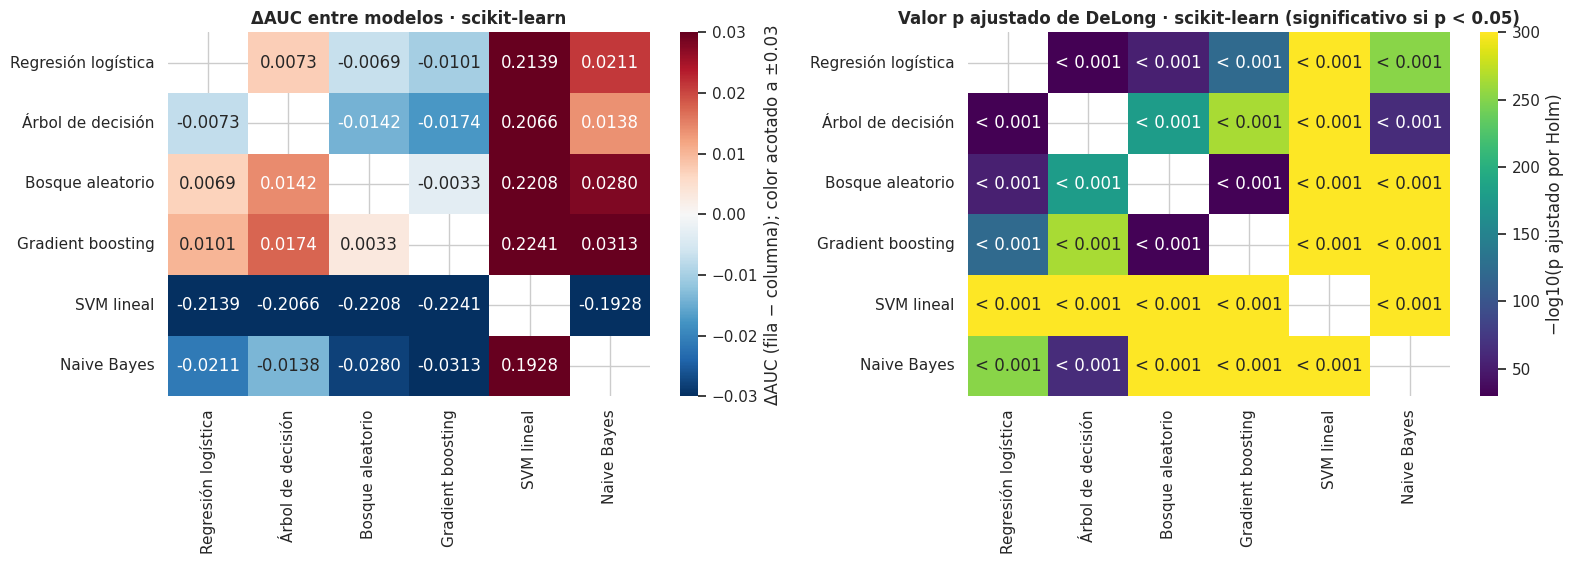

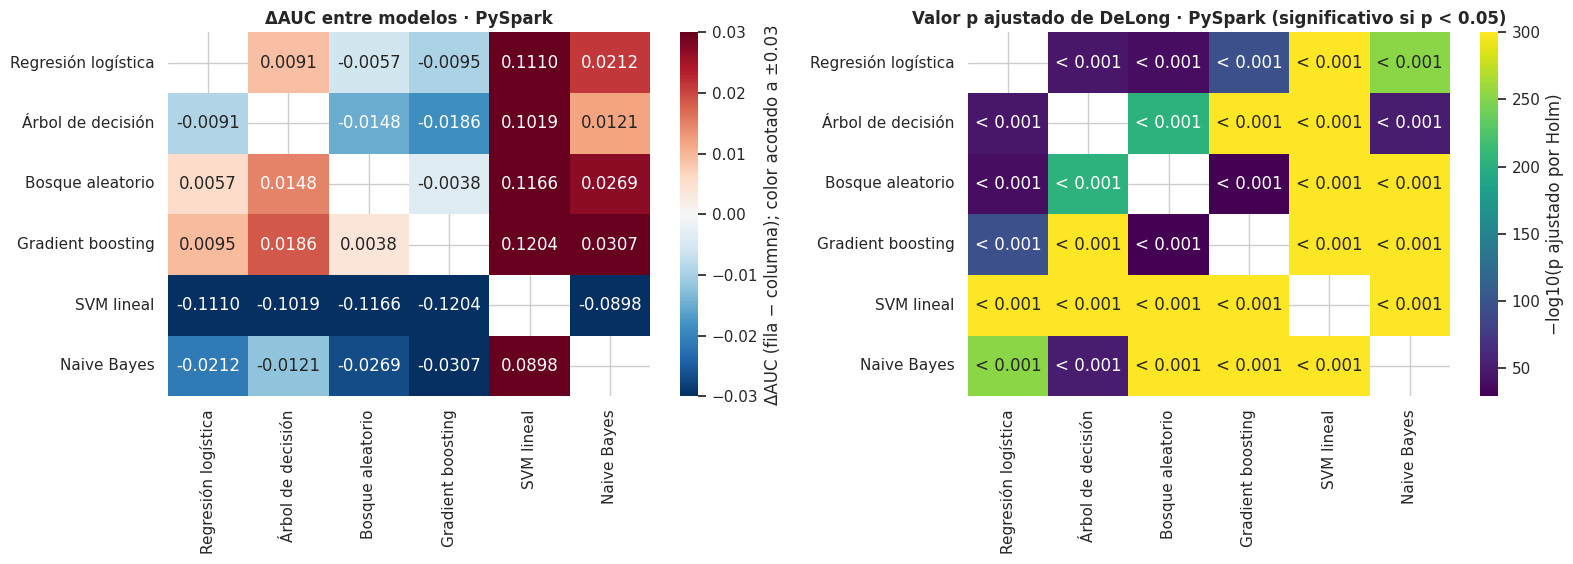

In [4]:
famB = {}
for e in ("sk", "sp"):
    famB[e] = tabla_delong([((e, a), (e, b)) for a, b in combinations(lm.CLAVES, 2)],
                           lambda a, b: f"{lm.NOMBRES[a[1]]} vs {lm.NOMBRES[b[1]]}")
    print(f"\n{ENT[e]}: {int(famB[e]['significativa (Holm)'].sum())} de 15 pares con diferencia significativa tras Holm; "
          f"{int((famB[e]['significativa (Holm)'] & famB[e]['relevante (|Δ| ≥ margen)']).sum())} además relevantes (|ΔAUC| ≥ {MARGEN})")
    famB[e].drop(columns=["_a", "_b"]).to_csv(RESULTS / f"estadistica_delong_modelos_{e}.csv", index=False)
    display(famB[e].drop(columns=["_a", "_b"]).set_index("comparación"))


def matrices(e):
    n = len(lm.CLAVES)
    D, P = np.full((n, n), np.nan), np.full((n, n), np.nan)
    for _, r in famB[e].iterrows():
        i, j = lm.CLAVES.index(r["_a"][1]), lm.CLAVES.index(r["_b"][1])
        D[i, j], D[j, i] = r["ΔAUC"], -r["ΔAUC"]
        P[i, j] = P[j, i] = r["p Holm"]
    return pd.DataFrame(D, index=[lm.NOMBRES[k] for k in lm.CLAVES], columns=[lm.NOMBRES[k] for k in lm.CLAVES]), \
        pd.DataFrame(P, index=[lm.NOMBRES[k] for k in lm.CLAVES], columns=[lm.NOMBRES[k] for k in lm.CLAVES])


for e in ("sk", "sp"):
    D, P = matrices(e)
    fig, ax = plt.subplots(1, 2, figsize=(16, 5.8))
    # escala de color acotada: sin ella, las diferencias de la SVM aplastan a todas las demás
    sns.heatmap(D, annot=True, fmt=".4f", cmap="RdBu_r", center=0, vmin=-0.03, vmax=0.03, ax=ax[0],
                cbar_kws={"label": "ΔAUC (fila − columna); color acotado a ±0.03"})
    ax[0].set_title(f"ΔAUC entre modelos · {ENT[e]}")
    # casi todos los p ajustados son < 0.001: se muestra −log10(p) para que el mapa sea informativo
    etiquetas = P.apply(lambda col: col.map(lambda v: "" if np.isnan(v) else ("< 0.001" if v < 0.001 else f"{v:.3f}")))
    sns.heatmap(-np.log10(P.clip(lower=1e-300)), annot=etiquetas, fmt="", cmap="viridis", ax=ax[1],
                cbar_kws={"label": "−log10(p ajustado por Holm)"})
    ax[1].set_title(f"Valor p ajustado de DeLong · {ENT[e]} (significativo si p < {ALPHA})")
    plt.tight_layout()
    plt.show()

## 5.6 McNemar y bootstrap pareado

Se aplican a: **(i)** las 6 comparaciones entre entornos y **(ii)** el par formado por los **dos modelos con
mayor AUC dentro de cada entorno** (2 comparaciones). Holm se aplica **dentro de cada familia** y por
prueba. Para McNemar se usa el umbral de cada modelo elegido con el entrenamiento (5.1). En el bootstrap
(B = 2 000, semilla fija, **mismos índices para ambos modelos**) se calculan ΔAUC, ΔAUC-PR y ΔF1; el valor p
es bilateral, `2 · min(P(Δ* ≤ 0), P(Δ* ≥ 0))`, y se considera evidencia de diferencia si el IC percentil del
95 % **no contiene el cero**. Con B = 2 000, un valor p de *bootstrap* igual a 0 debe leerse como
p < 0.0005. En las tablas, la familia `A` corresponde a las 6 comparaciones entre entornos y la familia
`B` a los 2 pares de mejores modelos.

In [7]:
top2 = {e: sorted(lm.CLAVES, key=lambda k: -roc_auc_score(y, S[(e, k)]))[:2] for e in ("sk", "sp")}
print("Dos modelos de mayor AUC:", {ENT[e]: [lm.NOMBRES[k] for k in v] for e, v in top2.items()})
comparaciones = ([("A", f"{lm.NOMBRES[k]}: scikit-learn vs PySpark", ("sk", k), ("sp", k)) for k in lm.CLAVES]
                 + [("B", f"{ENT[e]}: {lm.NOMBRES[top2[e][0]]} vs {lm.NOMBRES[top2[e][1]]}", (e, top2[e][0]), (e, top2[e][1])) for e in ("sk", "sp")])
filas = []
t0 = time.time()
for fam, nombre, a, b in comparaciones:
    dl = st.delong_fast(y, S[a], S[b])
    mc = st.mcnemar_test(y, (S[a] >= UMBRAL[a]).astype(int), (S[b] >= UMBRAL[b]).astype(int))
    bs = st.paired_bootstrap(y, S[a], S[b], UMBRAL[a], UMBRAL[b], B=B, seed=SEED)
    filas.append({"familia": fam, "comparación": nombre, "ΔAUC (DeLong)": dl["delta"], "p DeLong": dl["p_value"],
                  "b (acierta 1, falla 2)": mc["b"], "c (falla 1, acierta 2)": mc["c"], "p McNemar": mc["p_value"],
                  "ΔAUC boot": bs["auc"]["media"], "IC ΔAUC inf": bs["auc"]["lo"], "IC ΔAUC sup": bs["auc"]["hi"], "p boot AUC": bs["auc"]["p_value"],
                  "ΔAUC-PR boot": bs["auc_pr"]["media"], "IC PR inf": bs["auc_pr"]["lo"], "IC PR sup": bs["auc_pr"]["hi"], "p boot PR": bs["auc_pr"]["p_value"],
                  "ΔF1 boot": bs["f1"]["media"], "IC F1 inf": bs["f1"]["lo"], "IC F1 sup": bs["f1"]["hi"], "p boot F1": bs["f1"]["p_value"]})
    print(f"  {nombre}: listo ({time.time() - t0:.0f} s)", flush=True)
comp = pd.DataFrame(filas)
for fam in ("A", "B"):
    idx = comp["familia"] == fam
    for col in ("p DeLong", "p McNemar", "p boot AUC", "p boot PR", "p boot F1"):
        comp.loc[idx, col + " Holm"] = st.holm(comp.loc[idx, col].to_numpy())
comp.to_csv(RESULTS / "estadistica_mcnemar_bootstrap.csv", index=False)

Dos modelos de mayor AUC: {'scikit-learn': ['Gradient boosting', 'Bosque aleatorio'], 'PySpark': ['Gradient boosting', 'Bosque aleatorio']}


  Regresión logística: scikit-learn vs PySpark: listo (181 s)


  Árbol de decisión: scikit-learn vs PySpark: listo (334 s)


  Bosque aleatorio: scikit-learn vs PySpark: listo (511 s)


  Gradient boosting: scikit-learn vs PySpark: listo (689 s)


  SVM lineal: scikit-learn vs PySpark: listo (854 s)


  Naive Bayes: scikit-learn vs PySpark: listo (1032 s)


  scikit-learn: Gradient boosting vs Bosque aleatorio: listo (1209 s)


  PySpark: Gradient boosting vs Bosque aleatorio: listo (1388 s)


### Tabla resumen de las tres pruebas

`sig.` indica significancia tras Holm (p ajustado < 0.05); en el bootstrap, además, se muestra si el IC
excluye el cero. `relevante` = |ΔAUC| ≥ 0.005.

In [8]:
res = pd.DataFrame({
    "familia": comp["familia"], "comparación": comp["comparación"], "ΔAUC": comp["ΔAUC (DeLong)"],
    "DeLong p Holm": comp["p DeLong Holm"], "DeLong sig.": comp["p DeLong Holm"] < ALPHA,
    "McNemar b / c": comp["b (acierta 1, falla 2)"].astype(int).astype(str) + " / " + comp["c (falla 1, acierta 2)"].astype(int).astype(str),
    "McNemar p Holm": comp["p McNemar Holm"], "McNemar sig.": comp["p McNemar Holm"] < ALPHA,
    "boot ΔAUC [IC95]": comp.apply(lambda r: f"{r['ΔAUC boot']:+.4f} [{r['IC ΔAUC inf']:+.4f}, {r['IC ΔAUC sup']:+.4f}]", axis=1),
    "boot AUC sig.": ~((comp["IC ΔAUC inf"] <= 0) & (comp["IC ΔAUC sup"] >= 0)),
    "boot ΔAUC-PR [IC95]": comp.apply(lambda r: f"{r['ΔAUC-PR boot']:+.4f} [{r['IC PR inf']:+.4f}, {r['IC PR sup']:+.4f}]", axis=1),
    "boot PR sig.": ~((comp["IC PR inf"] <= 0) & (comp["IC PR sup"] >= 0)),
    "boot ΔF1 [IC95]": comp.apply(lambda r: f"{r['ΔF1 boot']:+.4f} [{r['IC F1 inf']:+.4f}, {r['IC F1 sup']:+.4f}]", axis=1),
    "boot F1 sig.": ~((comp["IC F1 inf"] <= 0) & (comp["IC F1 sup"] >= 0)),
    "relevante": comp["ΔAUC (DeLong)"].abs() >= MARGEN}).set_index(["familia", "comparación"])
display(res)
res.to_csv(RESULTS / "estadistica_resumen_tres_pruebas.csv")
# concordancia DeLong vs bootstrap sobre el AUC
conc = (res["DeLong sig."] == res["boot AUC sig."])
print(f"DeLong y bootstrap pareado coinciden en la significancia del AUC en {int(conc.sum())} de {len(conc)} comparaciones.")
print(f"DeLong y McNemar coinciden en {int((res['DeLong sig.'] == res['McNemar sig.']).sum())} de {len(res)}.")

ΔAUC  DeLong p Holm  DeLong sig.   McNemar b / c  McNemar p Holm  McNemar sig.            boot ΔAUC [IC95]  boot AUC sig.         boot ΔAUC-PR [IC95]  \
familia comparación                                                                                                                                                                                                   
A       Regresión logística: scikit-learn vs PySpark        0.0000         0.4837        False      318 / 1237          0.0000          True  +0.0000 [-0.0000, +0.0000]          False  -0.0000 [-0.0000, +0.0000]   
        Árbol de decisión: scikit-learn vs PySpark          0.0018         0.0031         True   15722 / 15386          0.0575         False  +0.0018 [+0.0007, +0.0029]           True  +0.0031 [+0.0012, +0.0051]   
        Bosque aleatorio: scikit-learn vs PySpark           0.0012         0.0000         True     6176 / 5475          0.0000          True  +0.0012 [+0.0008, +0.0016]           True  +0.0007 [-0.0001, +0.0015]   
        Gradient boosting: scikit-learn vs PySpark          0.0007         0.0038         True     8220 / 5379          0.0000          True  +0.0007 [+0.0002, +0.0011]           True  +0.0013 [+0.0003, +0.0022]   
        SVM lineal: scikit-learn vs PySpark                -0.1029         0.0000         True  32540 / 167409          0.0000          True  -0.1029 [-0.1064, -0.0995]           True  -0.0818 [-0.0848, -0.0789]   
        Naive Bayes: scikit-learn vs PySpark                0.0001         0.0000         True      318 / 1192          0.0000          True  +0.0001 [+0.0001, +0.0001]           True  +0.0001 [+0.0001, +0.0001]   
B       scikit-learn: Gradient boosting vs Bosque aleat...  0.0033         0.0000         True     9564 / 6360          0.0000          True  +0.0033 [+0.0028, +0.0038]           True  +0.0054 [+0.0043, +0.0065]   
        PySpark: Gradient boosting vs Bosque aleatorio      0.0038         0.0000         True    10189 / 9125          0.0000          True  +0.0038 [+0.0031, +0.0044]           True  +0.0048 [+0.0035, +0.0061]   

                                                            boot PR sig.             boot ΔF1 [IC95]  boot F1 sig.  relevante  
familia comparación                                                                                                            
A       Regresión logística: scikit-learn vs PySpark               False  -0.0002 [-0.0006, +0.0002]         False      False  
        Árbol de decisión: scikit-learn vs PySpark                  True  -0.0007 [-0.0024, +0.0011]         False      False  
        Bosque aleatorio: scikit-learn vs PySpark                  False  +0.0012 [+0.0001, +0.0023]          True      False  
        Gradient boosting: scikit-learn vs PySpark                  True  +0.0008 [-0.0006, +0.0020]         False      False  
        SVM lineal: scikit-learn vs PySpark                         True  -0.0117 [-0.0149, -0.0084]          True       True  
        Naive Bayes: scikit-learn vs PySpark                        True  +0.0000 [-0.0004, +0.0004]         False      False  
B       scikit-learn: Gradient boosting vs Bosque aleat...          True  +0.0028 [+0.0014, +0.0041]          True      False  
        PySpark: Gradient boosting vs Bosque aleatorio              True  +0.0032 [+0.0017, +0.0046]          True      False

DeLong y bootstrap pareado coinciden en la significancia del AUC en 8 de 8 comparaciones.
DeLong y McNemar coinciden en 6 de 8.


## 5.7 ¿Coinciden las tres pruebas? Lectura de los resultados

(La lectura completa, con cifras, está en la Discusión; aquí se listan las **discrepancias**.)

In [9]:
disc = res[(res["DeLong sig."] != res["McNemar sig."]) | (res["DeLong sig."] != res["boot AUC sig."]) | (res["DeLong sig."] != res["boot F1 sig."])]
if len(disc):
    print("Comparaciones donde las pruebas NO coinciden en significancia:")
    display(disc[["ΔAUC", "DeLong p Holm", "DeLong sig.", "McNemar p Holm", "McNemar sig.", "boot AUC sig.", "boot F1 sig.", "boot PR sig."]])
else:
    print("Las tres pruebas coinciden en todas las comparaciones.")

Comparaciones donde las pruebas NO coinciden en significancia:


ΔAUC  DeLong p Holm  DeLong sig.  McNemar p Holm  McNemar sig.  boot AUC sig.  boot F1 sig.  boot PR sig.
familia comparación                                                                                                                                             
A       Regresión logística: scikit-learn vs PySpark 0.0000         0.4837        False          0.0000          True          False         False         False
        Árbol de decisión: scikit-learn vs PySpark   0.0018         0.0031         True          0.0575         False           True         False          True
        Gradient boosting: scikit-learn vs PySpark   0.0007         0.0038         True          0.0000          True           True         False          True
        Naive Bayes: scikit-learn vs PySpark         0.0001         0.0000         True          0.0000          True           True         False          True

## 5.8 Limitaciones de la prueba de DeLong en este diseño (y cómo las complementan las otras dos)

1. **Solo mide la incertidumbre del muestreo del conjunto de prueba.** No incluye la variabilidad debida al
   **entrenamiento**: otra semilla, otros pliegues o un modelo estocástico (bosque, *boosting*) darían
   modelos algo distintos. Dos modelos con AUC casi iguales pueden invertir su orden con otra semilla.
2. **Supone observaciones independientes.** Préstamos de la misma época o del mismo estado comparten
   contexto económico; la independencia es una aproximación.
3. **El AUC resume todos los umbrales.** Puede no reflejar el desempeño en el **umbral operativo**. Por eso
   se complementa con **McNemar** (decisiones concretas con un umbral fijo) y con el bootstrap de **AUC-PR** y
   **F1**, más relevantes cuando la clase de incumplimiento es minoritaria (≈ 20 %).
4. **McNemar** trata todos los errores por igual (un falso negativo y un falso positivo pesan lo mismo) y
   depende del umbral, que aquí se eligió con el entrenamiento.
5. **Comparaciones múltiples:** con 6 + 15 + 15 comparaciones por familia, sin corrección habría falsos
   positivos; se aplica Holm dentro de cada familia.
6. **Significancia no es relevancia:** con 269 062 observaciones un ΔAUC de 0.001 puede tener p ≈ 10⁻⁸. Por
   eso se fijó de antemano el margen de 0.005.

# 6 · Comparación de resultados: métricas, tiempos y volumen

Cada par de modelos (scikit-learn y PySpark) comparte **la misma familia de modelos** (los optimizadores y
la forma de elegir los cortes difieren entre motores), **espacios de búsqueda equivalentes**, **3 pliegues
idénticos**, **las mismas variables** y **la misma partición** entrenamiento/prueba. Todos se entrenaron en
**la misma máquina**, **uno a la vez** y sin otros procesos pesados durante las mediciones de tiempo. La
comparación **estadística** (¿son reales las diferencias?) está en el capítulo 5; aquí se resumen métricas
y tiempos.

**Máquina:** Intel Core i5-13420H (8 núcleos, 12 hilos lógicos), 16 GB de RAM, Windows 11. Spark en modo local
(`local[*]`) con la configuración del capítulo 3.

In [1]:
import json
import platform
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score, roc_auc_score, roc_curve

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_models as lm  # noqa: E402
from src import lc_utils as lc  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS = Path("../resultados")
sk = json.loads((RESULTS / "sk_resultados.json").read_text())
sp = json.loads((RESULTS / "sp_resultados.json").read_text())
R_SK, R_SP = sk["modelos"], {k: json.loads((RESULTS / f"sp_modelo_{k}.json").read_text()) for k in lm.CLAVES}
ENT = {"sk": "scikit-learn", "sp": "PySpark"}
print(f"Equipo de los experimentos: Spark {sp['spark_version']} · {sk['hilos']} hilos lógicos · RAM {sk['ram_gb']:.1f} GB · heap JVM {sp['heap_jvm_gb']:.1f} GB")

Equipo de los experimentos: Spark 3.5.9 · 12 hilos lógicos · RAM 16.9 GB · heap JVM 8.6 GB


## 6.1 Métricas de los seis modelos en los dos entornos

Todas sobre el **mismo conjunto de prueba**. Las métricas con umbral (exactitud, precisión, sensibilidad y F1) usan
el umbral elegido **con el entrenamiento** de cada modelo (F1 sobre puntuaciones fuera de pliegue).

In [2]:
a, b = pd.read_parquet(RESULTS / "sk_scores_test.parquet"), None
S, y = {}, a["y"].to_numpy()
for k in lm.CLAVES:
    S[("sk", k)] = a[k].to_numpy()
    p = pd.read_parquet(RESULTS / f"sp_scores_test_{k}.parquet")
    S[("sp", k)] = a[["id"]].merge(p, on="id", how="left")["score"].to_numpy()
UMB = {("sk", k): R_SK[k]["umbral_f1"] for k in lm.CLAVES} | {("sp", k): R_SP[k]["umbral_f1"] for k in lm.CLAVES}
filas = []
for (e, k), s in S.items():
    mt = lc.threshold_metrics(y, s, UMB[(e, k)])
    filas.append({"modelo": lm.NOMBRES[k], "entorno": ENT[e], "ROC AUC": roc_auc_score(y, s), "AUC-PR": average_precision_score(y, s),
                  "accuracy": mt["accuracy"], "precision": mt["precision"], "recall": mt["recall"], "f1": mt["f1"], "umbral": mt["umbral"]})
tab = pd.DataFrame(filas)
orden = [lm.NOMBRES[k] for k in lm.CLAVES]
piv = tab.pivot(index="modelo", columns="entorno", values=["ROC AUC", "AUC-PR", "accuracy", "precision", "recall", "f1"]).loc[orden]
display(piv.swaplevel(axis=1).sort_index(axis=1, level=0, sort_remaining=False))
tab.to_csv(RESULTS / "comparacion_metricas.csv", index=False)
dif = (piv["ROC AUC"]["scikit-learn"] - piv["ROC AUC"]["PySpark"]).rename("ΔAUC (scikit-learn − PySpark)")
display(dif.to_frame())

entorno             PySpark                                         scikit-learn                                        
                    ROC AUC AUC-PR accuracy precision recall     f1      ROC AUC AUC-PR accuracy precision recall     f1
modelo                                                                                                                  
Regresión logística  0.7095 0.3700   0.6699    0.3274 0.6200 0.4285       0.7095 0.3700   0.6665    0.3256 0.6259 0.4283
Árbol de decisión    0.7004 0.3564   0.6497    0.3140 0.6367 0.4205       0.7022 0.3594   0.6510    0.3142 0.6329 0.4199
Bosque aleatorio     0.7152 0.3815   0.6759    0.3324 0.6187 0.4325       0.7164 0.3821   0.6785    0.3345 0.6168 0.4337
Gradient boosting    0.7189 0.3863   0.6798    0.3361 0.6194 0.4358       0.7196 0.3875   0.6904    0.3428 0.6009 0.4366
SVM lineal           0.5985 0.2854   0.7032    0.3077 0.3891 0.3436       0.4956 0.2036   0.2020    0.1993 0.9936 0.3320
Naive Bayes          0.6883 0.3479   0.6505    0.3115 0.6200 0.4146       0.6884 0.3480   0.6473    0.3100 0.6259 0.4147

,ΔAUC (scikit-learn − PySpark)
modelo,
Regresión logística,0.0000
Árbol de decisión,0.0018
Bosque aleatorio,0.0012
Gradient boosting,0.0007
SVM lineal,-0.1029
Naive Bayes,0.0001


**¿Son reales estas diferencias?** La prueba se hace en el capítulo 5 (DeLong pareado, McNemar y
*bootstrap*, con corrección de Holm); aquí se reproducen esas tres columnas junto al ΔAUC de cada modelo.

In [3]:
est = pd.read_csv(RESULTS / "estadistica_resumen_tres_pruebas.csv")
est_a = est[est["familia"] == "A"].copy()
est_a["modelo"] = est_a["comparación"].str.split(":").str[0]
est_a = est_a.set_index("modelo").loc[orden]
resumen_dif = pd.DataFrame({
    "ΔAUC (scikit-learn − PySpark)": dif,
    "ΔAUC bootstrap [IC95]": est_a["boot ΔAUC [IC95]"],
    "p DeLong (Holm)": est_a["DeLong p Holm"],
    "p McNemar (Holm)": est_a["McNemar p Holm"],
    "relevante (|ΔAUC| ≥ 0.005)": est_a["relevante"],
})
display(resumen_dif.style.format({"ΔAUC (scikit-learn − PySpark)": "{:+.4f}", "p DeLong (Holm)": "{:.2e}", "p McNemar (Holm)": "{:.2e}"}))

,ΔAUC (scikit-learn − PySpark),ΔAUC bootstrap [IC95],p DeLong (Holm),p McNemar (Holm),relevante (|ΔAUC| ≥ 0.005)
modelo,,,,,
Regresión logística,+0.0000,"+0.0000 [-0.0000, +0.0000]",4.84e-01,2.85e-119,False
Árbol de decisión,+0.0018,"+0.0018 [+0.0007, +0.0029]",3.07e-03,5.75e-02,False
Bosque aleatorio,+0.0012,"+0.0012 [+0.0008, +0.0016]",4.05e-08,1.77e-10,False
Gradient boosting,+0.0007,"+0.0007 [+0.0002, +0.0011]",3.83e-03,2.65e-130,False
SVM lineal,-0.1029,"-0.1029 [-0.1064, -0.0995]",0.00e+00,0.00e+00,True
Naive Bayes,+0.0001,"+0.0001 [+0.0001, +0.0001]",1.27e-34,2.68e-111,False


## 6.2 Curvas ROC y precisión–recall (un gráfico por entorno, con los seis modelos)

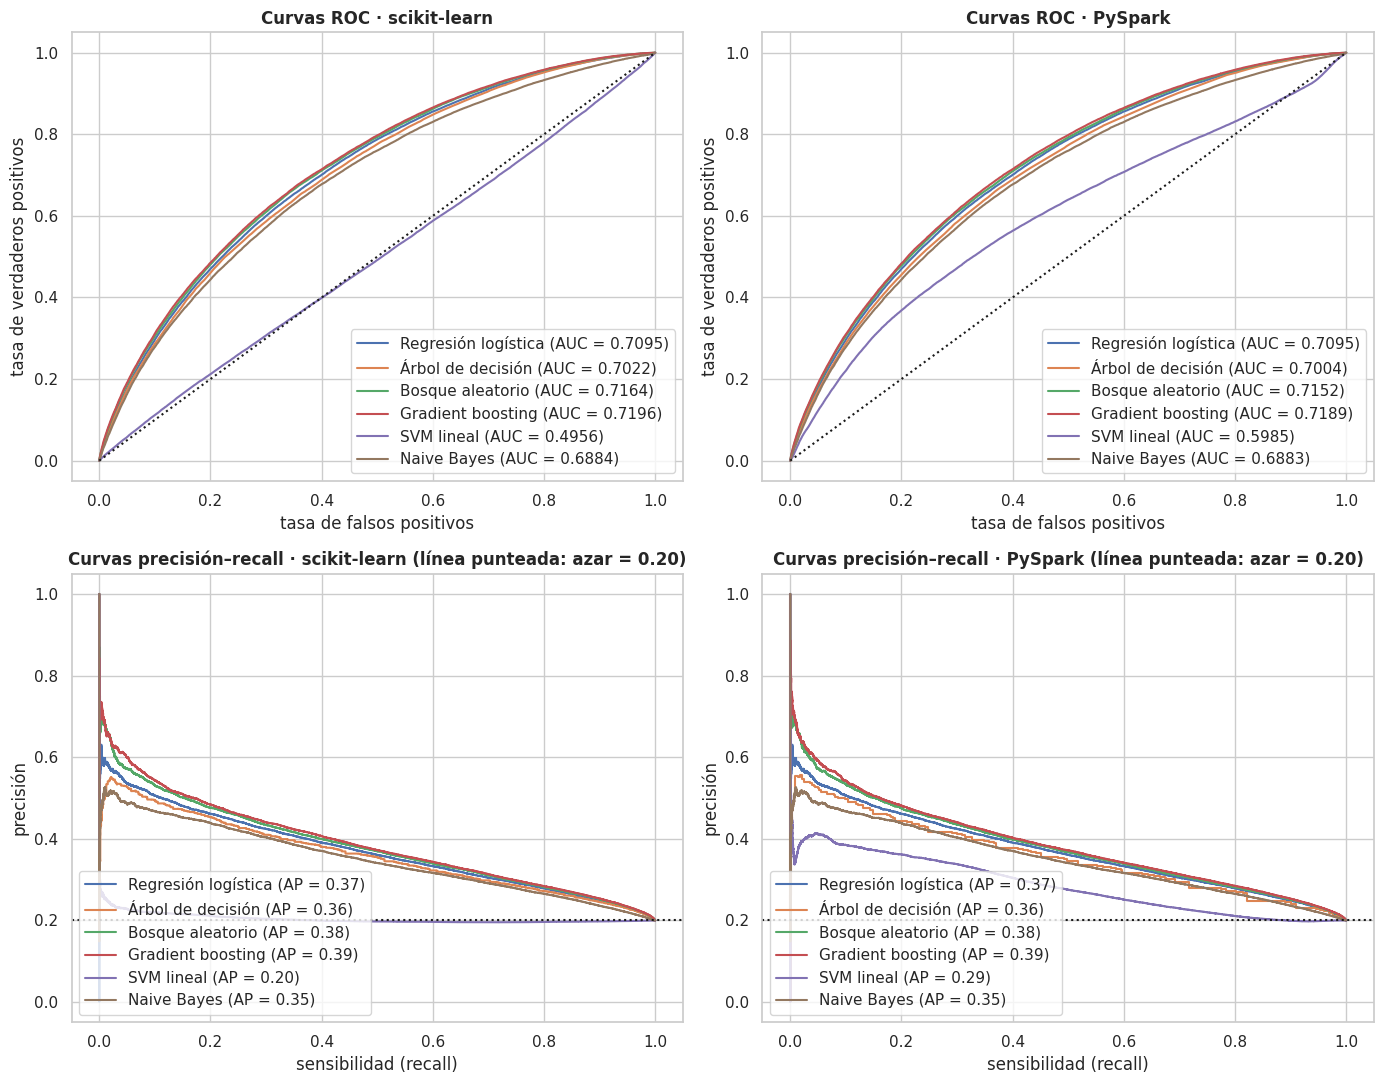

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(14, 11))
for j, e in enumerate(("sk", "sp")):
    for k in lm.CLAVES:
        fpr, tpr, _ = roc_curve(y, S[(e, k)])
        ax[0, j].plot(fpr, tpr, label=f"{lm.NOMBRES[k]} (AUC = {roc_auc_score(y, S[(e, k)]):.4f})")
        PrecisionRecallDisplay.from_predictions(y, S[(e, k)], name=lm.NOMBRES[k], ax=ax[1, j])
    ax[0, j].plot([0, 1], [0, 1], "k:")
    ax[0, j].set(xlabel="tasa de falsos positivos", ylabel="tasa de verdaderos positivos")
    ax[0, j].legend(loc="lower right")
    ax[0, j].set_title(f"Curvas ROC · {ENT[e]}")
    ax[1, j].set(xlabel="sensibilidad (recall)", ylabel="precisión")
    ax[1, j].axhline(y.mean(), color="k", ls=":")
    ax[1, j].set_title(f"Curvas precisión–recall · {ENT[e]} (línea punteada: azar = {y.mean():.2f})")
plt.tight_layout()
plt.show()

## 6.3 Tiempos de cómputo por modelo y por entorno

Se comparan las etapas equivalentes. **La "carga" y el "preprocesamiento" se comparan juntos**: Spark lee de
forma perezosa y descarta las columnas que no usa, así que su tiempo de "carga" aislado no es comparable con el
de pandas (que convierte las columnas a memoria). Para scikit-learn la fila suma leer las 24 columnas
necesarias, construir variables, codificar y escalar; para Spark incluye leer, construir variables, unir con la
partición, ajustar los transformadores (incluido el escalador) y **cachear**. El arranque de la sesión de Spark
y la **transferencia** de `id`, `default` y puntuación al driver se muestran aparte.

entorno,PySpark,scikit-learn,PySpark / scikit-learn
modelo,,,
Regresión logística,"3,800.2",14.8,257.0×
Árbol de decisión,"3,867.4",59.4,65.1×
Bosque aleatorio,"21,184.1",843.2,25.1×
Gradient boosting,"36,421.5","3,268.0",11.1×
SVM lineal,"12,956.0",623.9,20.8×
Naive Bayes,"2,562.3",5.4,477.9×
TOTAL seis modelos,"4,814.6","80,791.5",16.8×


Preprocesamiento (carga + variables + codificación + escalado): scikit-learn 43 s · PySpark 323 s (arranque de la sesión de Spark aparte: 24 s)


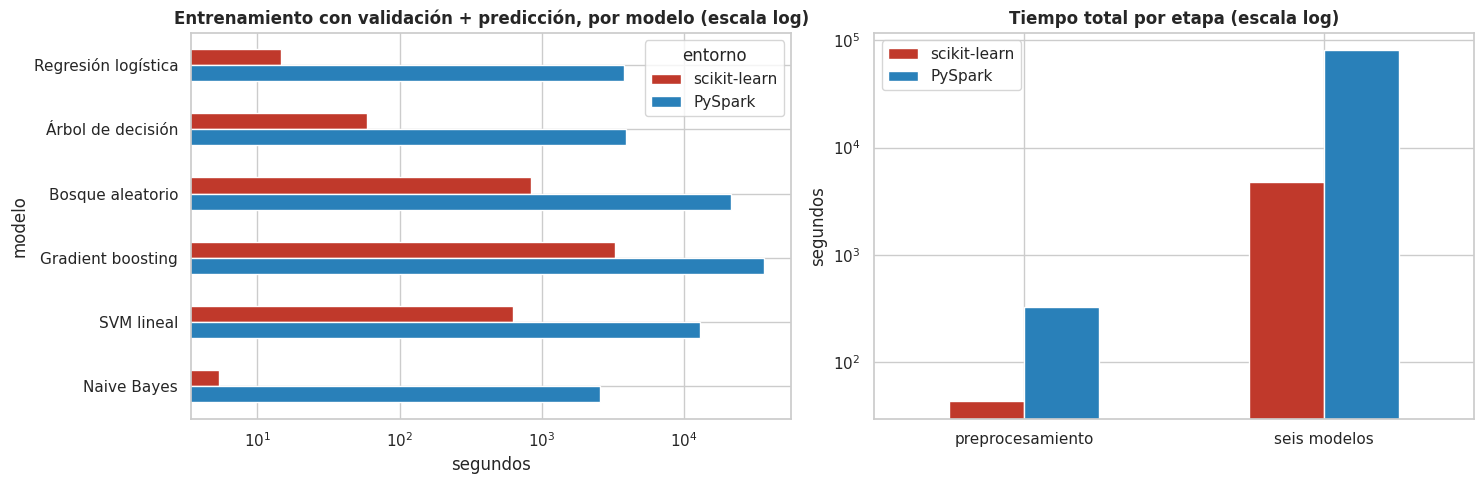

TOTAL (preprocesamiento + seis modelos): scikit-learn 81.0 min · PySpark 1,351.9 min · razón 16.7×


In [5]:
t_prep_sk = sk["tiempos_comunes_s"]["carga_csv"] + sk["tiempos_comunes_s"]["features"] + sk["tiempos_comunes_s"]["preprocesamiento"]
t_prep_sp = sp["tiempos_s"]["preprocesamiento"]
filas = []
for k in lm.CLAVES:
    for e, r in (("sk", R_SK[k]), ("sp", R_SP[k])):
        filas.append({"modelo": lm.NOMBRES[k], "entorno": ENT[e], "entrenamiento con validación (s)": r["t_entrenamiento_con_cv_s"],
                      "predicción test (s)": r["t_prediccion_s"], "umbral OOF (s)": r["t_oof_umbral_s"],
                      "transferencia al driver (s)": r.get("t_transferencia_s", np.nan)})
tiempos = pd.DataFrame(filas)
tiempos["entrenamiento + predicción (s)"] = tiempos["entrenamiento con validación (s)"] + tiempos["predicción test (s)"]
tt = tiempos.pivot(index="modelo", columns="entorno", values="entrenamiento + predicción (s)").loc[orden]
tt["PySpark / scikit-learn"] = tt["PySpark"] / tt["scikit-learn"]
tt.loc["TOTAL seis modelos"] = [tt["scikit-learn"].sum(), tt["PySpark"].sum(), tt["PySpark"].sum() / tt["scikit-learn"].sum()]
display(tt.style.format({"scikit-learn": "{:,.1f}", "PySpark": "{:,.1f}", "PySpark / scikit-learn": "{:.1f}×"}))
det = tiempos.set_index(["modelo", "entorno"])
display(det.style.format("{:,.1f}"))
print(f"Preprocesamiento (carga + variables + codificación + escalado): scikit-learn {t_prep_sk:.0f} s · PySpark {t_prep_sp:.0f} s "
      f"(arranque de la sesión de Spark aparte: {sp['tiempos_s'].get('arranque_sesion', float('nan')):.0f} s)")
tiempos.to_csv(RESULTS / "comparacion_tiempos.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
piv_t = tiempos.pivot(index="modelo", columns="entorno", values="entrenamiento + predicción (s)").loc[orden]
piv_t[["scikit-learn", "PySpark"]].plot.barh(ax=ax[0], color=["#c0392b", "#2980b9"], logx=True)   # mismo color por entorno en ambos paneles
ax[0].set(title="Entrenamiento con validación + predicción, por modelo (escala log)", xlabel="segundos")
ax[0].invert_yaxis()
tot = pd.DataFrame({"scikit-learn": [t_prep_sk, piv_t["scikit-learn"].sum()], "PySpark": [t_prep_sp, piv_t["PySpark"].sum()]},
                   index=["preprocesamiento", "seis modelos"])
tot.plot.bar(ax=ax[1], color=["#c0392b", "#2980b9"], logy=True, rot=0)
ax[1].set(title="Tiempo total por etapa (escala log)", ylabel="segundos")
plt.tight_layout()
plt.show()
TOT_SK, TOT_SP = t_prep_sk + piv_t["scikit-learn"].sum(), t_prep_sp + piv_t["PySpark"].sum()
print(f"TOTAL (preprocesamiento + seis modelos): scikit-learn {TOT_SK / 60:,.1f} min · PySpark {TOT_SP / 60:,.1f} min · razón {TOT_SP / TOT_SK:.1f}×")

## 6.4 ¿Desde qué volumen de datos cambia el ganador en velocidad?

Se ajustó **un bosque fijo** (50 árboles, profundidad 10) con subconjuntos crecientes del entrenamiento en
scikit-learn y en PySpark (con las 400 particiones de la sesión y con una variante de 12 particiones, capítulos
3b y 3c). Es un *benchmark* de tiempos, no el modelo final.

,filas_train,sk,auc_sk,sp400,auc_sp400,sp12,Spark(400) / sklearn,Spark(12) / sklearn
0,"10,000",0.3,0.7012,161.0,0.7003,11.9,625.0×,46.3×
1,"50,000",0.7,0.7086,172.2,0.7076,13.3,262.0×,20.2×
2,"100,000",1.2,0.7101,179.2,0.7092,16.4,148.6×,13.6×
3,"250,000",3.3,0.7113,201.5,0.7094,27.3,61.1×,8.3×
4,"500,000",6.9,0.7114,219.2,0.7089,40.4,31.8×,5.9×
5,"1,076,248",16.2,0.7114,257.6,0.7084,69.4,15.9×,4.3×


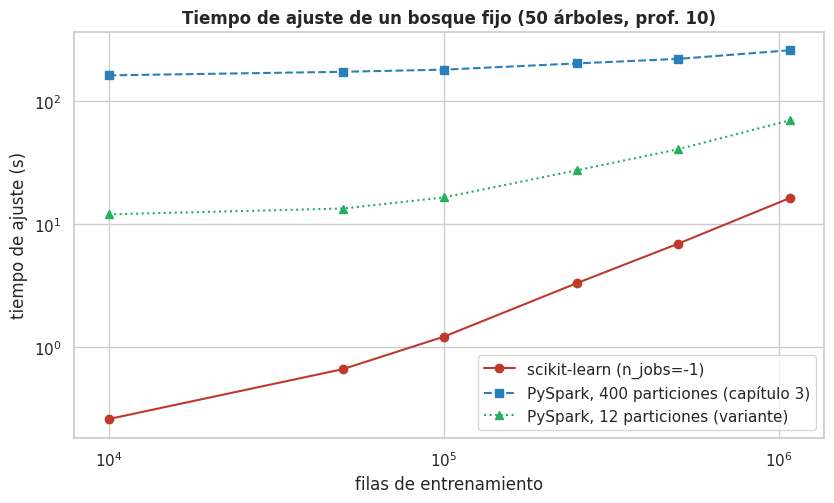

,costo fijo (s),costo por millón de filas (s),con el entrenamiento completo (s)
versión,,,
scikit-learn,-0.2269,15.0345,16.1910
PySpark (400 particiones),169.8932,86.2194,257.5911
PySpark (12 particiones),11.7380,54.4836,69.4192


En ningún volumen probado (hasta el entrenamiento completo) Spark fue más rápido que scikit-learn, con ninguna de las dos configuraciones.
PySpark (400 particiones): costo por fila 86 s por millón > scikit-learn 15: las rectas no se cruzan en el equipo utilizado.
PySpark (12 particiones): costo por fila 54 s por millón > scikit-learn 15: las rectas no se cruzan en el equipo utilizado.


In [6]:
es, ep = pd.read_csv(RESULTS / "escala_sklearn.csv"), pd.read_csv(RESULTS / "escala_spark.csv")
e12 = pd.read_csv(RESULTS / "escala_spark_12part.csv")
esc = (es.rename(columns={"t_ajuste_s": "sk", "auc_test": "auc_sk"})[["filas_train", "sk", "auc_sk"]]
       .merge(ep.rename(columns={"t_ajuste_s": "sp400", "auc_test": "auc_sp400"})[["filas_train", "sp400", "auc_sp400"]], on="filas_train")
       .merge(e12.rename(columns={"t_ajuste_s": "sp12"})[["filas_train", "sp12"]], on="filas_train"))
esc["Spark(400) / sklearn"], esc["Spark(12) / sklearn"] = esc["sp400"] / esc["sk"], esc["sp12"] / esc["sk"]
display(esc.style.format({"filas_train": "{:,.0f}", "sk": "{:.1f}", "sp400": "{:.1f}", "sp12": "{:.1f}", "auc_sk": "{:.4f}", "auc_sp400": "{:.4f}",
                          "Spark(400) / sklearn": "{:.1f}×", "Spark(12) / sklearn": "{:.1f}×"}))
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(esc["filas_train"], esc["sk"], "o-", color="#c0392b", label="scikit-learn (n_jobs=-1)")
ax.plot(esc["filas_train"], esc["sp400"], "s--", color="#2980b9", label="PySpark, 400 particiones (capítulo 3)")
ax.plot(esc["filas_train"], esc["sp12"], "^:", color="#27ae60", label="PySpark, 12 particiones (variante)")
ax.set(xscale="log", yscale="log", xlabel="filas de entrenamiento", ylabel="tiempo de ajuste (s)",
       title="Tiempo de ajuste de un bosque fijo (50 árboles, prof. 10)")
ax.legend()
plt.tight_layout()
plt.show()
rows = []
for nombre, col in (("scikit-learn", "sk"), ("PySpark (400 particiones)", "sp400"), ("PySpark (12 particiones)", "sp12")):
    b_, a_ = np.polyfit(esc["filas_train"].to_numpy(float), esc[col].to_numpy(), 1)
    rows.append({"versión": nombre, "costo fijo (s)": a_, "costo por millón de filas (s)": b_ * 1e6, "con el entrenamiento completo (s)": float(esc[col].iloc[-1])})
afin = pd.DataFrame(rows).set_index("versión")
display(afin)
b_sk = afin.loc["scikit-learn", "costo por millón de filas (s)"]
if ((esc["sp400"] < esc["sk"]) | (esc["sp12"] < esc["sk"])).any():
    print("Spark fue más rápido en algún volumen medido.")
else:
    print("En ningún volumen probado (hasta el entrenamiento completo) Spark fue más rápido que scikit-learn, con ninguna de las dos configuraciones.")
for v in ("PySpark (400 particiones)", "PySpark (12 particiones)"):
    b_sp = afin.loc[v, "costo por millón de filas (s)"]
    print(f"{v}: costo por fila {b_sp:.0f} s por millón " + (f"< scikit-learn {b_sk:.0f}: podrían cruzarse (extrapolación)." if b_sp < b_sk
                                                        else f"> scikit-learn {b_sk:.0f}: las rectas no se cruzan en el equipo utilizado."))

## 6.5 Efecto de cada elemento de la configuración de Spark

*Micro-benchmarks* del capítulo 3b (bosque pequeño fijo). "Factor" = cuántas veces tarda más (> 1) o menos
(< 1) la alternativa frente a la opción usada en los capítulos 3 y 3b.

In [7]:
abl = pd.read_csv(RESULTS / "spark_ablacion.csv")
display(abl.style.format({"con la condición (s)": "{:.1f}", "sin / alternativa (s)": "{:.1f}", "factor (alternativa / condición)": "{:.2f}"}))
cd = json.loads((RESULTS / "spark_costos.json").read_text())
print("createDataFrame desde pandas (segundos por llamada):")
display(pd.DataFrame(cd["createDataFrame_s"]).pivot(index="filas", columns="Arrow", values="createDataFrame + count (s)"))

,condición,con la condición (s),sin / alternativa (s),alternativa,factor (alternativa / condición)
0,"Caché tras VectorAssembler (5 árboles, prof. 5)",50.6,68.5,sin .persist(),1.35
1,"400 particiones del DataFrame de entrenamiento (10 árboles, prof. 10)",141.7,15.1,12 particiones,0.11
2,"CrossValidator con numFolds=3 (usado en los seis modelos) vs 2, malla de 2 combinaciones",395.0,281.6,numFolds=2,0.71
3,"CrossValidator parallelism=1 (elegido) vs 3, 3 pliegues, malla de 2 combinaciones",395.0,350.7,parallelism=3,0.89


createDataFrame desde pandas (segundos por llamada):


Arrow,no,sí
filas,,
1,512.8105,0.1673
100,501.7017,0.1107
5000,508.8281,0.2227


## 6.6 LIME: costo de explicar según el entorno

In [8]:
lime_sp = json.loads((RESULTS / "lime_spark.json").read_text())
lat = pd.DataFrame({"scikit-learn": sk["latencia_predict_s"], "PySpark (con Arrow)": lime_sp["latencia_predict_s"]})
lat.index.name = "filas por llamada"
lat["PySpark / scikit-learn"] = lat.iloc[:, 1] / lat.iloc[:, 0]
display(lat.style.format({"scikit-learn": "{:.4f} s", "PySpark (con Arrow)": "{:.3f} s", "PySpark / scikit-learn": "{:,.0f}×"}))
for k, v in lime_sp["instancias"].items():
    print(f"Una explicación LIME (5 000 muestras) de la instancia {k} con el modelo de Spark ({lm.NOMBRES[lime_sp['modelo']]}): {v['tiempo_s']:.1f} s")

,scikit-learn,PySpark (con Arrow),PySpark / scikit-learn
filas por llamada,,,
1,0.0002 s,0.287 s,"1,188×"
100,0.0006 s,0.275 s,489×
5000,0.0135 s,0.511 s,38×


Una explicación LIME (5 000 muestras) de la instancia FN con el modelo de Spark (Gradient boosting): 0.6 s
Una explicación LIME (5 000 muestras) de la instancia FP con el modelo de Spark (Gradient boosting): 0.6 s


# Discusión y conclusiones

Todos los tiempos son de **un solo equipo**: Intel Core i5-13420H (8 núcleos, 12 hilos), 16 GB de RAM,
Windows 11, Spark en modo local (`local[*]`). Nada de lo que sigue se midió en un clúster. Los cuadernos
del libro contienen el código y las salidas completas de cada número citado aquí.

## Costo computacional

**scikit-learn resultó más rápido que PySpark en los seis modelos, por un factor de ≈ 17:** ≈ 1 h 21 min
frente a ≈ 22 h 32 min (preprocesamiento + entrenamiento con validación cruzada + predicción +
transferencia).

| Modelo | scikit-learn | PySpark | Razón |
|---|---|---|---|
| Regresión logística | 15 s | 1 h 03 min | 252× |
| Árbol de decisión | 59 s | 1 h 04 min | 66× |
| Bosque aleatorio | 14 min | 5 h 52 min | 25× |
| *Gradient boosting* | 54 min | 10 h 07 min | 11× |
| SVM lineal | 10 min | 3 h 36 min | 21× |
| Naive Bayes | 5 s | 43 min | 495× |

Dos diferencias de procedimiento favorecen a scikit-learn en esta comparación. `GridSearchCV` reparte los
ajustes de la malla entre los 12 hilos (`n_jobs=-1`), mientras que el `CrossValidator` evaluó un modelo a
la vez (`parallelism = 1`) por restricciones de memoria, lo que le resta ≈ 11 % de velocidad (3b.4). Por
otra parte, en ambos entornos se excluye del total el tiempo de las predicciones fuera de pliegue usadas
para elegir el umbral.

Este resultado puede parecer contraintuitivo, dado que Spark se diseñó para acelerar el cómputo distribuido; las
razones que se pudieron comprobar en el equipo utilizado son:

1. **El tamaño completo del conjunto de datos reduce la brecha, pero no la cierra en una sola máquina.**
   En el experimento de escala, la razón de tiempos entre Spark y scikit-learn **mejora** al crecer los
   datos (de ≈ 625× con 10 000 filas a ≈ 16× con el entrenamiento completo, para un bosque fijo), porque el
   costo fijo de Spark pesa menos cuanto más grande es el lote. Pero incluso con **1.08 millones de filas**
   (el conjunto de entrenamiento completo) Spark sigue siendo más lento.
2. **La caché** (`persist` tras el `VectorAssembler`) sí ayuda: sin ella, un ajuste pequeño tardó ≈ 1.35×
   más. Es, de los elementos de configuración probados, el que **más** beneficia a Spark.
3. **El `CrossValidator`** con 3 pliegues (los mismos de scikit-learn) tardó ≈ 1.4× más que con 2: la
   validación cruzada es cara porque reajusta cada combinación de hiperparámetros una vez por pliegue, y
   Spark hace cada ajuste mucho más lento que scikit-learn (ver el punto 5).
4. **Las 400 particiones fijadas en la sesión** penalizan en el equipo utilizado: un ajuste pequeño con 400
   particiones tardó ≈ 9.4× más que con 12 (las que corresponden a los hilos reales del equipo). Son 400
   tareas diminutas por etapa, con más costo de planificación que de cómputo.
5. **En una sola máquina, Spark no puede repartir el trabajo entre nodos.** Usa los mismos 12 hilos que scikit-learn
   (`n_jobs=-1`), pero paga costos que scikit-learn no tiene: planificar tareas, serializar datos entre
   Python y la JVM y, en los árboles, recorrer los datos una vez por cada nivel de profundidad (así entrena
   Spark ML, pensado para datos que no caben en un nodo).
6. **Memoria.** Con 16 GB de RAM, `maxMemoryInMB = 64` (en vez del valor por defecto, 256) y
   `parallelism = 1` en el `CrossValidator` fueron necesarios para que el bosque más grande no agotara la
   memoria; ninguno de los dos cambia el algoritmo, pero **restan velocidad** frente a configuraciones con
   más memoria disponible (≈ 11 % en el caso de `parallelism = 1`; 3b.4).

> **Nota.** Con 12 particiones en vez de las 400 de la sesión, el mismo bosque de referencia tarda ≈ 69 s frente a
> ≈ 258 s: la brecha se reduce de ≈ 16× a ≈ 4× frente a scikit-learn (16 s), pero **no desaparece**.

## Equivalencia predictiva

**Depende del modelo.** Cinco de los seis dan prácticamente lo mismo en los dos entornos; el sexto (la SVM)
es una excepción notable:

| Modelo | AUC scikit-learn | AUC PySpark | ΔAUC | ¿Relevante? (≥ 0.005) |
|---|---|---|---|---|
| Regresión logística | 0.7095 | 0.7095 | +0.00000004 | No |
| Árbol de decisión | 0.7022 | 0.7004 | +0.0018 | No |
| Bosque aleatorio | 0.7164 | 0.7152 | +0.0012 | No |
| ***Gradient boosting*** | **0.7196** | **0.7189** | +0.0007 | No |
| **SVM lineal** | **0.4956** | **0.5985** | **−0.1029** | **Sí** |
| Naive Bayes | 0.6884 | 0.6883 | +0.0001 | No |

Para los otros cinco modelos, las diferencias son estadísticamente significativas en casi todos los
casos (269 062 observaciones de prueba permiten detectar diferencias muy pequeñas), pero **ninguna alcanza el margen de
relevancia práctica** (ΔAUC ≥ 0.005, fijado antes de ver resultados). El mejor modelo de los doce es
***gradient boosting***, en ambos entornos, con AUC ≈ 0.72.

**La SVM es la única excepción relevante:** en scikit-learn el AUC es 0.4956 (equivalente al azar) y en
PySpark 0.5985 (débil pero real). La diferencia (ΔAUC = 0.103) es la única de las **seis** comparaciones
entre entornos que supera el margen de relevancia práctica. La causa no es que "PySpark entienda mejor los
datos": es que `LinearSVC(loss="hinge")` de scikit-learn **converge a una solución degenerada** (ver la
sección de diferencias de implementación).

## Significancia frente a relevancia

**Se hicieron dos familias de comparaciones DeLong**, corregidas con Holm dentro de cada una:

- **Entre entornos (6 comparaciones, el mismo modelo en los dos motores):** 5 de 6 son estadísticamente
  significativas tras Holm (todas menos la regresión logística, p ajustado = 0.48). **Solo 1 de las 6 es
  relevante en la práctica: la SVM** (ΔAUC = −0.103). Las otras cuatro significativas (árbol, bosque aleatorio, *gradient boosting*, Naive Bayes) tienen ΔAUC entre 0.0001 y 0.0018: estadísticamente reales,
  prácticamente irrelevantes.
- **Entre modelos, dentro de cada entorno (15 pares por entorno):** aquí ocurre lo contrario. Los seis
  modelos difieren bastante entre sí en capacidad predictiva, así que **14 de los 15 pares por entorno
  superan el margen de relevancia práctica**; la única excepción es el bosque aleatorio frente al *gradient
  boosting* (el mejor par de cada entorno, ΔAUC ≈ 0.003–0.004: significativo, pero por debajo del margen de
  0.005). Es decir, distinguir *modelos* entre sí casi siempre importa en la práctica; distinguir el
  *mismo* modelo entre *motores* casi nunca importa, salvo por la SVM.

**Conclusión:** con 269 062 observaciones de prueba, la significancia estadística casi no distingue entre
"el mismo modelo, dos motores" y "modelos distintos": prácticamente todo resulta significativo. El **margen de relevancia
práctica** es lo que separa lo que importa (las diferencias entre modelos, y la SVM entre motores) del
ruido propio de un conjunto de datos grande (las diferencias mínimas del mismo modelo entre motores).

## Diferencias de implementación

1. **`LinearSVC(loss="hinge")` de scikit-learn converge a una solución degenerada (la diferencia más
   grande).** Se investigó en detalle (sección 2.5): en un ajuste de diagnóstico con 700 000 filas, el
   *solver* dual de `liblinear` converge en 93 iteraciones, sin advertencias, a coeficientes ≈ 10⁻⁸ y un
   intercepto de −1.0, y el colapso se repite con los tres valores de `C` de la malla: predice "paga" para
   casi todo, sin separar clases. Es compatible con la solución degenerada de la SVM de pérdida *hinge*
   descrita por Rifkin, Pontil y Verri (1999) para clases solapadas y desbalanceadas, reforzada porque
   `liblinear` también regulariza el intercepto. El `LinearSVC` de PySpark no regulariza el intercepto y
   usa otro optimizador (OWL-QN; Andrew y Gao, 2007), que no muestra el mismo colapso y da un AUC débil
   pero real (0.60); ninguna de las dos diferencias se aisló por separado. No se cambió `loss` porque
   `hinge` es la pérdida que minimiza el `LinearSVC` de PySpark y la que hace comparables ambos modelos.
2. **Discretización de los árboles (`maxBins`).** PySpark corta cada variable continua en como máximo 32
   intervalos (`maxBins = 32`, por defecto, reportado en los tres modelos de árbol); scikit-learn evalúa
   cortes **exactos**. Es una posible explicación de que el árbol de decisión y el bosque de scikit-learn
   tengan un AUC ligeramente mayor: pueden encontrar el punto de corte óptimo, mientras PySpark elige entre
   32 candidatos. El efecto es pequeño (ΔAUC ≤ 0.002) y no se aisló con un experimento aparte.
3. **La relación `C = 1 / (regParam × n)`** entre scikit-learn y PySpark es **aproximada**: `C` pondera la
   suma de las pérdidas y `regParam` su promedio. Esto afecta a la regresión logística y a la SVM; para la
   logística el efecto fue mínimo (AUC casi idéntico), para la SVM quedó opacado por la solución degenerada del punto 1.
4. **`NaiveBayes` gaussiano en ambos entornos** evita el problema de valores negativos que tendrían las
   variantes multinomial/Bernoulli con datos escalados; el resultado es prácticamente idéntico entre
   motores (ΔAUC = 0.0001), como se esperaría de un modelo con una fórmula cerrada y sin optimización
   iterativa de por medio.

## Concordancia entre las tres pruebas

**Limitaciones de DeLong, la prueba principal:**

1. Solo mide la incertidumbre del **muestreo del conjunto de prueba**; no incluye la del entrenamiento (semillas,
   pliegues, modelos estocásticos como el bosque o el *boosting*).
2. Supone observaciones **independientes** (préstamos de la misma época o estado comparten contexto).
3. El AUC resume **todos los umbrales**, y puede no reflejar el umbral operativo elegido.

**¿Coinciden DeLong, McNemar y el *bootstrap*?** En general sí, con **dos discrepancias** entre
DeLong y McNemar, y un patrón más disperso en el *bootstrap* de F1 y AUC-PR:

- **Regresión logística:** DeLong dice que **no** hay diferencia significativa (p ajustado = 0.48,
  ΔAUC ≈ 0), y el *bootstrap* de AUC tampoco (coincide con DeLong, como debía). Pero **McNemar sí encuentra
  una diferencia significativa** (p ≈ 3×10⁻¹¹⁹) en las decisiones concretas (umbral fijo): de 269 062
  préstamos, 318 los acierta solo scikit-learn y 1237 solo PySpark. Los dos modelos ordenan los préstamos
  casi igual, por eso el AUC no distingue, pero como cada uno usa un umbral ligeramente
  distinto (0.2042 en scikit-learn frente a 0.2061 en PySpark, elegidos por separado con F1 fuera de
  pliegue), **clasifican de forma algo distinta a los préstamos que quedan cerca del umbral**. Es
  precisamente la limitación 3 de DeLong: resume todos los umbrales y no ve esto. Como ambos umbrales provienen de
  mallas discretas, parte de esa diferencia puede deberse a la resolución de la malla y no a los modelos.
- **Árbol de decisión:** al revés. **DeLong sí** encuentra diferencia significativa (p ajustado = 0.003) y
  **McNemar no** (p = 0.058, con Holm). El AUC del árbol de scikit-learn es algo mayor de forma consistente
  en todo el rango de umbrales (por los cortes exactos, sección anterior), pero en el umbral operativo
  concreto las decisiones no difieren lo suficiente para que McNemar lo detecte.
- **El *bootstrap* de AUC coincide con DeLong en las seis comparaciones entre entornos:** ambas pruebas
  miden lo mismo (el AUC) con métodos distintos (asintótico vs. remuestreo). Que coincidan es evidencia de
  que ninguna de las dos está fallando.
- **El *bootstrap* de AUC-PR y F1 no siempre coinciden entre sí, ni con el AUC.** De los seis modelos, el
  F1 no resulta significativo en cuatro (regresión logística, árbol, *gradient boosting*, Naive Bayes) y el
  AUC-PR no resulta significativo en dos, pero **no los mismos dos**: regresión logística y bosque aleatorio.
  La SVM es el único modelo en el que las tres métricas (AUC, AUC-PR y F1) coinciden en ser
  significativas. Esto es consistente con que F1 y AUC-PR dependen del umbral y de la clase minoritaria de
  forma distinta al AUC: no hay razón para esperar que las tres métricas siempre estén de acuerdo.

**En conjunto:** las tres pruebas coinciden en lo más importante (la SVM es la única diferencia grande y
consistente en las tres métricas); donde discrepan, la razón siempre fue identificable (umbral vs. orden
completo, o sensibilidad distinta a la clase minoritaria), no un error de las pruebas.

## Escalabilidad

**En el equipo utilizado, en ninguno de los volúmenes probados**, ni con las 400 particiones de la sesión ni con
una variante de 12, PySpark llegó a superar a scikit-learn. Se ajustó un bosque fijo (50 árboles,
profundidad 10) con 10 000 hasta 1 076 248 filas:

| Versión | Costo fijo | Costo por millón de filas | Con el entrenamiento completo |
|---|---|---|---|
| scikit-learn | ≈ 0 s | ≈ 15 s | 16 s |
| PySpark, 400 particiones (capítulo 3) | ≈ 170 s | ≈ 86 s | 258 s |
| PySpark, 12 particiones (variante) | ≈ 12 s | ≈ 54 s | 69 s |

El **costo por fila** de Spark es mayor que el de scikit-learn en ambas configuraciones: las rectas de
tiempo **no se cruzan**, ni medido ni extrapolando linealmente. La pregunta solo tendría una respuesta real
en dos situaciones que este trabajo no puede probar: **(a)** datos que no caben en la RAM de una máquina
(scikit-learn requeriría estrategias fuera de memoria) o **(b)** un **clúster** con muchos nodos, donde el trabajo sí se
reparte entre máquinas. Cualquier cifra concreta de "cruce" para esos casos sería especulación.

## Interpretabilidad

**Qué aporta LIME.** Se explicaron los **mismos dos préstamos** con el mejor modelo de probabilidades de
cada entorno (*gradient boosting* en los dos):

- **Falso negativo** (préstamo 36099806, incumplió; ambos modelos daban ≈ 0.02 de probabilidad): las
  variables que más empujaban hacia "paga" fueron consistentes entre los dos entornos.
- **Falso positivo** (préstamo 55961482, se pagó; ambos modelos daban ≈ 0.83–0.86): igual, coherencia entre
  entornos en las variables principales.
- Promediando 60 explicaciones, cuatro de las cinco variables más influyentes (`int_rate`, `term_months`,
  `fico_range_high` y `dti`) coinciden con las cinco principales de la importancia por permutación del
  bosque aleatorio, calculada de forma independiente, aunque el orden difiere.

**Sus límites (medidos en este trabajo):**

1. **Fidelidad parcial:** el R² del modelo lineal local no es 1 (entre 0.50 y 0.58 en scikit-learn, entre
   0.51 y 0.55 en PySpark, según el préstamo): la explicación imita al modelo solo en parte.
2. **Estabilidad frente a la semilla:** para el falso negativo, se repitió la explicación con 5 semillas
   distintas y las 5 principales variables salieron **exactamente en el mismo orden** las cinco veces. Es
   una sola instancia y cinco repeticiones, así que no prueba que LIME sea siempre estable aquí; solo que,
   en este caso concreto, la aleatoriedad del muestreo no cambió la conclusión.
3. **Perturbaciones sin correlaciones:** LIME muestrea cada variable por separado, puede crear préstamos
   imposibles (p. ej. tasa muy baja con FICO muy bajo), sobre los que el modelo nunca fue entrenado.
4. **En PySpark, LIME opera en memoria local** y llama al modelo miles de veces. Con Apache Arrow, cada
   llamada del modelo final de Spark tardó ≈ 0.5 s con 5 000 filas: viable para explicar unas pocas
   instancias, no millones.
5. **Sin Arrow, una llamada tardaba ≈ 8 minutos** en una ejecución preliminar (400 particiones): con esa
   latencia, LIME sería inviable en la práctica. Se comprobó que la causa era el envío del lote sin Arrow,
   no el tamaño del modelo (capítulo 3b).
6. **Datos de referencia locales:** LIME necesita traer una muestra al *driver* (aquí, filas de
   entrenamiento) para conocer las distribuciones, lo que va en contra de la idea de no mover el conjunto de datos
   completo al *driver*.

## Efecto de la configuración de Spark

| Elemento de la configuración | Efecto medido | Evidencia |
|---|---|---|
| **Conjunto de datos completo, sin muestreo** | Ayuda a Spark relativamente (el costo por fila pesa más que el fijo a mayor volumen) pero no basta: Spark sigue siendo más lento con el conjunto completo | 3b.5, 6.4 |
| **Los mismos seis modelos y espacios de búsqueda en ambos entornos** | Permite la comparación pareada (DeLong); reveló la falla de la SVM de scikit-learn, invisible si solo se hubiera probado un modelo | 2, 3, 5 |
| **`ParamGridBuilder` + `CrossValidator`, sin bucles manuales** | Reproducible y correcto, pero es la etapa más costosa: sola representa la mayoría del tiempo total de Spark | 6.3 |
| **`numFolds = 3` (igual que scikit-learn)** | Cuesta ≈ 1.4× más que 2 pliegues; con `foldCol`, hace que la selección de hiperparámetros use exactamente los mismos pliegues que scikit-learn | 3b.4 |
| **`spark.default.parallelism` / `shuffle.partitions = 400`** | **Empeoró** el rendimiento en el equipo utilizado: ≈ 9.4× más lento que con 12 particiones (las de los hilos reales) | 3b.4 |
| **`spark.executor.memory = 8g`** | **Sin efecto en modo local**: no hay ejecutores separados; cuenta `spark.driver.memory` | 3.1 |
| **`spark.driver.memory`, `memory.fraction`, `storageFraction`** | Fijan el límite real de memoria (el heap verificado fue 8.6 GB); no se aislaron con experimentos separados | 3.1 |
| **Caché (`.persist()`) tras el `VectorAssembler`** | Reduce el tiempo de un ajuste ≈ 1.35×; con el `CrossValidator`, que reutiliza los datos decenas de veces, el ahorro acumulado es mayor | 3b.4 |
| **Ninguna transferencia de datos al driver antes de entrenar** | Solo se transfirieron agregados diminutos (conteos por categoría, sumas para el umbral); la única transferencia grande (id, etiqueta, puntuación del conjunto de prueba) ocurrió **después** de entrenar y se midió aparte (< 10 s en total para los seis modelos) | 3, 6.3 |

## Conclusiones

1. Con implementaciones equivalentes, la misma partición y los mismos pliegues, scikit-learn y PySpark
   producen modelos de calidad prácticamente idéntica: en cinco de los seis modelos, las diferencias de
   AUC entre motores (≤ 0.0018) son detectables con 269 062 observaciones de prueba, pero quedan muy por
   debajo del margen de relevancia práctica.
2. La única diferencia relevante entre motores es la de la SVM lineal (ΔAUC = −0.103), atribuible a la
   solución degenerada de la pérdida *hinge* en `liblinear` y no a una ventaja general de uno de los
   motores.
3. Entre modelos, en cambio, casi todas las diferencias son relevantes. El *gradient boosting* es el mejor
   en ambos entornos (AUC ≈ 0.72), seguido del bosque aleatorio, del que no se distingue en la práctica.
4. En una sola máquina de 12 hilos, scikit-learn es ≈ 17 veces más rápido. El mayor volumen reduce la
   brecha, pero el costo por fila de Spark sigue siendo mayor, así que no hay un punto de cruce en el
   equipo utilizado; la ventaja de Spark queda reservada a datos que no caben en memoria o a un clúster.
5. LIME produce explicaciones coherentes entre motores para los mismos préstamos, pero con fidelidad local
   moderada (R² entre 0.50 y 0.58) y un costo por llamada en Spark que lo limita a unas pocas instancias.
6. La información disponible al otorgar un préstamo predice el incumplimiento solo moderadamente, y una
   parte importante de ella proviene de la tasa de interés que asigna la propia plataforma.

## Alcance de las conclusiones

Los resultados de este trabajo no permiten afirmar:

- Que Spark sea "más lento que scikit-learn" en general: solo que lo fue **aquí**, en una máquina con 12
  hilos y 16 GB, con estos datos y esta configuración de sesión.
- Nada sobre el desempeño en un clúster real.
- El efecto individual de `spark.memory.fraction` y `storageFraction` (no se aislaron).
- Que el AUC ≈ 0.72 del *gradient boosting* sea el máximo alcanzable con estos datos.
- Por qué exactamente `maxBins = 32` produce el ΔAUC observado en los árboles: es la explicación más
  plausible, pero no se aisló con un experimento que solo cambiara `maxBins`.

## Referencias

- Andrew, G. y Gao, J. (2007). Scalable training of L1-regularized log-linear models. En *Proceedings of the 24th International Conference on Machine Learning (ICML)*, 33–40.
- Bergmeir, C. y Benítez, J. M. (2012). On the use of cross-validation for time series predictor evaluation. *Information Sciences*, 191, 192–213.
- Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2.ª ed.). Lawrence Erlbaum.
- DeLong, E. R., DeLong, D. M. y Clarke-Pearson, D. L. (1988). Comparing the areas under two or more correlated receiver operating characteristic curves: a nonparametric approach. *Biometrics*, 44(3), 837–845.
- Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation*, 10(7), 1895–1923.
- Efron, B. y Tibshirani, R. J. (1993). *An Introduction to the Bootstrap*. Chapman & Hall.
- Fan, R.-E., Chang, K.-W., Hsieh, C.-J., Wang, X.-R. y Lin, C.-J. (2008). LIBLINEAR: A library for large linear classification. *Journal of Machine Learning Research*, 9, 1871–1874.
- Holm, S. (1979). A simple sequentially rejective multiple test procedure. *Scandinavian Journal of Statistics*, 6(2), 65–70.
- Lundberg, S. M., Erion, G., Chen, H., DeGrave, A., Prutkin, J. M., Nair, B., Katz, R., Himmelfarb, J., Bansal, N. y Lee, S.-I. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence*, 2, 56–67.
- McNemar, Q. (1947). Note on the sampling error of the difference between correlated proportions or percentages. *Psychometrika*, 12(2), 153–157.
- Meng, X. *et al.* (2016). MLlib: Machine learning in Apache Spark. *Journal of Machine Learning Research*, 17(34), 1–7.
- Pedregosa, F. *et al.* (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Ribeiro, M. T., Singh, S. y Guestrin, C. (2016). "Why should I trust you?": Explaining the predictions of any classifier. En *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 1135–1144.
- Rifkin, R., Pontil, M. y Verri, A. (1999). A note on support vector machine degeneracy. En *Algorithmic Learning Theory (ALT 1999)*, Lecture Notes in Computer Science 1720, 252–263. Springer.
- Sun, X. y Xu, W. (2014). Fast implementation of DeLong's algorithm for comparing the areas under correlated receiver operating characteristic curves. *IEEE Signal Processing Letters*, 21(11), 1389–1393.
